# Bioinformatics and Systems Biology (BSB) - Exam Assignment

**Student:** Ilenia Gulino  
**Inspiring paper:** *Cell type-specific transcriptomics identifies neddylation as a novel therapeutic target in multiple sclerosis* (Brain, 2021, doi:10.1093/brain/awaa421)  
**Dataset:** GSE137143 - CD4+ T cells - Treatment-naive MS vs Healthy control

This notebook reproduces a **scaled-down** version of the paper's CD4+ T-cell analysis and then performs the network-medicine analysis.

- **Part 1:** QC -> Salmon quantification -> Differential Expression (DEA) -> gene/pathway enrichment.
- **Part 2:** STRING PPI network -> community detection -> DrugBank drug targets -> drug-disease network proximity.

Design: **8 samples** = 4 MS (treatment-naive) + 4 Healthy Control, balanced by sex (2F/2M per group) and age-matched.



## Executive summary

**Pipeline.** FastQC -> fastp QC/trim -> Salmon gene-level quantification (GENCODE v28, transcriptome-only
index, `--geneMap`) -> **sample-level QC / outlier control** -> PyDESeq2 DEA (`~ sex + condition`)
-> GSEA + ORA enrichment -> STRING physical PPI -> centrality / Louvain communities -> drug-disease
proximity.

**Key findings.**
- **QC:** 2 x 151 bp paired-end; adapter read-through (Illumina TruSeq, ~26-37% of reads); light
  fastp trimming; Salmon mapping 37-46% (transcriptome-only index).
- **Sample QC:** one initially-selected sample (SRR10089503), labelled as CD4+ sample, presented
  **a strong myeloid/monocyte-like expression profile** (high LYZ/CD14/S100A9) incompatible with the
  other CD4 samples; it was excluded and replaced by SRR10089494.
- **DEA:** 44 DEGs at padj<0.05 (25 also |log2FC|>=1: 8 up / 17 down).
- **Enrichment:** GSEA shows **positive enrichment of translation / ribosome biogenesis** and **negative enrichment of interferon / IL-8 / NK-immunity**, with a secondary, weaker protein-ubiquitination signal.
- **Comparison with the paper:** NAE1 is directionally concordant and nominally significant (p~0.005) but **not FDR-significant** (padj~0.39);
  only a broad ubiquitin/E3-ligase hint, compatible with related ubiquitin-like machinery but not specific for neddylation.
- **Network:** the FDR-DEG PPI’s only non-trivial connected component is a five-node histone clique with tied centralities
  (too sparse for a rankable module), so the **betweenness-derived disease module** is the top 15 Topology PPI
  nodes by **betweenness centrality**. Network-conditioned community enrichment supports a
  **chemokine/GPCR** community and a **TNFR2/NF-kB** community (FDR<0.05); immune/cytotoxic-signalling and adhesion-related communities were also identified, but neither showed FDR-significant enrichment under the network-conditioned ORA. DrugBank-target proximity on a Reference Physical Interactome is
  **not significant** for any of the three drugs.

## Naming legend

Every gene set, network and enrichment below is named by what it contains and what it is used for. 

**Part 1 - enrichment**

| Name | Definition |
|---|---|
| **Ranked GSEA** | all DEA-tested genes, ranked by the Wald statistic (no cut-off) |
| **Large-effect FDR ORA** | ORA on `padj<0.05 & \|log2FC\|>=1` |
| **FDR-defined DEG ORA** | ORA on `padj<0.05` (the paper's DEG definition) |
| **PPI-input ORA** | ORA on the protein-coding `nominal p<0.05 & \|log2FC\|>=log2(1.5)` set (the Topology PPI input), on the tested-gene and the tested protein-coding backgrounds |

**Part 2 - networks, modules & community enrichment**

| Name | Definition |
|---|---|
| **FDR-DEG PPI** | STRING physical (score>=400) on the protein-coding `padj<0.05` DEGs |
| **FDR-10% PPI** | the same at `padj<0.10` (threshold used by the paper) - sensitivity check |
| **Topology PPI** | largest connected component of the STRING physical network (score>=400) built from the protein-coding `nominal p<0.05 & \|log2FC\|>=log2(1.5)` set - basis for centrality, ranking and community detection |
| **FDR-connected core** | the only non-trivial connected component of the FDR-DEG PPI (a five-node histone clique) |
| **Betweenness-derived disease module** | the top-15 Topology PPI nodes by betweenness centrality |
| **Network-conditioned Community ORA** | ORA on each Louvain community with background = the network nodes (not the DEA background) |
| **Reference Physical Interactome** | largest connected component of the reference STRING v12.0 human physical network (score>=400; score>=700 as a sensitivity check), independent of the DEGs - used for community reach and Guney proximity |
| **Drug-extended Topology PPI** | the full Topology PPI extended with the DrugBank drug targets through their STRING physical interactions at score >= 400 (top-15 disease module highlighted) |


## Environment and configuration

In [65]:
from IPython.display import display
from pathlib import Path
import os, sys, subprocess, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Paths (notebook is assumed to live in MS_CD4/notebooks/) ----
PROJECT   = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA      = PROJECT / 'data'
RAW_FASTQ = DATA / 'raw_fastq'
TRIMMED   = DATA / 'fastq_trimmed'      # trimmed paired-end FASTQ files
REF       = DATA / 'reference'          # GENCODE v28
META      = DATA / 'metadata'
IDX       = DATA / 'salmon_index_v112_utf8'   # transcriptome-only Salmon index
QUANT     = DATA / 'salmon_quants'      # Salmon gene-level quantification outputs, one folder per sample_id (=SRR run)

RESULTS  = PROJECT / 'results'
QC       = RESULTS / 'qc'
DEA      = RESULTS / 'dea'
ENRICH   = RESULTS / 'enrichment'
NET      = RESULTS / 'network'
STATE_FILE = RESULTS / 'pipeline_state.json'
for d in [DEA, ENRICH, NET]:
    d.mkdir(parents=True, exist_ok=True)

THREADS = 4             # conservative thread count for local execution
SEED = 42
np.random.seed(SEED)

def pipeline_state() -> dict:
    return json.loads(STATE_FILE.read_text()) if STATE_FILE.exists() else {}

print('PROJECT   =', PROJECT)
print('RAW_FASTQ =', RAW_FASTQ, '(exists:', RAW_FASTQ.exists(), ')')
print('IDX       =', IDX, '(built:', (IDX/"info.json").exists(), ')')
print('pipeline_state.json steps done:', sum(v == 'done' for v in pipeline_state().values()))

PROJECT   = e:\MS_CD4
RAW_FASTQ = e:\MS_CD4\data\raw_fastq (exists: True )
IDX       = e:\MS_CD4\data\salmon_index_v112_utf8 (built: True )
pipeline_state.json steps done: 18


In [66]:
# ---- Docker helper: run the tools (salmon / fastp / multiqc) from the notebook ----
# All command-line steps below run inside the project's `mscd4-bioinfo:latest` image
# (salmon 1.12.0, fastp 0.20.1, multiqc 1.25.2), with the project mounted at /project.
# The notebook executes the required command-line tools directly through Docker. Existing outputs
# are reused when available so completed steps are not repeated unnecessarily.
DOCKER_IMAGE = 'mscd4-bioinfo:latest'

def docker_run(args, log_name=None, echo=True):
    """Run `args` (a list) inside the project Docker image. Paths inside the container are
    under /project (e.g. /project/data/..., /project/results/...)."""
    cmd = ['docker', 'run', '--rm',
           '-v', f'{PROJECT}:/project', '-w', '/project',
           DOCKER_IMAGE] + [str(a) for a in args]
    if echo:
        print('$ docker run --rm -v <PROJECT>:/project -w /project', DOCKER_IMAGE, ' '.join(str(a) for a in args))
    # Force UTF-8 decoding: MultiQC/salmon emit non-cp1252 chars
    proc = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8', errors='replace')
    out = (proc.stdout or '') + (proc.stderr or '')
    if log_name:
        (PROJECT / 'logs').mkdir(exist_ok=True)
        (PROJECT / 'logs' / log_name).write_text(out, encoding='utf-8')
    if proc.returncode != 0:
        print(out[-3000:])
        raise RuntimeError(f'Docker command failed (exit {proc.returncode}): {" ".join(args[:2])} ...')
    return out

def mark_state(step, key):
    st = pipeline_state(); st[f'{step}.{key}'] = 'done'
    STATE_FILE.parent.mkdir(parents=True, exist_ok=True)
    STATE_FILE.write_text(json.dumps(st, indent=2, sort_keys=True))


## Part 1 - Task 0: Dataset, metadata review and sample selection

**Dataset.** GSE137143 profiles FACS-sorted immune populations
(CD4+ T cells, CD8+ T cells, CD14+ monocytes) from **treatment-naive MS patients** and
**healthy controls**. The **complete GEO metadata** for the whole series (`GSE137143_family.soft.gz`) which describes **all samples** (one GSM per sorted population per
donor) were downloaded and the per-sample characteristics (disease state, sex, age, cell type, subtype, ...) were parsed into a table.

**Selection criteria.** From this pool, **8 CD4+ T-cell samples** were selected:
**4 treatment-naive MS vs 4 healthy controls**, balanced **2 females + 2 males per group** and
**age-matched**. Treatment status is encoded in the GEO sample **title** ("Treatment naive MS
patients ..." vs "Healthy controls ..."), because every MS donor in this series is
treatment-naive by design.

**Outcome.** Below, (1) the full metadata are parsed, (2) the criteria are applied to obtain the eligible
candidate pool and (3) the final balanced selection is recorded and verified. The 8 chosen samples with the
SRA **run accessions** used for the FASTQ download are stored in `data/metadata/samples.csv`,
which every downstream step consumes.

In [67]:
# --- Parse the full GEO SOFT metadata (all samples in GSE137143) ---
import gzip
soft = META / 'GSE137143_family.soft.gz'   # complete series metadata, downloaded from GEO

def parse_geo_soft(path):
    """One row per sample (GSM): the title + every 'key: value' Sample_characteristics field."""
    rows, cur = [], None
    with gzip.open(path, 'rt', encoding='utf-8', errors='replace') as fh:
        for line in fh:
            line = line.rstrip('\n')
            if line.startswith('^SAMPLE'):
                if cur: rows.append(cur)
                cur = {'gsm': line.split('=', 1)[1].strip()}
            elif cur is not None and line.startswith('!Sample_title'):
                cur['title'] = line.split('=', 1)[1].strip()
            elif cur is not None and line.startswith('!Sample_characteristics_ch1') and ':' in line:
                k, v = line.split('=', 1)[1].split(':', 1)
                cur[k.strip()] = v.strip()
        if cur: rows.append(cur)
    return pd.DataFrame(rows)

meta_all = parse_geo_soft(soft)
print('Parsed GEO SOFT:', meta_all.shape[0], 'samples (GSM)')
print('cell types :', dict(meta_all['cell type'].value_counts()))
print('disease     :', dict(meta_all['disease state'].value_counts()))
meta_all[['gsm','title','disease state','gender','age at exam','cell type','disease subtypes']].head(10)

Parsed GEO SOFT: 427 samples (GSM)
cell types : {'CD14+ monocytes': np.int64(144), 'CD8+ T cells': np.int64(142), 'CD4+ T cells': np.int64(141)}
disease     : {'Multiple sclerosis (MS)': np.int64(363), 'Healthy control': np.int64(64)}


,gsm,title,disease state,gender,age at exam,cell type,disease subtypes
0,GSM4071521,"Healthy controls, 13311d-CD14",Healthy control,M,NA,CD14+ monocytes,NA
1,GSM4071522,"Healthy controls, 13311d-CD4",Healthy control,M,NA,CD4+ T cells,NA
2,GSM4071523,"Healthy controls, 13311d-CD8",Healthy control,M,NA,CD8+ T cells,NA
3,GSM4071524,"Healthy controls, 22012b-CD14",Healthy control,M,NA,CD14+ monocytes,NA
4,GSM4071525,"Treatment naïve MS patients, 43213b-CD14",Multiple sclerosis (MS),F,34,CD14+ monocytes,RR
5,GSM4071526,"Treatment naïve MS patients, 43213b-CD4",Multiple sclerosis (MS),F,34,CD4+ T cells,RR
6,GSM4071527,"Treatment naïve MS patients, 43213b-CD8",Multiple sclerosis (MS),F,34,CD8+ T cells,RR
7,GSM4071528,"Treatment naïve MS patients, 46913b-CD14",Multiple sclerosis (MS),F,72,CD14+ monocytes,SP
8,GSM4071529,"Treatment naïve MS patients, 46913b-CD4",Multiple sclerosis (MS),F,72,CD4+ T cells,SP
9,GSM4071530,"Treatment naïve MS patients, 46913b-CD8",Multiple sclerosis (MS),F,72,CD8+ T cells,SP


In [68]:
# --- eligible CD4 candidate pool ---
# treatment-naive vs HC is read from the GEO title (all MS donors here are treatment-naive).
meta_all['group'] = np.select(
    [meta_all['title'].str.contains('MS patients', case=False, na=False),
     meta_all['title'].str.contains('Healthy',     case=False, na=False)],
    ['MS (treatment-naive)', 'Healthy control'], default='other')
meta_all['age'] = pd.to_numeric(meta_all['age at exam'], errors='coerce')

cd4  = meta_all[meta_all['cell type'] == 'CD4+ T cells'].copy()                 # criterion 1
cand = cd4[cd4['group'].isin(['MS (treatment-naive)', 'Healthy control'])].copy()  # criterion 2
cand.to_csv(META / 'cd4_eligible_candidates.csv', index=False)

print('Selection funnel:')
print(f"  all GSM samples ............ {len(meta_all)}")
print(f"  CD4+ T cells ............... {len(cd4)}")
print(f"  CD4 & (naive-MS | HC) ...... {len(cand)}   <- eligible candidate pool")
print('\nCandidate pool by group x sex (target 2F + 2M per group):')
print(pd.crosstab(cand['group'], cand['gender']))
print('\nAge (years) available per group x sex:')
print(cand.groupby(['group', 'gender'])['age'].agg(['count', 'min', 'median', 'max']))

Selection funnel:
  all GSM samples ............ 427
  CD4+ T cells ............... 141
  CD4 & (naive-MS | HC) ...... 141   <- eligible candidate pool

Candidate pool by group x sex (target 2F + 2M per group):
gender                 F   M
group                       
Healthy control       10  11
MS (treatment-naive)  78  42

Age (years) available per group x sex:
                             count   min  median   max
group                gender                           
Healthy control      F          10  23.0    26.0  43.0
                     M          10  23.0    32.0  48.0
MS (treatment-naive) F          76  21.0    36.0  72.0
                     M          42  19.0    36.0  66.0


In [69]:
# --- Final selection (recorded in samples.csv) + GSM->SRA run mapping + criteria check ---
# The final selection from the eligible candidate pool is recorded in samples.csv. Each chosen GSM is
# mapped to its SRA run (RunInfo) and the balance and age criteria are verified.
runinfo = pd.read_csv(META / 'RunInfo_SRP221152.csv')[['Run', 'SampleName']]
chosen  = pd.read_csv(META / 'samples.csv')

check = (chosen.merge(runinfo, left_on='gsm', right_on='SampleName', how='left')
               .merge(cand[['gsm', 'group']], on='gsm', how='left'))
check['run_matches_sample_id'] = check['Run'] == check['sample_id']

print('Every chosen GSM maps to its downloaded SRA run (sample_id):',
      bool(check['run_matches_sample_id'].all()))
print('\nFinal 8 selected samples:')
print(check[['sample_id', 'gsm', 'group', 'sex', 'age', 'cell_type']].to_string(index=False))
print('\nBalance check - must be 2F/2M per group:')
print(pd.crosstab(chosen['condition'], chosen['sex']))
print(f"\nAge range of the selection: {chosen['age'].min()}-{chosen['age'].max()} y "
      f"(mean {chosen['age'].mean():.1f}) -> age-matched across groups.")
assert (pd.crosstab(chosen['condition'], chosen['sex']).values == 2).all(), 'balance broken!'
assert set(chosen['cell_type']) == {'CD4'}, 'non-CD4 sample present!'
print('\nAll criteria satisfied: 4 naive-MS + 4 HC, 2F/2M per group, CD4+, age-matched.')

Every chosen GSM maps to its downloaded SRA run (sample_id): True

Final 8 selected samples:
  sample_id        gsm                group sex  age cell_type
SRR10089589 GSM4071856      Healthy control   F   31       CD4
SRR10089616 GSM4071883      Healthy control   F   32       CD4
SRR10089583 GSM4071850      Healthy control   M   32       CD4
SRR10089670 GSM4071937      Healthy control   M   32       CD4
SRR10089428 GSM4071695 MS (treatment-naive)   F   32       CD4
SRR10089494 GSM4071761 MS (treatment-naive)   F   32       CD4
SRR10089413 GSM4071680 MS (treatment-naive)   M   32       CD4
SRR10089431 GSM4071698 MS (treatment-naive)   M   32       CD4

Balance check - must be 2F/2M per group:
sex        F  M
condition      
HC         2  2
MS         2  2

Age range of the selection: 31-32 y (mean 31.9) -> age-matched across groups.

All criteria satisfied: 4 naive-MS + 4 HC, 2F/2M per group, CD4+, age-matched.


### FASTQ download and basic readability checks

The 8 selected runs were downloaded from **ENA** (no login needed) using the accessions in
`samples.csv` (`sample_id`), e.g. for `SRR10089589`:

```bash
cd data/raw_fastq
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR100/089/SRR10089589/SRR10089589_1.fastq.gz
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR100/089/SRR10089589/SRR10089589_2.fastq.gz
# or with the SRA Toolkit:
#   prefetch SRR10089589 && fasterq-dump --split-files SRR10089589 -O data/raw_fastq && gzip data/raw_fastq/SRR10089589_*.fastq
```

Files pass a gzip-readability and file-size check before use. The cell below opens each
`.fastq.gz` present and flags any file that is missing or fails to open as a valid gzip stream.

In [70]:
# --- FASTQ presence + gzip-readability + file-size check ---
import gzip as _gz
_sheet = pd.read_csv(META/'samples.csv')          # self-contained (runs before the Task-1 sample-sheet cell)
print(f"{'sample':13} {'_1 (GB)':>9} {'_2 (GB)':>9}  ok?")
for _, r in _sheet.iterrows():
    ok=[]
    for f in [r['fastq_1'], r['fastq_2']]:
        p = RAW_FASTQ / f
        if not p.exists(): ok.append('MISSING'); continue
        try:
            with _gz.open(p,'rb') as fh: fh.read(1024*1024)   # confirm the gzip stream opens and is readable
            ok.append(f'{p.stat().st_size/1e9:.2f}')
        except Exception: ok.append('CORRUPT')
    flag = 'ok' if ('CORRUPT' not in ok and 'MISSING' not in ok) else 'CHECK!'
    print(f"{r['sample_id']:13} {ok[0]:>9} {ok[1]:>9}  {flag}")

sample          _1 (GB)   _2 (GB)  ok?
SRR10089589        5.69      6.00  ok
SRR10089616        4.48      4.75  ok
SRR10089583        4.51      4.77  ok
SRR10089670        5.67      5.93  ok
SRR10089428        4.96      5.27  ok
SRR10089494        5.59      5.84  ok
SRR10089413        5.43      5.67  ok
SRR10089431        6.12      6.40  ok


### Sample sheet

`data/metadata/samples.csv` is already filled in with the **8 selected samples**
(4 treatment-naive MS + 4 healthy control, 2F/2M per group, age-matched), columns:

| column | meaning |
|---|---|
| `sample_id` | SRA run accession (also the FASTQ prefix and the `salmon_quants/<sample_id>/` folder name) |
| `label` | short human label from the original design (S01..S08) |
| `gsm` | GEO sample accession, for traceability back to the parsed GEO metadata |
| `condition` | `MS` or `HC` |
| `sex` | `F` or `M` |
| `age` | numeric |
| `cell_type` | `CD4` |
| `fastq_1` / `fastq_2` | file names inside `data/raw_fastq/` (R1/R2) |



In [71]:
sample_sheet = META / 'samples.csv'
assert sample_sheet.exists(), f'{sample_sheet} missing - this file records the final manually verified sample selection defined in Task 0.'

samples = pd.read_csv(sample_sheet)
samples['condition'] = pd.Categorical(samples['condition'], categories=['HC','MS'])  # HC = reference level
samples = samples.set_index('sample_id')
samples.drop(columns=['strandedness'], errors='ignore')   

,label,gsm,condition,sex,age,cell_type,fastq_1,fastq_2
sample_id,,,,,,,,
SRR10089589,S01,GSM4071856,HC,F,31,CD4,SRR10089589_1.fastq.gz,SRR10089589_2.fastq.gz
SRR10089616,S02,GSM4071883,HC,F,32,CD4,SRR10089616_1.fastq.gz,SRR10089616_2.fastq.gz
SRR10089583,S03,GSM4071850,HC,M,32,CD4,SRR10089583_1.fastq.gz,SRR10089583_2.fastq.gz
SRR10089670,S04,GSM4071937,HC,M,32,CD4,SRR10089670_1.fastq.gz,SRR10089670_2.fastq.gz
SRR10089428,S05,GSM4071695,MS,F,32,CD4,SRR10089428_1.fastq.gz,SRR10089428_2.fastq.gz
SRR10089494,S06,GSM4071761,MS,F,32,CD4,SRR10089494_1.fastq.gz,SRR10089494_2.fastq.gz
SRR10089413,S07,GSM4071680,MS,M,32,CD4,SRR10089413_1.fastq.gz,SRR10089413_2.fastq.gz
SRR10089431,S08,GSM4071698,MS,M,32,CD4,SRR10089431_1.fastq.gz,SRR10089431_2.fastq.gz


## Part 1 - Task 1: QC + trimming (fastp)

**FastQC** is used before and after trimming to inspect per-sample read quality and assess the effect of preprocessing. **fastp** performs light adapter removal and quality filtering, while **MultiQC** aggregates the individual QC reports into a cohort-level overview. For a direct comparison, the raw and post-trimming FastQC results are presented together later in this section; the next cell therefore starts with the fastp preprocessing step.

**Trim rationale:** 

Adapter removal is justified: short inserts cause 3′ TruSeq read-through (non-transcript ⇒
mismatches/unmapped). 

Only *light* trimming: aggressive read shortening before Salmon quantification would bias abundance
estimates, so only light adapter/quality filtering is applied - fastp defaults (adapter + Q/length
filter, no sliding-window/per-base cutting) leave reads essentially intact.

Verified empirically: raw mapping ~35-41% (archived), +3-6 pp gain after trimming.


In [72]:
# --- Task 1: run fastp per sample (idempotent), then aggregate with MultiQC ---
# NOTE: if a sample is not yet trimmed this runs fastp live. Once trimming has
# been run, all 8 reports exist and every iteration prints "skip".
fastp_dir = QC / 'fastp'
fastp_dir.mkdir(parents=True, exist_ok=True)
TRIMMED.mkdir(parents=True, exist_ok=True)

for sid, row in samples.iterrows():
    json_out = fastp_dir / f'{sid}.fastp.json'
    r1_trim  = TRIMMED / f'{sid}_1.trimmed.fastq.gz'
    r2_trim  = TRIMMED / f'{sid}_2.trimmed.fastq.gz'
    if json_out.exists() and r1_trim.exists() and r2_trim.exists():
        print(sid, '- fastp already done, skipping')
        continue
    print(sid, '- running fastp...')
    docker_run([
        'fastp',
        '-i', f'/project/data/raw_fastq/{row.fastq_1}',
        '-I', f'/project/data/raw_fastq/{row.fastq_2}',
        '-o', f'/project/data/fastq_trimmed/{sid}_1.trimmed.fastq.gz',
        '-O', f'/project/data/fastq_trimmed/{sid}_2.trimmed.fastq.gz',
        '--detect_adapter_for_pe', '-w', THREADS,
        '-j', f'/project/results/qc/fastp/{sid}.fastp.json',
        '-h', f'/project/results/qc/fastp/{sid}.fastp.html',
    ], log_name=f'nb_fastp_{sid}.log')
    mark_state('fastp', sid)
    print(sid, '- fastp done')

# Aggregate all fastp reports into one MultiQC report (idempotent: skip if already built)
multiqc_fastp = QC / 'multiqc' / 'multiqc_fastp.html'
if multiqc_fastp.exists():
    print('MultiQC (fastp) already built, skipping ->', multiqc_fastp)
else:
    (QC / 'multiqc').mkdir(parents=True, exist_ok=True)
    docker_run(['multiqc', '/project/results/qc/fastp',
                '-o', '/project/results/qc/multiqc', '-n', 'multiqc_fastp', '-f'],
               log_name='nb_multiqc_fastp.log')
    print('MultiQC report ->', multiqc_fastp)

SRR10089589 - fastp already done, skipping
SRR10089616 - fastp already done, skipping
SRR10089583 - fastp already done, skipping
SRR10089670 - fastp already done, skipping
SRR10089428 - fastp already done, skipping
SRR10089494 - fastp already done, skipping
SRR10089413 - fastp already done, skipping
SRR10089431 - fastp already done, skipping
MultiQC (fastp) already built, skipping -> e:\MS_CD4\results\qc\multiqc\multiqc_fastp.html


### QC summary table - column legend

Each row is one sequenced sample (SRR run). Columns:

- `layout` - library layout: `paired` (R1 + R2) or `single`.
- `read_len_R1`, `read_len_R2` - mean read length of each mate (bp).
- `reads_before_M` - total reads before fastp trimming (millions, R1 + R2).
- `reads_after_M` - total reads after fastp trimming (millions); the small before->after drop reflects the deliberately light trimming.
- `q30_rate_before` / `q30_rate_after` - fraction of bases with Phred quality >= Q30, before and after trimming; the small rise confirms trimming removes low-quality bases without degrading the data.
- `gc` - GC content (fraction).
- `dup_rate` - fastp-estimated duplicate-read fraction; the reads are not deduplicated.

In [73]:
# Summarise the fastp JSONs into a small QC table (read layout, length, %Q30, %duplication)
rows = []
for sid in samples.index:
    jf = fastp_dir / f'{sid}.fastp.json'
    if not jf.exists():
        continue
    d = json.loads(jf.read_text())
    before = d['summary']['before_filtering']
    after  = d['summary']['after_filtering']
    rows.append({
        'sample_id': sid,
        'layout': 'paired' if 'read2_mean_length' in before else 'single',
        'read_len_R1': before.get('read1_mean_length'),
        'read_len_R2': before.get('read2_mean_length'),
        'reads_before_M': round(before['total_reads']/1e6, 1),
        'reads_after_M':  round(after['total_reads']/1e6, 1),
        'q30_rate_before': round(before['q30_rate'], 3),
        'q30_rate_after':  round(after['q30_rate'], 3),
        'gc': round(before['gc_content'], 3),
        'dup_rate': round(d.get('duplication', {}).get('rate', float('nan')), 3),
    })
qc_table = pd.DataFrame(rows).set_index('sample_id')
qc_table.to_csv(QC/'qc_summary.csv')
qc_table

,layout,read_len_R1,read_len_R2,reads_before_M,reads_after_M,q30_rate_before,q30_rate_after,gc,dup_rate
sample_id,,,,,,,,,
SRR10089589,paired,151,151,191.1,187.8,0.937,0.950,0.583,0.263
SRR10089616,paired,151,151,148.4,145.8,0.942,0.952,0.549,0.263
SRR10089583,paired,151,151,148.4,145.3,0.933,0.944,0.569,0.213
SRR10089670,paired,151,151,181.0,178.0,0.929,0.940,0.550,0.216
SRR10089428,paired,151,151,165.9,163.2,0.948,0.960,0.549,0.210
SRR10089494,paired,151,151,183.1,180.7,0.947,0.956,0.540,0.225
SRR10089413,paired,151,151,181.0,178.7,0.949,0.958,0.572,0.208
SRR10089431,paired,151,151,197.7,194.5,0.937,0.947,0.550,0.202


In [74]:
# --- Adapter evidence table: evidence that adapters are present (per sample) ---
# fastp's adapter_cutting block records the auto-DETECTED adapter sequence (found by
# overlap-analysis of the overlapping paired-end reads), how many reads/bases were trimmed,
# and the fragment insert-size peak. When insert < read length the sequencer reads THROUGH
# the fragment into the adapter - that is the mechanistic reason adapters appear at the 3' end.
rows = []
for sid in samples.index:
    jf = fastp_dir / f'{sid}.fastp.json'
    if not jf.exists():
        continue
    d = json.loads(jf.read_text())
    ac = d.get('adapter_cutting', {})
    before = d['summary']['before_filtering']
    total = before['total_reads']
    trimmed = ac.get('adapter_trimmed_reads', 0)
    read_len = before.get('read1_mean_length')
    insert_peak = d.get('insert_size', {}).get('peak')
    rows.append({
        'sample_id': sid,
        'read_len_bp': read_len,
        'insert_peak_bp': insert_peak,
        'readthrough_at_peak': 'yes' if (insert_peak and read_len and insert_peak < read_len) else 'no',
        'adapter_seq_detected': ac.get('read1_adapter_sequence', 'none'),
        'reads_w_adapter_%': round(100*trimmed/total, 1) if total else np.nan,
        'adapter_bases_M': round(ac.get('adapter_trimmed_bases', 0)/1e6, 0),
    })
adapter_tbl = pd.DataFrame(rows).set_index('sample_id')
adapter_tbl.to_csv(QC/'adapter_evidence.csv')
# Read-through occurs when a fragment (insert) is shorter than the read length (151 bp):
# 'readthrough_at_peak' flags whether the MODAL insert is already < read_len; but even when
# the peak is >= read_len, the left tail of the insert distribution still produces read-through.
print('Adapter = canonical Illumina TruSeq (AGATCGGAAGAGC...). Definitive evidence = reads_w_adapter_%.')
adapter_tbl

Adapter = canonical Illumina TruSeq (AGATCGGAAGAGC...). Definitive evidence = reads_w_adapter_%.


,read_len_bp,insert_peak_bp,readthrough_at_peak,adapter_seq_detected,reads_w_adapter_%,adapter_bases_M
sample_id,,,,,,
SRR10089589,151,134,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,37.2,1838.0
SRR10089616,151,146,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,30.7,1057.0
SRR10089583,151,156,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,28.4,997.0
SRR10089670,151,143,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,30.0,1282.0
SRR10089428,151,143,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,35.9,1480.0
SRR10089494,151,153,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,28.5,1200.0
SRR10089413,151,155,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,25.9,1021.0
SRR10089431,151,165,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,26.6,1218.0


### Task 1b: FastQC before/after trimming (visual QC comparison)

fastp (Task 1) has already produced the trimmed reads, so this step adds the **FastQC**
view. The cell below runs **FastQC on both the raw reads and the trimmed reads**. It then aggregates
raw + trimmed + fastp into one **before/after MultiQC** report and draws the **per-base sequence quality before vs after trimming** and the **percentage of reads adapter-trimmed by fastp** (all 8 samples).

Conceptually this realises the standard comparison `FastQC(raw) -> fastp -> FastQC(trimmed) -> MultiQC`.

Before/after MultiQC report -> e:\MS_CD4\results\qc\multiqc\multiqc_fastqc_beforeafter.html


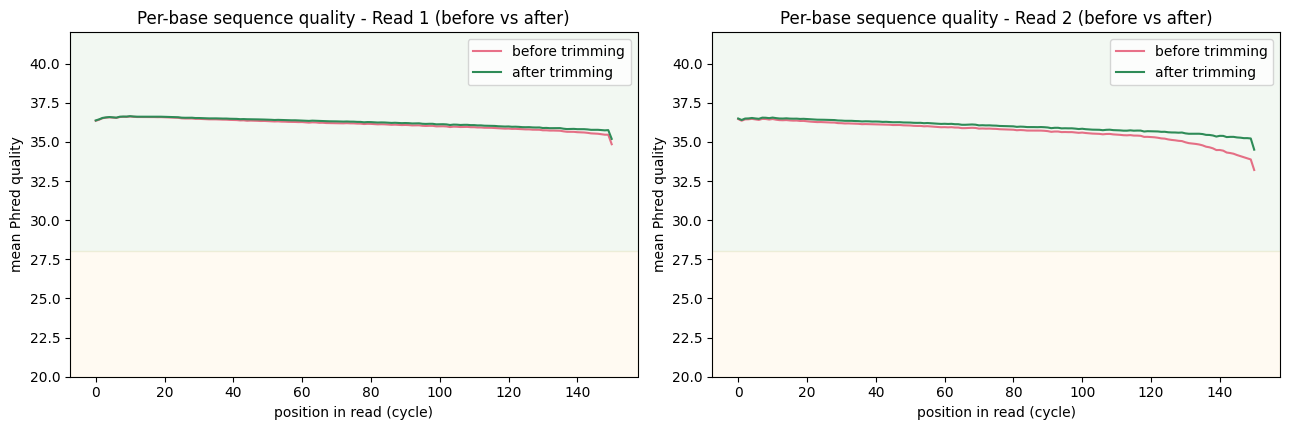

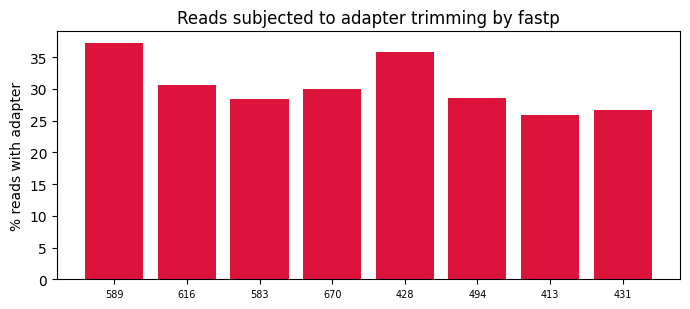

In [75]:
# --- Task 1b: FastQC before/after trimming + per-base quality / adapter comparison ---
raw_fqc  = QC/'raw_fastqc'; raw_fqc.mkdir(parents=True, exist_ok=True)
trim_fqc = QC/'trimmed_fastqc'; trim_fqc.mkdir(parents=True, exist_ok=True)
# (a0) FastQC on the RAW reads before trimming (idempotent) - reproduces the raw-read QC step
need_raw = [sid for sid in samples.index if not (raw_fqc/f'{sid}_1_fastqc.zip').exists()]
if need_raw:
    rf = ' '.join(f'/project/data/raw_fastq/{samples.loc[sid,"fastq_1"]} /project/data/raw_fastq/{samples.loc[sid,"fastq_2"]}' for sid in need_raw)
    docker_run(['bash','-lc', f'fastqc -t {THREADS} -o /project/results/qc/raw_fastqc {rf}'], log_name='nb_fastqc_raw.log')
# (a) FastQC on any trimmed read still lacking a report (idempotent; runs in the Docker image)
need = [sid for sid in samples.index if not (trim_fqc/f'{sid}_1.trimmed_fastqc.zip').exists()]
if need:
    files = ' '.join(f'/project/data/fastq_trimmed/{sid}_{r}.trimmed.fastq.gz' for sid in need for r in (1,2))
    docker_run(['bash','-lc', f'fastqc -t {THREADS} -o /project/results/qc/trimmed_fastqc {files}'],
               log_name='nb_fastqc_trimmed.log')
# (b) aggregate raw FastQC + trimmed FastQC + fastp into one before/after MultiQC report
mqc_ba = QC/'multiqc'/'multiqc_fastqc_beforeafter.html'
if not mqc_ba.exists():
    docker_run(['multiqc','/project/results/qc/raw_fastqc','/project/results/qc/trimmed_fastqc',
                '/project/results/qc/fastp','-o','/project/results/qc/multiqc',
                '-n','multiqc_fastqc_beforeafter','-f'], log_name='nb_multiqc_ba.log')
print('Before/after MultiQC report ->', mqc_ba)

# (c) Per-base sequence quality BEFORE vs AFTER, from the fastp JSONs (all 8 samples)
import numpy as _np
def _curve(section):
    arr=[]
    for sid in samples.index:
        d=json.loads((QC/'fastp'/f'{sid}.fastp.json').read_text())
        m=d.get(section,{}).get('quality_curves',{}).get('mean')
        if m: arr.append(m)
    L=min(len(a) for a in arr); return _np.array([a[:L] for a in arr]).mean(0)
fig, ax = plt.subplots(1, 2, figsize=(13,4.4))
for j,(r,lab) in enumerate([('read1','Read 1'),('read2','Read 2')]):
    b=_curve(f'{r}_before_filtering'); a=_curve(f'{r}_after_filtering')
    ax[j].plot(b, color='crimson', alpha=.6, label='before trimming'); ax[j].plot(a, color='seagreen', label='after trimming')
    ax[j].axhspan(28,42, color='green', alpha=.05); ax[j].axhspan(20,28, color='orange', alpha=.05)
    ax[j].set_ylim(20,42); ax[j].set_xlabel('position in read (cycle)'); ax[j].set_ylabel('mean Phred quality')
    ax[j].set_title(f'Per-base sequence quality - {lab} (before vs after)'); ax[j].legend()
plt.tight_layout(); plt.savefig(QC/'perbase_quality_before_after.png', dpi=150); plt.show()
before_ad=[]
for sid in samples.index:
    d=json.loads((QC/'fastp'/f'{sid}.fastp.json').read_text()); tot=d['summary']['before_filtering']['total_reads']
    before_ad.append(100*d['adapter_cutting']['adapter_trimmed_reads']/tot)
fig, ax = plt.subplots(figsize=(7,3.2)); x=range(len(samples))
ax.bar(x, before_ad, color='crimson')
ax.set_xticks(list(x)); ax.set_xticklabels([s[-3:] for s in samples.index], fontsize=7)
ax.set_ylabel('% reads with adapter'); ax.set_title('Reads subjected to adapter trimming by fastp')
plt.tight_layout(); plt.savefig(QC/'adapter_trimmed_fraction.png', dpi=150); plt.show()

In [76]:
# --- FastQC module status (raw vs trimmed): parse summary.txt from each FastQC report ---
import zipfile
def fastqc_status(folder, suffix):
    rows = {}
    for sid in samples.index:
        z = folder / f'{sid}{suffix}_fastqc.zip'
        if not z.exists(): continue
        with zipfile.ZipFile(z) as zf:
            name = [n for n in zf.namelist() if n.endswith('summary.txt')][0]
            for line in zf.read(name).decode().splitlines():
                status, module, _ = line.split('\t')
                rows.setdefault(module, {})[sid[-3:]] = status
    return pd.DataFrame(rows).T
key_modules = ['Per base sequence quality', 'Per sequence quality scores', 'Adapter Content',
               'Overrepresented sequences', 'Sequence Duplication Levels']
raw_status  = fastqc_status(raw_fqc,  '_1')
trim_status = fastqc_status(trim_fqc, '_1.trimmed')
print('FastQC module status on RAW reads (R1, per sample):')
display(raw_status.reindex([m for m in key_modules if m in raw_status.index]))
print('FastQC module status on TRIMMED reads (R1, per sample):')
display(trim_status.reindex([m for m in key_modules if m in trim_status.index]))
if 'Adapter Content' in raw_status.index:
    _ac = dict(raw_status.loc['Adapter Content'].value_counts())
    print(f'Adapter Content module (raw reads), status counts across samples: {_ac}')

FastQC module status on RAW reads (R1, per sample):


,589,616,583,670,428,494,413,431
Per base sequence quality,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Per sequence quality scores,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Adapter Content,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL
Overrepresented sequences,WARN,WARN,WARN,WARN,WARN,WARN,WARN,WARN
Sequence Duplication Levels,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL


FastQC module status on TRIMMED reads (R1, per sample):


,589,616,583,670,428,494,413,431
Per base sequence quality,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Per sequence quality scores,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Adapter Content,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Overrepresented sequences,WARN,WARN,WARN,WARN,WARN,WARN,WARN,WARN
Sequence Duplication Levels,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL


Adapter Content module (raw reads), status counts across samples: {'FAIL': np.int64(8)}


### QC flags - interpretation

Two FastQC modules come up **FAIL** (expected):

- ***Adapter Content*** (raw reads) - 3′ read-through from short inserts; removed by fastp, with the
  adapter-trimmed fraction as the quantitative check (`adapter_evidence.csv`). Resolved after trimming.
- ***Sequence Duplication Levels*** (raw and trimmed) - in RNA-seq, duplication mixes genuine
  re-sampling of highly-expressed transcripts with PCR duplicates (inseparable without UMIs); the
  reads are therefore **not deduplicated** (that would discard real expression signal).

## Part 1 - Task 2: Quantification with Salmon (gene-level)

A **transcriptome-only Salmon index** (GENCODE v28) is used.

Quantification passes the transcript-to-gene map (`--geneMap`) so Salmon writes **gene-level** counts
directly (`quant.genes.sf`) instead of quantifying transcripts and aggregating in a separate step.
`NumReads` are estimated fragment counts, rounded to integers for PyDESeq2. The `tx2gene.tsv` and `gene_annotation.tsv` maps are derived from the same GENCODE v28 GTF (transcript-to-gene and gene-to-symbol/biotype). Index
build and per-sample quantification run on the fastp-trimmed reads, one sample at a time.

In [77]:
# --- Reference (GENCODE v28, GRCh38) - download if missing, else reuse ---
# GENCODE v28 / GRCh38 matches the reference used by the paper (Gencode release 28, GRCh38.p12).
# Salmon quasi-maps to the transcriptome FASTA; the paper aligned to the genome (STAR 2-pass) + RSEM.
# Source:
#   https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_28/
GENCODE28 = 'https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_28'
tx_fa  = REF / 'gencode.v28.transcripts.fa.gz'          # transcriptome -> Salmon index
gtf_gz = REF / 'gencode.v28.annotation.gtf.gz'          # annotation -> tx2gene / gene symbols

import urllib.request
def fetch(url, dest):
    if dest.exists():
        print(dest.name, '- already present, skip download'); return
    print('downloading', dest.name, '...')
    dest.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, dest)
    print('  done:', dest)

fetch(f'{GENCODE28}/gencode.v28.transcripts.fa.gz', tx_fa)
fetch(f'{GENCODE28}/gencode.v28.annotation.gtf.gz', gtf_gz)

for f in [tx_fa, gtf_gz]:
    assert f.exists(), f'Missing reference file: {f}'
print('\nReference OK:', tx_fa.name, '+', gtf_gz.name)
print('All reference files are GENCODE release 28 (single authority + release) - FASTA/GTF/tx2gene consistent.')

gencode.v28.transcripts.fa.gz - already present, skip download
gencode.v28.annotation.gtf.gz - already present, skip download

Reference OK: gencode.v28.transcripts.fa.gz + gencode.v28.annotation.gtf.gz
All reference files are GENCODE release 28 (single authority + release) - FASTA/GTF/tx2gene consistent.


In [78]:
# --- tx2gene map (verify) + Salmon index build (idempotent, transcriptome-only) ---
t2g_path = REF / 'tx2gene.tsv'   # 2-col (transcript_id, gene_id), also passed to salmon --geneMap
assert t2g_path.exists(), f'Missing {t2g_path}'
t2g = pd.read_csv(t2g_path, sep='\t', header=None, names=['tx','gene_id'])
print('tx2gene:', t2g.shape, '- sample:')
print(t2g.head(3).to_string(index=False))

# Build the transcriptome-only Salmon index if it's not already there.
if (IDX / 'info.json').exists():
    info = json.loads((IDX/'info.json').read_text())
    print(f"\nSalmon index already built: {IDX.name}  (k={info['k']}, "
          f"num_kmers={info['num_kmers']:,}) - skipping build")
else:
    print('\nBuilding Salmon index (transcriptome-only)...')
    docker_run([
        'salmon', 'index',
        '-t', f'/project/data/reference/{tx_fa.name}',
        '-i', f'/project/data/{IDX.name}',
        '-k', 31, '-p', THREADS,
    ], log_name='nb_salmon_index.log')
    mark_state('index', IDX.name)
    print('Salmon index built ->', IDX)

tx2gene: (203835, 2) - sample:
               tx           gene_id
ENST00000456328.2 ENSG00000223972.5
ENST00000450305.2 ENSG00000223972.5
ENST00000488147.1 ENSG00000227232.5

Salmon index already built: salmon_index_v112_utf8  (k=31, num_kmers=127,543,631) - skipping build


In [79]:
# --- Task 2: salmon quant per sample (gene-level via --geneMap), from TRIMMED reads ---
# Idempotent: a sample whose quant.genes.sf exists is skipped. If not yet done this runs
# salmon runs one sample at a time. Once quantification has been
# run, all 8 are present and every iteration prints "skip".
QUANT.mkdir(parents=True, exist_ok=True)
for sid, row in samples.iterrows():
    if (QUANT / sid / 'quant.genes.sf').exists():
        print(sid, '- quant already done, skipping')
        continue
    r1 = TRIMMED / f'{sid}_1.trimmed.fastq.gz'
    r2 = TRIMMED / f'{sid}_2.trimmed.fastq.gz'
    if not (r1.exists() and r2.exists()):
        print(sid, '- trimmed reads missing, run Task 1 (fastp) first. Skipping.')
        continue
    print(sid, '- running salmon quant...')
    docker_run([
        'salmon', 'quant',
        '-i', f'/project/data/{IDX.name}',
        '-l', 'A', '-p', THREADS,
        '-1', f'/project/data/fastq_trimmed/{sid}_1.trimmed.fastq.gz',
        '-2', f'/project/data/fastq_trimmed/{sid}_2.trimmed.fastq.gz',
        '--geneMap', '/project/data/reference/tx2gene.tsv',   # -> gene-level quant.genes.sf
        '--validateMappings', '--gcBias', '--seqBias',        # selective alignment + bias correction
        '-o', f'/project/data/salmon_quants/{sid}',
    ], log_name=f'nb_quant_{sid}.log')
    mark_state('quant', sid)
    print(sid, '- quant done')

# Aggregate salmon logs (mapping rates etc.) into MultiQC (idempotent: skip if already built)
multiqc_salmon = QC / 'multiqc' / 'multiqc_salmon.html'
if multiqc_salmon.exists():
    print('MultiQC (salmon) already built, skipping ->', multiqc_salmon)
else:
    docker_run(['multiqc', '/project/data/salmon_quants',
                '-o', '/project/results/qc/multiqc', '-n', 'multiqc_salmon', '-f'],
               log_name='nb_multiqc_salmon.log')

missing_quant = [sid for sid in samples.index if not (QUANT/sid/'quant.genes.sf').exists()]
print('\nSamples still missing quant:', missing_quant if missing_quant else 'none - all 8 done')

SRR10089589 - quant already done, skipping
SRR10089616 - quant already done, skipping
SRR10089583 - quant already done, skipping
SRR10089670 - quant already done, skipping
SRR10089428 - quant already done, skipping
SRR10089494 - quant already done, skipping
SRR10089413 - quant already done, skipping
SRR10089431 - quant already done, skipping
MultiQC (salmon) already built, skipping -> e:\MS_CD4\results\qc\multiqc\multiqc_salmon.html

Samples still missing quant: none - all 8 done


In [80]:
# --- Build the gene-level count matrix (Deliverable 2) ---
# quant.genes.sf columns: Name, Length, EffectiveLength, TPM, NumReads
counts_csv = DEA / 'gene_counts_matrix.csv'
if counts_csv.exists() and list(pd.read_csv(counts_csv, index_col=0, nrows=0).columns)==list(samples.index):
    counts = pd.read_csv(counts_csv, index_col=0)
    print('Loaded existing gene count matrix:', counts.shape)
else:
    assert not missing_quant, f'Cannot build count matrix, missing quant for: {missing_quant}'
    mats = {}
    for sid in samples.index:
        sf = QUANT / sid / 'quant.genes.sf'
        df = pd.read_csv(sf, sep='\t').set_index('Name')
        mats[sid] = df['NumReads']
    counts = pd.DataFrame(mats)
    counts.index = counts.index.str.replace(r'\.\d+$', '', regex=True)   # strip Ensembl version
    counts = counts.groupby(level=0).sum()
    counts = counts.round().astype(int)
    counts = counts.loc[:, samples.index]   # keep column order = sample sheet
    counts.to_csv(counts_csv)
    print('Gene count matrix:', counts.shape)
counts

Loaded existing gene count matrix: (57964, 8)


,SRR10089589,SRR10089616,SRR10089583,SRR10089670,SRR10089428,SRR10089494,SRR10089413,SRR10089431
Name,,,,,,,,
ENSG00000000003,49,37,57,76,33,66,36,119
ENSG00000000005,0,0,0,0,0,0,0,0
ENSG00000000419,498,387,243,504,544,451,417,575
ENSG00000000457,1432,1081,1144,1624,1278,1371,1425,1741
ENSG00000000460,334,278,274,463,334,239,382,417
...,...,...,...,...,...,...,...,...
ENSG00000285498,0,0,0,0,0,0,0,0
ENSG00000285505,34,0,0,0,0,140,0,0
ENSG00000285508,0,0,0,0,0,0,0,0


In [81]:
# --- Quantification QC: gene-biotype composition and mitochondrial/rRNA fraction of the counts ---
# A low Salmon mapping rate can hide a library-quality issue, so the counts are broken down by gene
# biotype and quantify the mitochondrial + rRNA share. A large Mt/rRNA fraction would indicate
# incomplete rRNA depletion.
_annq = pd.read_csv(REF/'gene_annotation.tsv', sep='\t'); _annq['gene_id'] = _annq['gene_id'].str.replace(r'\.\d+$','',regex=True)
_sym = _annq.drop_duplicates('gene_id').set_index('gene_id')['gene_symbol']
_bio = _annq.drop_duplicates('gene_id').set_index('gene_id')['gene_biotype']
lib = counts.sum(0)
biotype = pd.Series(counts.index.map(_bio), index=counts.index).fillna('unknown')
comp = (counts.groupby(biotype).sum().sum(1) / lib.sum() * 100).sort_values(ascending=False)
print('Count fraction by gene biotype (% of assigned reads, cohort total):')
print(comp.head(8).round(2).to_string())
sym = pd.Series(counts.index.map(_sym), index=counts.index).astype(str)
mt_mask = sym.str.startswith('MT-').values
rrna_mask = biotype.isin(['rRNA','Mt_rRNA','rRNA_pseudogene']).values
mt_frac   = (counts[mt_mask].sum(0)/lib*100).round(1)
mtrrna_frac = (counts[mt_mask | rrna_mask].sum(0)/lib*100).round(1)
print('\nMitochondrial-gene count fraction per sample (%):', mt_frac.to_dict())
print('Mitochondrial + rRNA count fraction per sample (%):', mtrrna_frac.to_dict())
print(f'protein_coding share (cohort): {comp.get("protein_coding",0):.0f}%  |  mean mitochondrial+rRNA per sample: {mtrrna_frac.mean():.1f}%')

Count fraction by gene biotype (% of assigned reads, cohort total):
Name
protein_coding          84.19
misc_RNA                 5.85
lincRNA                  2.99
processed_transcript     1.30
snRNA                    1.19
ribozyme                 1.07
antisense                0.62
miRNA                    0.57

Mitochondrial-gene count fraction per sample (%): {'SRR10089589': 1.7, 'SRR10089616': 1.2, 'SRR10089583': 1.6, 'SRR10089670': 0.9, 'SRR10089428': 1.2, 'SRR10089494': 1.0, 'SRR10089413': 1.2, 'SRR10089431': 0.9}
Mitochondrial + rRNA count fraction per sample (%): {'SRR10089589': 1.7, 'SRR10089616': 1.2, 'SRR10089583': 1.6, 'SRR10089670': 0.9, 'SRR10089428': 1.2, 'SRR10089494': 1.0, 'SRR10089413': 1.2, 'SRR10089431': 0.9}
protein_coding share (cohort): 84%  |  mean mitochondrial+rRNA per sample: 1.2%


### Quantification QC - interpretation

The counts are dominated by protein-coding genes with only a small mitochondrial/rRNA fraction, so the
matrix is not rRNA-dominated. The ~40% overall Salmon mapping is expected for a transcriptome-only index
(see Task 2 and the QC paragraph): the unassigned fragments can include genome-derived intronic/intergenic reads or other fragments not represented in the transcript reference, which restricts the analysis to the transcriptomic fraction.

## Part 1 - Task 2b: Sample-level QC - outlier detection and replacement

The reference study (Kim et al., 2021) reports outlier / mis-sorted samples and removes them by PCA and
sample-distance clustering before differential expression; for this reason the **initially selected 8
samples** are screened the same way (PCA, sample correlation, cell-identity markers) before DEA. This
flagged **SRR10089503** as a clear outlier: a CD4+ library with a strong **myeloid/monocyte-like
profile** (high `LYZ`, `CD14`, `S100A9`, `FCN1`, `CST3`, depressed pan-T markers) dominating PC1
(~83% of the variance).

It was **excluded and replaced** by **SRR10089494**, restoring the balanced 4 MS / 4 HC, 2F/2M design.
SRR10089494 was selected among the eligible treatment-naive MS female samples of the same
age (32 y). `data/metadata/samples.csv` reflects this final selection; the
screening data for the initial 8 (including SRR10089503) is kept under `results/qc/outlier/`.

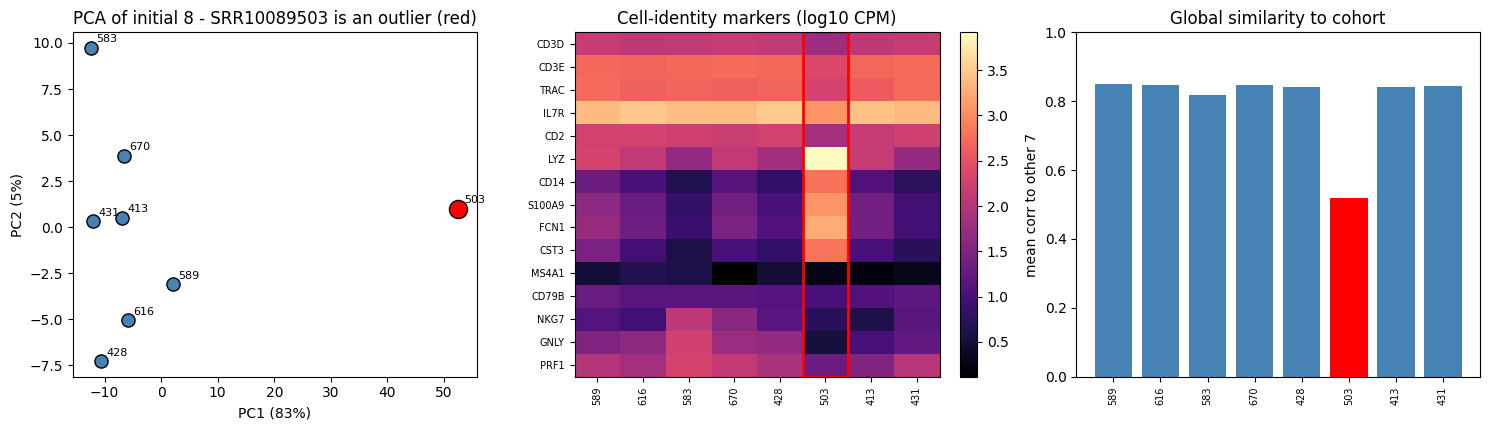

PC1 explains 83% of variance; SRR10089503 PC1 = 52.5 (all others between -12.4 and 2.0).
SRR10089503 mean correlation to others = 0.52 vs 0.84 for the rest.

Myeloid markers (CPM) - SRR10089503 vs cohort median:
  LYZ     SRR10089503=  8292.7   others median= 131.5
  CD14    SRR10089503=   623.6   others median=   9.1
  S100A9  SRR10089503=  1196.0   others median=  18.6
  FCN1    SRR10089503=  1797.5   others median=  22.4
  CST3    SRR10089503=   645.3   others median=   8.0


In [82]:
# --- Screen the INITIALLY selected 8 samples (incl. SRR10089503) for outliers ---
from sklearn.decomposition import PCA
OUTDIR = QC / 'outlier'; OUTDIR.mkdir(parents=True, exist_ok=True)
scr = pd.read_csv(OUTDIR / 'counts_screening_8.csv', index_col=0)   # initial 8, includes SRR10089503
scr_s = pd.read_csv(OUTDIR / 'samples_screening_8.csv', index_col=0)
order = list(scr_s.index)

ann0 = pd.read_csv(REF / 'gene_annotation.tsv', sep='\t')
ann0['gene_id'] = ann0['gene_id'].str.replace(r'\.\d+$', '', regex=True)
id2sym0 = ann0.drop_duplicates('gene_id').set_index('gene_id')['gene_symbol']
sym2id0 = {}
for g, s in id2sym0.items(): sym2id0.setdefault(s, g)

lib = scr.sum(0); cpm = scr / lib * 1e6
def cpm_of(sym):
    g = sym2id0.get(sym); return cpm.loc[g] if (g in cpm.index) else None

panels = {'CD4 / pan-T': ['CD3D','CD3E','TRAC','IL7R','CD2'],
          'Myeloid / monocyte': ['LYZ','CD14','S100A9','FCN1','CST3'],
          'B / NK-cytotoxic': ['MS4A1','CD79B','NKG7','GNLY','PRF1']}
rows = []
for grp, ms in panels.items():
    for m in ms:
        v = cpm_of(m)
        if v is not None: rows.append({'panel': grp, 'gene': m, **{s: round(v[s], 1) for s in order}})
markers = pd.DataFrame(rows); markers.to_csv(OUTDIR / 'identity_markers_cpm.csv', index=False)

# global correlation of each sample to the other 7 (top-2000 variable genes)
lg = np.log1p(cpm); tv = lg.var(1).sort_values(ascending=False).head(2000).index
corr = np.corrcoef(lg.loc[tv].T.values)
mean_corr = {order[i]: (corr[i].sum() - 1) / (len(order) - 1) for i in range(len(order))}

# PCA on the screened 8
Xm = np.log1p(cpm).T; tv2 = Xm.var(0).sort_values(ascending=False).head(500).index
Z = Xm[tv2].values; Z = (Z - Z.mean(0)) / (Z.std(0) + 1e-8)
pca = PCA(3).fit(Z); co = pca.transform(Z); var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for i, s in enumerate(order):
    out = s == 'SRR10089503'
    ax[0].scatter(co[i,0], co[i,1], s=170 if out else 90, c='red' if out else 'steelblue', edgecolor='k', zorder=3)
    ax[0].annotate(s[-3:], (co[i,0], co[i,1]), fontsize=8, xytext=(4,4), textcoords='offset points')
ax[0].set_xlabel(f'PC1 ({var[0]:.0f}%)'); ax[0].set_ylabel(f'PC2 ({var[1]:.0f}%)')
ax[0].set_title('PCA of initial 8 - SRR10089503 is an outlier (red)')
data = np.log10(markers.set_index('gene')[order].values + 1)
im = ax[1].imshow(data, aspect='auto', cmap='magma')
ax[1].set_xticks(range(len(order))); ax[1].set_xticklabels([s[-3:] for s in order], fontsize=7, rotation=90)
ax[1].set_yticks(range(len(markers))); ax[1].set_yticklabels(markers['gene'], fontsize=7)
ax[1].set_title('Cell-identity markers (log10 CPM)'); plt.colorbar(im, ax=ax[1], fraction=0.046)
c503 = order.index('SRR10089503')
ax[1].add_patch(plt.Rectangle((c503-0.5, -0.5), 1, len(markers), fill=False, edgecolor='red', lw=2))
mc = [mean_corr[s] for s in order]
ax[2].bar(range(len(order)), mc, color=['red' if s=='SRR10089503' else 'steelblue' for s in order])
ax[2].set_xticks(range(len(order))); ax[2].set_xticklabels([s[-3:] for s in order], fontsize=7, rotation=90)
ax[2].set_ylim(0,1); ax[2].set_ylabel('mean corr to other 7'); ax[2].set_title('Global similarity to cohort')
plt.tight_layout(); plt.savefig(OUTDIR / 'outlier_SRR10089503.png', dpi=150); plt.show()

print(f'PC1 explains {var[0]:.0f}% of variance; SRR10089503 PC1 = {co[c503,0]:.1f} '
      f'(all others between {min(x for j,x in enumerate(co[:,0]) if j!=c503):.1f} and '
      f'{max(x for j,x in enumerate(co[:,0]) if j!=c503):.1f}).')
print(f'SRR10089503 mean correlation to others = {mean_corr["SRR10089503"]:.2f} '
      f'vs {np.mean([mean_corr[s] for s in order if s!="SRR10089503"]):.2f} for the rest.')
print('\nMyeloid markers (CPM) - SRR10089503 vs cohort median:')
for m in ['LYZ','CD14','S100A9','FCN1','CST3']:
    v = cpm_of(m); med = np.median([v[s] for s in order if s!='SRR10089503'])
    print(f'  {m:7} SRR10089503={v["SRR10089503"]:8.1f}   others median={med:6.1f}')

> **Decision.** SRR10089503 is **excluded**:
> beyond its PCA outlier position it correlates poorly with the cohort (r ~ 0.5 vs ~0.85) and over-expresses
> myeloid markers relative to the cohort median. It is replaced by **SRR10089494** (treatment-naive CD4+,
> female, 32 y); the
> identity check below confirms no final sample shows the extreme myeloid profile (all retain strong T-cell
> markers).

In [83]:
# --- Final-cohort identity check ---
lib_f = counts.sum(0); cpm_f = counts / lib_f * 1e6
def _cpm(sym):          # counts per million for a gene symbol; returns NaN if the symbol is not in the annotation
    g = sym2id0.get(sym); return cpm_f.loc[g] if (g in cpm_f.index) else pd.Series(np.nan, index=counts.columns)
chk = pd.DataFrame({
    'CD3E (T)':  _cpm('CD3E').round(0),
    'TRAC (T)':  _cpm('TRAC').round(0),
    'CD4 (T)':   _cpm('CD4').round(0),
    'LYZ (myeloid)':   _cpm('LYZ').round(0),
    'CD14 (myeloid)':  _cpm('CD14').round(0),
    'MS4A1 (B)':    _cpm('MS4A1').round(1),
}, index=counts.columns)
print('Final cohort identity markers (CPM):'); print(chk.to_string())

Final cohort identity markers (CPM):
             CD3E (T)  TRAC (T)  CD4 (T)  LYZ (myeloid)  CD14 (myeloid)  MS4A1 (B)
SRR10089589     529.0     540.0    498.0          198.0            21.0        2.2
SRR10089616     482.0     447.0    409.0          132.0             9.0        3.7
SRR10089583     510.0     481.0    470.0           46.0             4.0        3.1
SRR10089670     560.0     440.0    447.0          134.0            12.0        0.3
SRR10089428     515.0     477.0    397.0           66.0             5.0        2.1
SRR10089494     510.0     492.0    417.0           83.0             9.0        1.8
SRR10089413     512.0     394.0    401.0          141.0            11.0        0.7
SRR10089431     560.0     544.0    455.0           49.0             5.0        1.1


### Final-cohort identity - interpretation

All 8 final samples have high T-cell markers (CD3E, TRAC, CD4) and low myeloid (LYZ, CD14) and B-cell (MS4A1) markers, so every library is a CD4+ T-cell sample and none reproduces the extreme myeloid-like profile that excluded SRR10089503.

## Part 1 - Task 3: Differential Expression Analysis (PyDESeq2)

**PyDESeq2** is used. The design `~ sex + condition` includes **sex as a covariate** and **condition as the biological effect of interest**, so the **MS-vs-HC** effect (HC = reference) is estimated after accounting for sex-associated expression variability. No
sex-by-condition interaction term is added and age is not included as a covariate because the samples
were tightly age-matched and show almost no age variation. Low-count genes are pre-filtered before testing.

In [84]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# PyDESeq2 wants samples x genes
counts_t = counts.T
keep = (counts_t.sum(axis=0) >= 10) & ((counts_t > 0).sum(axis=0) >= 3)   # >=10 reads total, present in >=3 samples
counts_t = counts_t.loc[:, keep]
meta = samples[['condition','sex','age']].copy()
meta['condition'] = meta['condition'].astype(str)
meta['sex'] = meta['sex'].astype(str)
print('Genes after filtering:', counts_t.shape[1])

dds = DeseqDataSet(counts=counts_t, metadata=meta, design='~ sex + condition')
dds.deseq2()

Genes after filtering: 26094


Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 5.55 seconds.

Fitting dispersion trend curve...
... done in 0.76 seconds.

Fitting MAP dispersions...
... done in 6.11 seconds.

Fitting LFCs...
... done in 4.24 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [85]:
dea_full_csv = DEA / 'dea_results_full.csv'
sample_tag = ','.join(sorted(samples.index))
tagf = DEA/'.dea_samples.txt'
cache_ok = dea_full_csv.exists() and tagf.exists() and tagf.read_text().strip()==sample_tag
if cache_ok:
    res = pd.read_csv(dea_full_csv, index_col=0)
    print('Loaded cached DEA (same sample set):', res.shape)
else:
    stat = DeseqStats(dds, contrast=['condition','MS','HC'])   # MS vs HC
    stat.summary()
    res = stat.results_df.copy(); res.index.name = 'gene_id'
    res = res.sort_values('padj'); res.to_csv(dea_full_csv); tagf.write_text(sample_tag)

ann = pd.read_csv(REF/'gene_annotation.tsv', sep='\t'); ann['gene_id'] = ann['gene_id'].str.replace(r'\.\d+$','',regex=True)
id2name = ann.drop_duplicates('gene_id').set_index('gene_id')['gene_symbol']
id2bt   = ann.drop_duplicates('gene_id').set_index('gene_id')['gene_biotype']
res['symbol']  = pd.Series(res.index.map(id2name), index=res.index).fillna(pd.Series(res.index, index=res.index))
res['biotype'] = pd.Series(res.index.map(id2bt), index=res.index)

PADJ, LFC = 0.05, 1.0
# Report BOTH criteria (the paper used FDR 5% without a fold-change cut-off; |log2FC|>=1 is added too)
n_fdr  = int((res['padj'] < PADJ).sum())
sig    = res[(res['padj'] < PADJ) & (res['log2FoldChange'].abs() >= LFC)].copy()
up, down = sig[sig['log2FoldChange']>0], sig[sig['log2FoldChange']<0]
res[res['padj']<PADJ].to_csv(DEA/'DEGs_FDR05.csv')                 # FDR-defined DEGs
sig.to_csv(DEA/'DEGs_FDR05_LFC1.csv')                              # FDR + fold-change (strong-effect subset)
up.to_csv(DEA/'DEGs_FDR05_LFC1_upregulated.csv'); down.to_csv(DEA/'DEGs_FDR05_LFC1_downregulated.csv')
print(f'DEGs at padj<{PADJ} (FDR-defined): {n_fdr}')
print(f'DEGs at padj<{PADJ} & |log2FC|>={LFC}: {len(sig)}  (up={len(up)}, down={len(down)})')

Loaded cached DEA (same sample set): (26094, 6)
DEGs at padj<0.05 (FDR-defined): 44
DEGs at padj<0.05 & |log2FC|>=1.0: 25  (up=8, down=17)


Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 5.62 seconds.



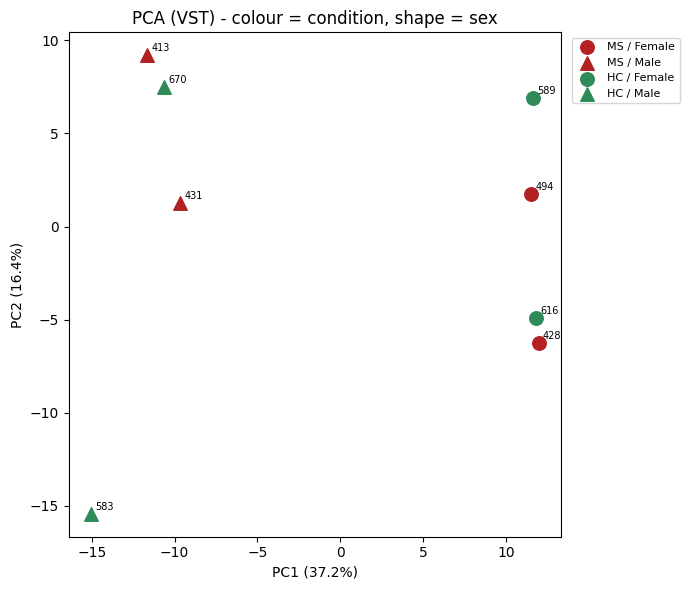

In [86]:
# --- PCA on the 500 most variable genes after VST (DESeq2 plotPCA convention: centred, NOT per-gene scaled) ---
from sklearn.decomposition import PCA
dds.vst(use_design=False)                              # variance-stabilizing transform
vst = pd.DataFrame(dds.layers['vst_counts'], index=counts_t.index, columns=counts_t.columns)
topvar = vst.var(0).sort_values(ascending=False).head(500).index
X = vst[topvar].values; X = X - X.mean(0)          # center only (matches DESeq2 plotPCA; no per-gene scaling)
pcs = PCA(n_components=2).fit(X); co = pcs.transform(X)
pc = pd.DataFrame(co, index=counts_t.index, columns=['PC1','PC2']).join(meta); var = pcs.explained_variance_ratio_*100
# Condition and sex shown simultaneously: colour = condition, marker shape = sex
_mk = {'F':'o','M':'^'}; _co = {'MS':'firebrick','HC':'seagreen'}
fig, ax = plt.subplots(figsize=(7,6))
for cond in ['MS','HC']:
    for sx in ['F','M']:
        s = pc[(pc['condition']==cond) & (pc['sex']==sx)]
        if len(s):
            ax.scatter(s['PC1'], s['PC2'], s=95, c=_co[cond], marker=_mk[sx],
                       label=f'{cond} / {"Female" if sx=="F" else "Male"}')
for sid in pc.index:
    ax.annotate(sid[-3:], (pc.loc[sid,'PC1'], pc.loc[sid,'PC2']), fontsize=7, xytext=(3,3), textcoords='offset points')
ax.set_xlabel(f'PC1 ({var[0]:.1f}%)'); ax.set_ylabel(f'PC2 ({var[1]:.1f}%)')
ax.set_title('PCA (VST) - colour = condition, shape = sex')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout(); plt.savefig(DEA/'PCA.png', dpi=150, bbox_inches='tight'); plt.show()

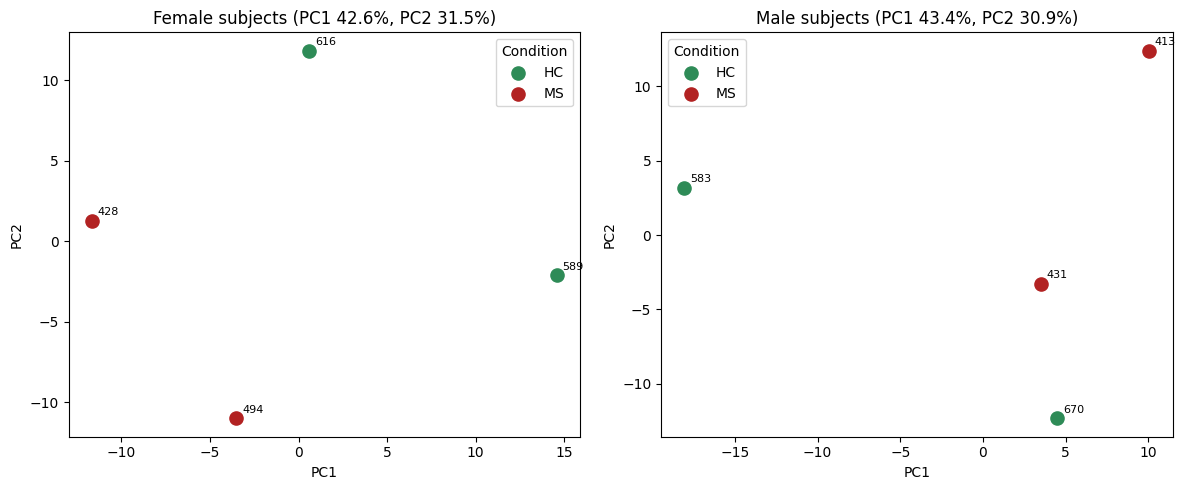

In [87]:
# --- PCA within each sex on the global 500-gene VST feature space (topvar); only the sample subset changes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, sx, title in zip(axes, ['F', 'M'], ['Female subjects', 'Male subjects']):
    sids = samples.index[samples['sex'] == sx].tolist()
    Z = vst.loc[sids, topvar].values
    Z = Z - Z.mean(axis=0)                                # center only (DESeq2 plotPCA convention)
    pca = PCA(n_components=2, random_state=SEED)
    co = pca.fit_transform(Z)
    var = pca.explained_variance_ratio_ * 100
    plot_df = pd.DataFrame(co, index=sids, columns=['PC1', 'PC2']).join(samples[['condition']])
    for cond, color in [('HC', 'seagreen'), ('MS', 'firebrick')]:
        d = plot_df[plot_df['condition'] == cond]
        ax.scatter(d['PC1'], d['PC2'], s=90, color=color, label=cond)
    for sid in plot_df.index:
        ax.annotate(sid[-3:], (plot_df.loc[sid, 'PC1'], plot_df.loc[sid, 'PC2']),
                    fontsize=8, xytext=(4, 4), textcoords='offset points')
    ax.set_title(f'{title} (PC1 {var[0]:.1f}%, PC2 {var[1]:.1f}%)')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(title='Condition')
plt.tight_layout()
plt.savefig(DEA / 'PCA_separate_by_sex.png', dpi=150)
plt.show()

### PCA - interpretation

MS and HC do not separate strongly on PC1/PC2, while part of the visible structure is associated
with sex; this supports including sex as a covariate in the overall design (`~ sex + condition`). The two sex-stratified
PCAs (2 MS vs 2 HC per panel) share the overall PCA feature space (the 500 most variable VST genes) and only
the sample subset changes; they are descriptive analyses, so their PC coordinates are not
directly comparable across panels.

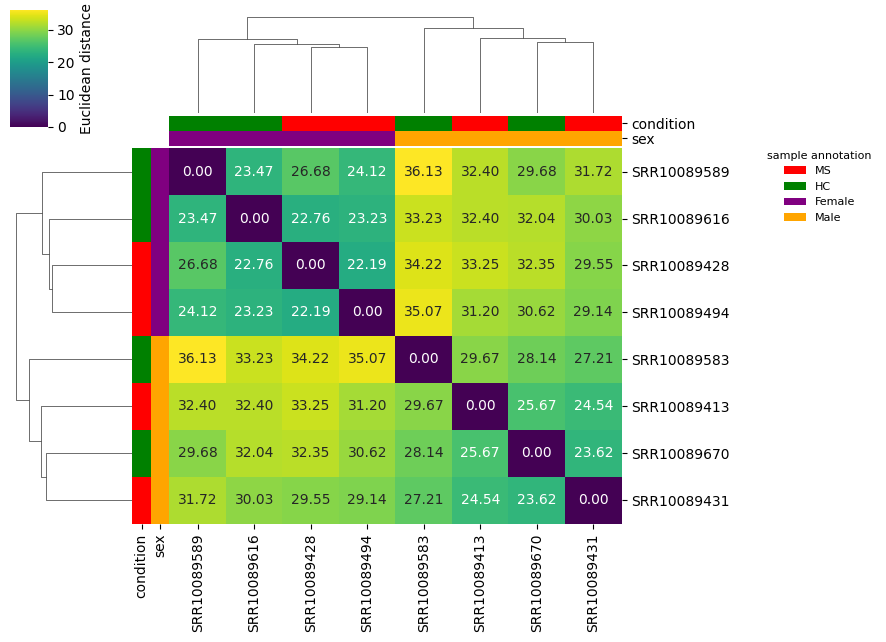

In [88]:
# --- Sample-distance heatmap: cluster with an explicit linkage built from the condensed distances ---
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage
condensed = pdist(vst[topvar].values, metric='euclidean')      # 1-D condensed distances (VST space)
dd = pd.DataFrame(squareform(condensed), index=counts_t.index, columns=counts_t.index)
row_link = linkage(condensed, method='average')                # linkage from the SAME distances
row_cols = pd.DataFrame({
    'condition': meta['condition'].map({'MS':'red','HC':'green'}),
    'sex': meta['sex'].map({'F':'purple','M':'orange'}),
}, index=counts_t.index)
# show numeric distances in the heatmap and use the SAME linkage for rows and columns
g = sns.clustermap(dd, row_linkage=row_link, col_linkage=row_link, cmap='viridis', figsize=(7.5,6.5),
                   row_colors=row_cols, col_colors=row_cols, annot=True, fmt='.2f', cbar_kws={'label':'Euclidean distance'}, vmin=0, vmax=dd.values.max())
from matplotlib.patches import Patch
_ann = [Patch(facecolor='red', label='MS'), Patch(facecolor='green', label='HC'),
        Patch(facecolor='purple', label='Female'), Patch(facecolor='orange', label='Male')]
g.ax_heatmap.legend(handles=_ann, title='sample annotation', loc='upper left',
                    bbox_to_anchor=(1.30, 1.02), frameon=False, fontsize=8, title_fontsize=8)
g.savefig(DEA/'sample_distance_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

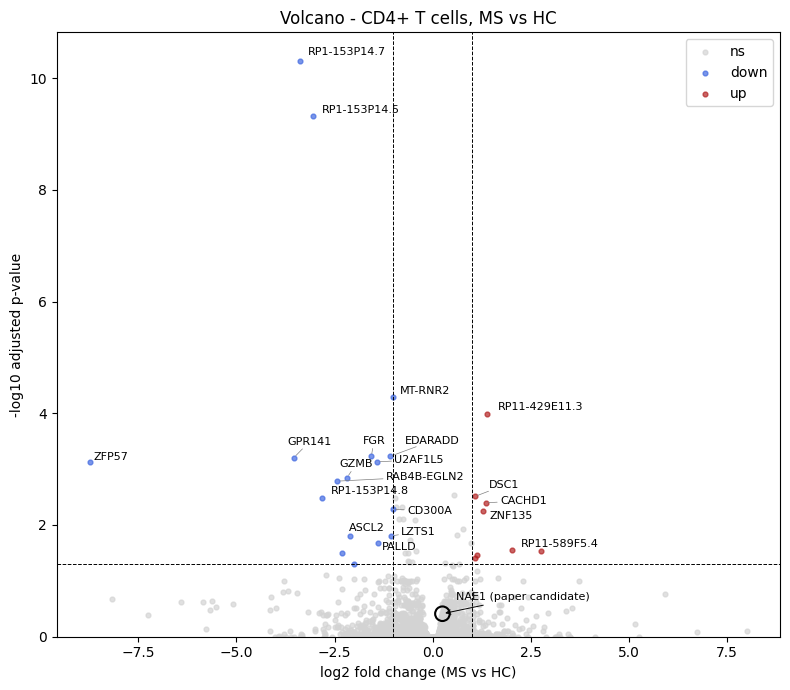

In [89]:
# --- Volcano plot ---
try:
    from adjustText import adjust_text
    HAVE_ADJUST = True
except Exception:
    HAVE_ADJUST = False

v = res.dropna(subset=['padj']).copy()
v['neglog10p'] = -np.log10(v['padj'].clip(lower=1e-300))
v['cat'] = 'ns'
v.loc[(v['padj']<PADJ)&(v['log2FoldChange']>=LFC), 'cat'] = 'up'
v.loc[(v['padj']<PADJ)&(v['log2FoldChange']<=-LFC), 'cat'] = 'down'
colors = {'ns':'lightgrey','up':'firebrick','down':'royalblue'}

fig, ax = plt.subplots(figsize=(8,7))
for c in ['ns','down','up']:
    s = v[v['cat']==c]
    ax.scatter(s['log2FoldChange'], s['neglog10p'], s=12, c=colors[c], label=c, alpha=0.7)
ax.axhline(-np.log10(PADJ), ls='--', c='k', lw=0.7)
ax.axvline(LFC, ls='--', c='k', lw=0.7); ax.axvline(-LFC, ls='--', c='k', lw=0.7)
ax.set_xlabel('log2 fold change (MS vs HC)'); ax.set_ylabel('-log10 adjusted p-value')
ax.set_title('Volcano - CD4+ T cells, MS vs HC'); ax.legend(); ax.set_ylim(bottom=0)
# label top genes by symbol
lab = v[v['cat']!='ns'].sort_values('padj').head(20)
texts = [ax.text(r['log2FoldChange'], r['neglog10p'], r['symbol'], fontsize=8) for _, r in lab.iterrows()]
if HAVE_ADJUST:
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
# Highlight NAE1 (paper candidate) 
_nae1 = v[v['symbol']=='NAE1']
if len(_nae1):
    r0 = _nae1.iloc[0]
    ax.scatter(r0['log2FoldChange'], r0['neglog10p'], s=110, facecolors='none', edgecolors='black', linewidths=1.5, zorder=6)
    ax.annotate('NAE1 (paper candidate)', (r0['log2FoldChange'], r0['neglog10p']),
                fontsize=8, xytext=(10,10), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.7))
plt.tight_layout(); plt.savefig(DEA/'volcano.png', dpi=150); plt.show()

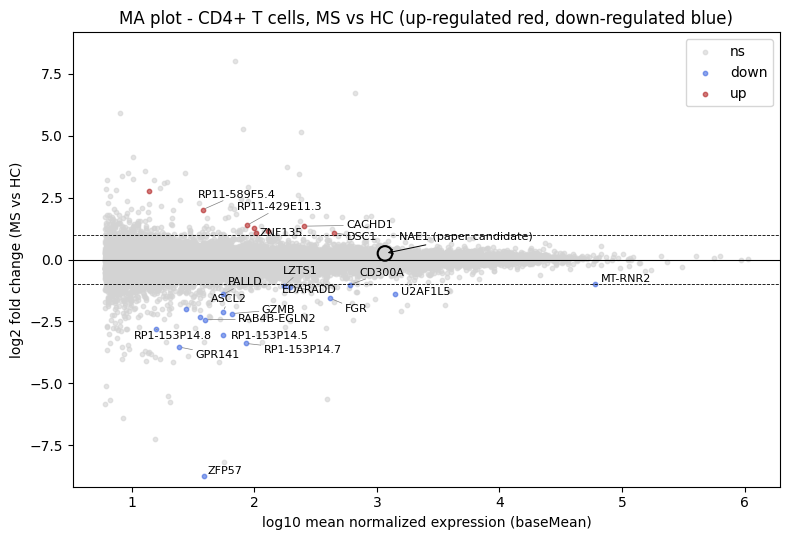

In [90]:
# --- MA plot: log2 mean expression vs log2 fold change (normalisation) ---
ma = res.dropna(subset=['padj']).copy()
ma['cat'] = 'ns'
ma.loc[(ma['padj'] < PADJ) & (ma['log2FoldChange'] >= LFC), 'cat'] = 'up'
ma.loc[(ma['padj'] < PADJ) & (ma['log2FoldChange'] <= -LFC), 'cat'] = 'down'
colors = {'ns': 'lightgrey', 'up': 'firebrick', 'down': 'royalblue'}
fig, ax = plt.subplots(figsize=(8, 5.5))
for c in ['ns', 'down', 'up']:
    s = ma[ma['cat'] == c]
    ax.scatter(np.log10(s['baseMean'] + 1), s['log2FoldChange'], s=10, c=colors[c], label=c, alpha=0.6)
ax.axhline(0, color='k', lw=0.8)
ax.axhline(LFC, ls='--', color='k', lw=0.6); ax.axhline(-LFC, ls='--', color='k', lw=0.6)
ax.set_xlabel('log10 mean normalized expression (baseMean)')
ax.set_ylabel('log2 fold change (MS vs HC)')
ax.set_title('MA plot - CD4+ T cells, MS vs HC (up-regulated red, down-regulated blue)')
ax.legend()
# label the top significant DEGs by gene symbol (as in the volcano)
lab = ma[ma['cat'] != 'ns'].sort_values('padj').head(20)
texts = [ax.text(np.log10(r['baseMean'] + 1), r['log2FoldChange'], r['symbol'], fontsize=8)
         for _, r in lab.iterrows()]
if HAVE_ADJUST:
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
# Highlight NAE1 (paper candidate), as in the volcano
_nae1 = ma[ma['symbol'] == 'NAE1']
if len(_nae1):
    r0 = _nae1.iloc[0]
    ax.scatter(np.log10(r0['baseMean'] + 1), r0['log2FoldChange'], s=110, facecolors='none',
               edgecolors='black', linewidths=1.5, zorder=6)
    ax.annotate('NAE1 (paper candidate)',
                (np.log10(r0['baseMean'] + 1), r0['log2FoldChange']),
                fontsize=8, xytext=(10, 10), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.7))
_ml = np.abs(ma['log2FoldChange']).max() * 1.05; ax.set_ylim(-_ml, _ml)
plt.tight_layout(); plt.savefig(DEA/'MA_plot.png', dpi=150); plt.show()

### MA plot - interpretation

The fold-change distribution is centred around zero, with no evident global shift. The largest
fold-changes occur at low expression, where they are least reliable.

In [91]:
# --- Top-20 DEG table (smallest padj) ---
top20 = res.sort_values('padj').head(20).reset_index()
top20 = top20.rename(columns={top20.columns[0]: 'ensembl_id'})
top20 = top20[['symbol','ensembl_id','log2FoldChange','pvalue','padj','baseMean','biotype']].copy()
top20['FDR_and_LFC_significant'] = (top20['padj'] < PADJ) & (top20['log2FoldChange'].abs() >= LFC)
top20 = top20.round({'log2FoldChange':2,'baseMean':1})
top20.to_csv(DEA/'top20_DEGs.csv', index=False)
top20

,symbol,ensembl_id,log2FoldChange,pvalue,padj,baseMean,biotype,FDR_and_LFC_significant
0,RP1-153P14.7,ENSG00000279942,-3.39,2.305072e-15,4.965355e-11,83.9,TEC,True
1,RP1-153P14.5,ENSG00000227920,-3.05,4.427569e-14,4.768714e-10,54.2,lincRNA,True
2,MT-RNR2,ENSG00000210082,-1.01,7.114755e-09,5.108631e-05,60131.7,Mt_rRNA,True
3,RP11-429E11.3,ENSG00000179253,1.38,1.949463e-08,1.049835e-04,85.9,antisense,True
4,FGR,ENSG00000000938,-1.56,1.650576e-07,5.925842e-04,416.0,protein_coding,True
5,EDARADD,ENSG00000186197,-1.09,1.650348e-07,5.925842e-04,193.7,protein_coding,True
6,GPR141,ENSG00000187037,-3.53,2.020321e-07,6.217106e-04,23.5,protein_coding,True
7,U2AF1L5,ENSG00000275895,-1.41,2.772754e-07,7.412911e-04,1406.5,protein_coding,True
8,ZFP57,ENSG00000204644,-8.73,3.097173e-07,7.412911e-04,37.9,protein_coding,True
9,GZMB,ENSG00000100453,-2.18,6.587775e-07,1.419073e-03,64.7,protein_coding,True


In [92]:
# --- Top-20 protein-coding DEG table (PPI-relevant inspection; the PPI uses all protein-coding FDR DEGs) ---
res_pc = res[res['biotype']=='protein_coding'].sort_values('padj')
top20_pc = res_pc.head(20)[['symbol','log2FoldChange','pvalue','padj','baseMean']].copy()
top20_pc['significant'] = (top20_pc['padj']<PADJ)
top20_pc = top20_pc.round({'log2FoldChange':2,'baseMean':1})
top20_pc.to_csv(DEA/'top20_DEGs_protein_coding.csv')
top20_pc

,symbol,log2FoldChange,pvalue,padj,baseMean,significant
gene_id,,,,,,
ENSG00000186197,EDARADD,-1.09,1.650348e-07,0.000593,193.7,True
ENSG00000000938,FGR,-1.56,1.650576e-07,0.000593,416.0,True
ENSG00000187037,GPR141,-3.53,2.020321e-07,0.000622,23.5,True
ENSG00000275895,U2AF1L5,-1.41,2.772754e-07,0.000741,1406.5,True
ENSG00000204644,ZFP57,-8.73,3.097173e-07,0.000741,37.9,True
ENSG00000100453,GZMB,-2.18,6.587775e-07,0.001419,64.7,True
ENSG00000171570,RAB4B-EGLN2,-2.43,8.377906e-07,0.001641,38.7,True
ENSG00000116191,RALGPS2,0.54,1.597085e-06,0.002867,587.7,True
ENSG00000134765,DSC1,1.08,1.860320e-06,0.003083,450.1,True


## Part 1 - Task 4: Enrichment analysis

At 4-vs-4 few genes reach FDR, so enrichment uses **two complementary methods** - a **ranked GSEA**
(whole ranking, the main readout) and **ORA** (cut-off based), the latter applied to three foreground
selections:

**Ranked GSEA (`gseapy.prerank`).** Every gene tested by DESeq2 is ranked by its **Wald statistic** (the signed test statistic that combines effect size and confidence) and GSEA asks whether
each gene set concentrates at the top (up in MS) or bottom (down in MS). It uses the **whole ranked list**, so it does not depend on a DEG cut-off and keeps power when few genes pass FDR (the appropriate
main readout for the mini-study).

**ORA (`gseapy.enrichr`).** Run on the **large-effect FDR DEGs (padj<0.05 and |log2FC|>=1)**, up and
down separately, with an explicit **background = all genes tested by DESeq2**.
With so few FDR DEGs this is a cross-check that complements GSEA.

**Complementary ORA views**: the same ORA on the **FDR-defined DEG set** (padj<0.05 - the paper's
DEG definition) and on the **PPI-input set** (nominal p<0.05 and |log2FC|>=log2(1.5), protein-coding) that
builds the Part-2 network.

The large-effect and FDR-defined ORAs use the all-tested-gene background. The PPI-input ORA is run on
two backgrounds as a check: all tested genes and the tested protein-coding genes (in the PPI set foreground is protein-coding by construction). The comparison
shows the directional signal is stable while enrichment breadth and significance depend on the background.
Part-1 statistics stay FDR-based and GSEA remains the main readout.

In [93]:
import gseapy as gp

GENE_SETS = ['GO_Biological_Process_2023', 'Reactome_2022', 'KEGG_2021_Human']

# ---------- Ranked GSEA on ALL tested genes (DESeq2 Wald statistic) ----------
gsea_csv = ENRICH / 'gsea_prerank.csv'
# rank = signed Wald stat; collapse duplicate symbols by mean, drop NaN
rnk = (res.loc[counts_t.columns, ['symbol', 'stat']].dropna()
          .groupby('symbol')['stat'].mean().sort_values(ascending=False))
print('Ranked genes for GSEA:', len(rnk))

if gsea_csv.exists():
    gsea = pd.read_csv(gsea_csv)
    print('Loaded cached GSEA results.')
else:
    pre = gp.prerank(rnk=rnk, gene_sets=GENE_SETS, min_size=10, max_size=500,
                     permutation_num=1000, seed=SEED, threads=THREADS, outdir=None, verbose=False)
    gsea = pre.res2d.copy()
    # normalise column names across gseapy versions
    gsea.columns = [c.strip() for c in gsea.columns]
    fdr_col = 'FDR q-val' if 'FDR q-val' in gsea.columns else [c for c in gsea.columns if 'FDR' in c][0]
    gsea = gsea.rename(columns={fdr_col: 'FDR'})
    gsea['NES'] = pd.to_numeric(gsea['NES'], errors='coerce')
    gsea['FDR'] = pd.to_numeric(gsea['FDR'], errors='coerce')
    gsea = gsea.sort_values('NES', ascending=False)
    gsea.to_csv(gsea_csv, index=False)

sig_gsea = gsea[gsea['FDR'] < 0.05]        # main GSEA significance threshold
print(f'GSEA gene sets at FDR<0.05 (main): {len(sig_gsea)}  |  at FDR<0.25 (permissive conventional): {int((gsea["FDR"]<0.25).sum())}  (of {len(gsea)} tested)')
print('\nTop pathways UP in MS (NES>0):')
print(gsea.sort_values('NES', ascending=False)[['Term','NES','FDR']].head(8).to_string(index=False))
print('\nTop pathways DOWN in MS (NES<0):')
print(gsea.sort_values('NES')[['Term','NES','FDR']].head(8).to_string(index=False))

Ranked genes for GSEA: 25973
Loaded cached GSEA results.
GSEA gene sets at FDR<0.05 (main): 232  |  at FDR<0.25 (permissive conventional): 1058  (of 4850 tested)

Top pathways UP in MS (NES>0):
                                                                                         Term      NES  FDR
                          Reactome_2022__Formation Of A Pool Of Free 40S Subunits R-HSA-72689 2.660222  0.0
Reactome_2022__L13a-mediated Translational Silencing Of Ceruloplasmin Expression R-HSA-156827 2.651592  0.0
               Reactome_2022__GTP Hydrolysis And Joining Of 60S Ribosomal Subunit R-HSA-72706 2.626766  0.0
                              Reactome_2022__Cap-dependent Translation Initiation R-HSA-72737 2.567950  0.0
                                           Reactome_2022__Viral mRNA Translation R-HSA-192823 2.567167  0.0
                                Reactome_2022__Eukaryotic Translation Termination R-HSA-72764 2.566186  0.0
                                Reactome_2022__Euk

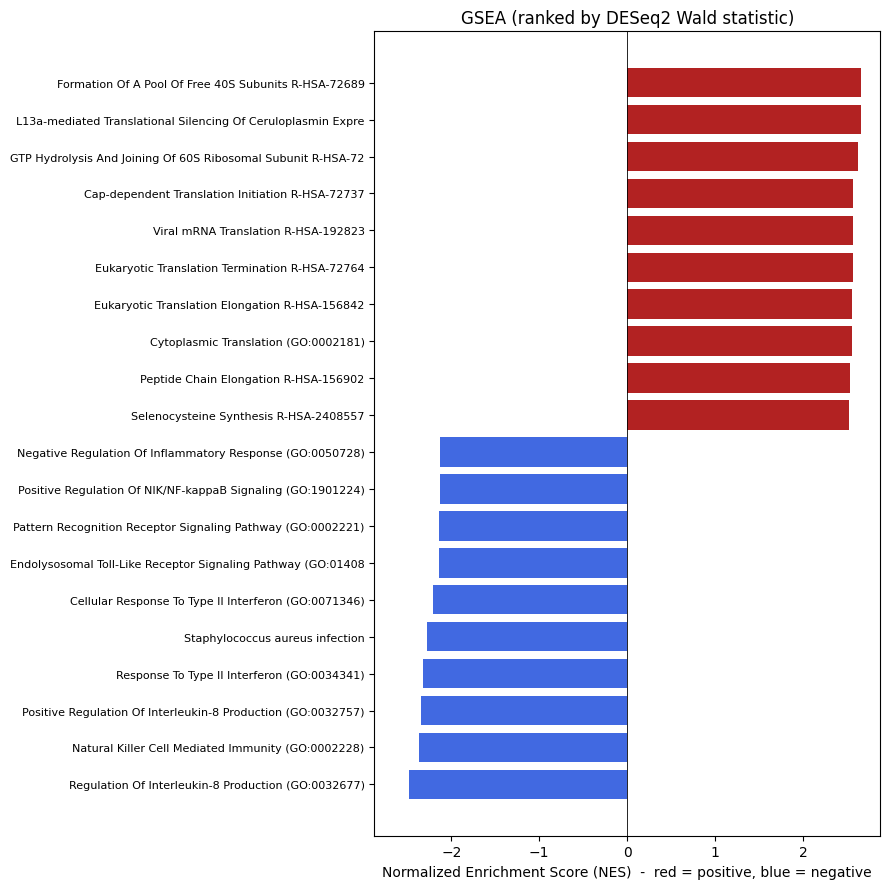

In [94]:
# --- GSEA barplot: strongest positive/negative NES ---
# GSEA: strongest positive and negative normalised enrichment scores (top/bottom of the ranking)
def gsea_barplot(g, n=10):
    if g is None or g.empty:
        print('no GSEA results'); return
    top = pd.concat([g.sort_values('NES', ascending=False).head(n),
                     g.sort_values('NES').head(n)]).drop_duplicates('Term')
    top = top.sort_values('NES')
    colors = ['firebrick' if x > 0 else 'royalblue' for x in top['NES']]
    fig, ax = plt.subplots(figsize=(9, 0.4*len(top)+1))
    ax.barh(range(len(top)), top['NES'], color=colors)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top['Term'].str.replace(r'^.*?__', '', regex=True).str.slice(0,60), fontsize=8)
    ax.axvline(0, color='k', lw=0.6); _lim = np.abs(top['NES']).max() * 1.08; ax.set_xlim(-_lim, _lim)
    ax.set_xlabel('Normalized Enrichment Score (NES)  -  red = positive, blue = negative')
    ax.set_title('GSEA (ranked by DESeq2 Wald statistic)')
    plt.tight_layout(); plt.savefig(ENRICH/'gsea_barplot.png', dpi=150); plt.show()

gsea_barplot(gsea)

### Large-effect FDR ORA

ORA on the strong-effect DEG set (padj<0.05 and |log2FC|>=1), up- and down-regulated separately, on the
all-tested-gene background. The three views below vary the DEG definition (FDR-only) and the selection
background; GSEA remains the main enrichment readout.

In [95]:
# ---------- ORA on the significant DEGs (up/down separately) ----------
# Background = all genes tested by DESeq2 that have a valid gene symbol (the experimental universe
# that could have entered the foreground). Foreground = the significant up-/down-regulated DEGs with 
# a valid symbol; foreground is a subset of the background.
background = sorted(set(res.loc[counts_t.columns, 'symbol'].dropna().astype(str)))
print('ORA background size (tested genes with a valid symbol):', len(background))

def ora(symbols, tag, bg=background):
    out_csv = ENRICH / f'ora_{tag}.csv'
    if out_csv.exists():
        print(f'ora_{tag}: loaded cached results'); return pd.read_csv(out_csv)
    symbols = [s for s in symbols if isinstance(s, str)]
    if len(symbols) < 5:
        print(f'ora_{tag}: only {len(symbols)} genes (<5) -> skipped (limited power at 4-vs-4)'); return None
    r = gp.enrichr(gene_list=symbols, gene_sets=GENE_SETS, organism='human',
                   background=bg, outdir=None).results.sort_values('Adjusted P-value')
    r.to_csv(out_csv, index=False)
    return r

# No post-DE filter is applied to the foreground. Whether mitochondrial or ribosomal genes
# dominate the DEG list is inspected instead.
large_effect_fdr_up   = sorted(set(up['symbol'].dropna().astype(str)))
large_effect_fdr_down = sorted(set(down['symbol'].dropna().astype(str)))
_techn = [s for s in large_effect_fdr_up + large_effect_fdr_down if s.startswith('MT-') or s.startswith('RPS') or s.startswith('RPL') or s.startswith('MRPS') or s.startswith('MRPL')]
print(f'Foreground: up={len(large_effect_fdr_up)}, down={len(large_effect_fdr_down)} (subset of the background).')
print('Mitochondrial/ribosomal genes among the DEGs:', _techn if _techn else 'none - the list is not dominated by them')
ora_large_effect_up   = ora(large_effect_fdr_up,   'up')
ora_large_effect_down = ora(large_effect_fdr_down, 'down')
_nu = int((ora_large_effect_up['Adjusted P-value'] < 0.05).sum()) if ora_large_effect_up is not None else 0
_nd = int((ora_large_effect_down['Adjusted P-value'] < 0.05).sum()) if ora_large_effect_down is not None else 0
print(f'Terms at FDR<0.05: up={_nu}, down={_nd}.')
print('')
print('ORA down-regulated, top terms:')
if ora_large_effect_down is not None:
    print(ora_large_effect_down[['Term','Adjusted P-value']].head(8).to_string(index=False))
print('ORA up-regulated, top terms:')
if ora_large_effect_up is not None:
    print(ora_large_effect_up[['Term','Adjusted P-value']].head(8).to_string(index=False))

ORA background size (tested genes with a valid symbol): 25973
Foreground: up=8, down=17 (subset of the background).
Mitochondrial/ribosomal genes among the DEGs: ['MT-RNR2']
ora_up: loaded cached results
ora_down: loaded cached results
Terms at FDR<0.05: up=3, down=45.

ORA down-regulated, top terms:
                                                                   Term  Adjusted P-value
                  TNFs Bind Their Physiological Receptors R-HSA-5669034          0.003357
                     Regulation Of Mast Cell Degranulation (GO:0043304)          0.004930
                        TNFR2 Non-Canonical NF-kB Pathway R-HSA-5668541          0.024827
                    Negative Regulation Of Immune Response (GO:0050777)          0.047110
Negative Regulation Of Myeloid Leukocyte Mediated Immunity (GO:0002887)          0.048217
                Negative Regulation Of Leukocyte Migration (GO:0002686)          0.048217
            DNA Methylation Involved In Embryo Development (GO:00430

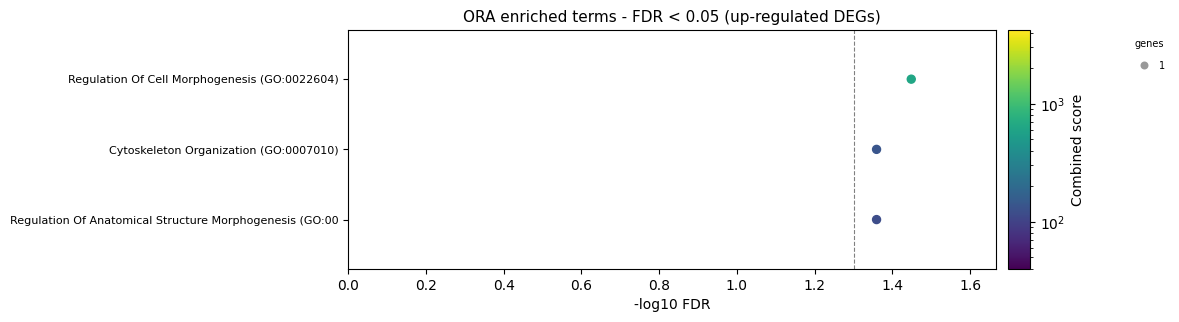

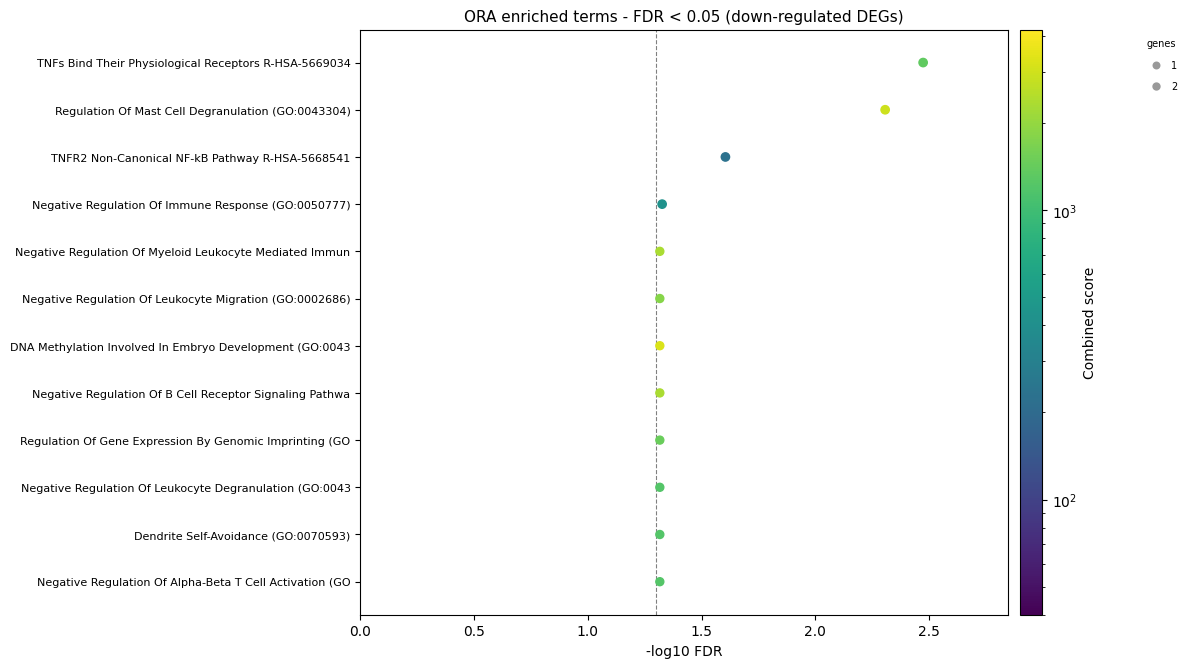

In [96]:
# ORA dotplot for the up- and down-regulated DEG subsets (a subset with fewer than 5 genes is skipped).
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
DOT_SIZE_BASE, DOT_SIZE_K = 30, 3
DOT_CNORM = LogNorm(vmin=40, vmax=4200)
_size = lambda nn: DOT_SIZE_BASE + nn * DOT_SIZE_K
def _ora_xmax(r, n=12, pad=1.15):   # shared x-limit for comparing two ORA dotplots on one scale
    if r is None or r.empty: return None
    sig = r[r['Adjusted P-value'] < 0.05]
    if sig.empty: return None
    return float(-np.log10(sig.head(n)['Adjusted P-value'].clip(lower=1e-300)).max()) * pad

def dotplot(r, tag, n=12, xmax=None):
    if r is None or r.empty:
        print(f'{tag}: no ORA to plot'); return
    sig = r[r['Adjusted P-value'] < 0.05]
    if sig.empty:
        print(f'{tag}: no term reaches FDR < 0.05'); return
    d = sig.head(n).copy()
    d['-log10FDR'] = -np.log10(d['Adjusted P-value'].clip(lower=1e-300))
    if 'Overlap' in d.columns:
        d['overlap_n'] = d['Overlap'].str.split('/').str[0].astype(int)
    else:
        d['overlap_n'] = d['Genes'].fillna('').str.split(';').apply(lambda g: len([x for x in g if x]))
    d = d.iloc[::-1]
    fig, ax = plt.subplots(figsize=(8.8, max(0.5*len(d) + 1.6, 3.0)))
    ax.axvline(-np.log10(0.05), ls='--', lw=0.8, color='grey', zorder=1)
    sc = ax.scatter(d['-log10FDR'], range(len(d)), s=_size(d['overlap_n']),
                    c=d['Combined Score'], cmap='viridis', norm=DOT_CNORM, clip_on=False, zorder=3)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Term'].str.slice(0, 55), fontsize=8)
    ax.set_ylim(-0.7, len(d) - 0.3); ax.set_xlim(0, xmax if xmax is not None else d['-log10FDR'].max() * 1.15)
    ax.set_xlabel('-log10 FDR'); ax.set_title(f'ORA enriched terms - FDR < 0.05 ({tag})', fontsize=11)
    cax = make_axes_locatable(ax).append_axes('right', size='3.5%', pad=0.12)
    plt.colorbar(sc, cax=cax, label='Combined score')
    _refs = sorted({int(d['overlap_n'].min()), int(round(d['overlap_n'].median())), int(d['overlap_n'].max())})
    _h = [Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='0.6', markeredgecolor='none',
                 markersize=np.sqrt(_size(gc)), label=str(gc)) for gc in _refs]
    ax.legend(handles=_h, title='genes', loc='upper left', bbox_to_anchor=(1.20, 1.0),
              labelspacing=1.2, handletextpad=0.6, frameon=False, fontsize=7, title_fontsize=7)
    plt.savefig(ENRICH/f'ora_dotplot_{tag}.png', dpi=150, bbox_inches='tight'); plt.show()

dotplot(ora_large_effect_up,   'up-regulated DEGs')
dotplot(ora_large_effect_down, 'down-regulated DEGs')

### FDR-defined DEG ORA

The paper defines DEGs by FDR alone, with no fold-change cutoff. As a paper-aligned additional view, ORA
is repeated on all `padj<0.05` DEGs (up and down by sign only, same tested-gene background). GSEA stays
the main readout - it already uses the whole ranking with no cutoff - and the `|log2FC|>=1` ORA above
is kept too.

In [97]:
# ---------- FDR-defined DEG ORA (padj<0.05, no |log2FC| cutoff) ----------
# The paper defines DEGs by FDR alone (no fold-change cutoff). As a paper-aligned view, ORA
# is repeated on all padj<0.05 DEGs (up/down by sign only), reusing the same ora() helper and background.
# GSEA stays the main readout (it already uses the whole ranking with no cutoff); the |log2FC|>=1 ORA
# above is kept as well.
fdr_up   = sorted(set(res[(res['padj'] < 0.05) & (res['log2FoldChange'] > 0)]['symbol'].dropna().astype(str)))
fdr_down = sorted(set(res[(res['padj'] < 0.05) & (res['log2FoldChange'] < 0)]['symbol'].dropna().astype(str)))
print(f'FDR-defined foreground (padj<0.05, no |log2FC| cutoff): up={len(fdr_up)}, down={len(fdr_down)} '
      f'(vs {len(large_effect_fdr_up)} up / {len(large_effect_fdr_down)} down with |log2FC|>=1).')
ora_fdr_up   = ora(fdr_up,   'fdr_up')
ora_fdr_down = ora(fdr_down, 'fdr_down')
_nu = int((ora_fdr_up['Adjusted P-value'] < 0.05).sum()) if ora_fdr_up is not None else 0
_nd = int((ora_fdr_down['Adjusted P-value'] < 0.05).sum()) if ora_fdr_down is not None else 0
print(f'Terms at FDR<0.05: up={_nu}, down={_nd}.')
print('')
print('ORA down-regulated (FDR-defined), top terms:')
if ora_fdr_down is not None:
    print(ora_fdr_down[['Term', 'Adjusted P-value']].head(8).to_string(index=False))
print('ORA up-regulated (FDR-defined), top terms:')
if ora_fdr_up is not None:
    print(ora_fdr_up[['Term', 'Adjusted P-value']].head(8).to_string(index=False))

FDR-defined foreground (padj<0.05, no |log2FC| cutoff): up=14, down=30 (vs 8 up / 17 down with |log2FC|>=1).
ora_fdr_up: loaded cached results
ora_fdr_down: loaded cached results
Terms at FDR<0.05: up=16, down=2.

ORA down-regulated (FDR-defined), top terms:
                                                                   Term  Adjusted P-value
                     Regulation Of Mast Cell Degranulation (GO:0043304)          0.019314
                  TNFs Bind Their Physiological Receptors R-HSA-5669034          0.020931
                    Negative Regulation Of Immune Response (GO:0050777)          0.076918
                        Regulation Of B Cell Proliferation (GO:0030888)          0.076918
                                       Cobalamin Transport (GO:0015889)          0.076918
  Negative Regulation Of B Cell Receptor Signaling Pathway (GO:0050859)          0.076918
Negative Regulation Of Myeloid Leukocyte Mediated Immunity (GO:0002887)          0.076918
            DNA Methy

The FDR-defined foreground is broader (14 up / 30 down vs 8 / 17) but noisier. Down-regulated enrichment weakens (terms at FDR<0.05 fall from 45 to 2): the broader foreground includes additional low-effect histone and non-coding loci, while the immune enrichment becomes less coherent; up-regulated enrichment instead gains terms (3 to 16) around lysosomal/catabolic and TGF-beta processes.

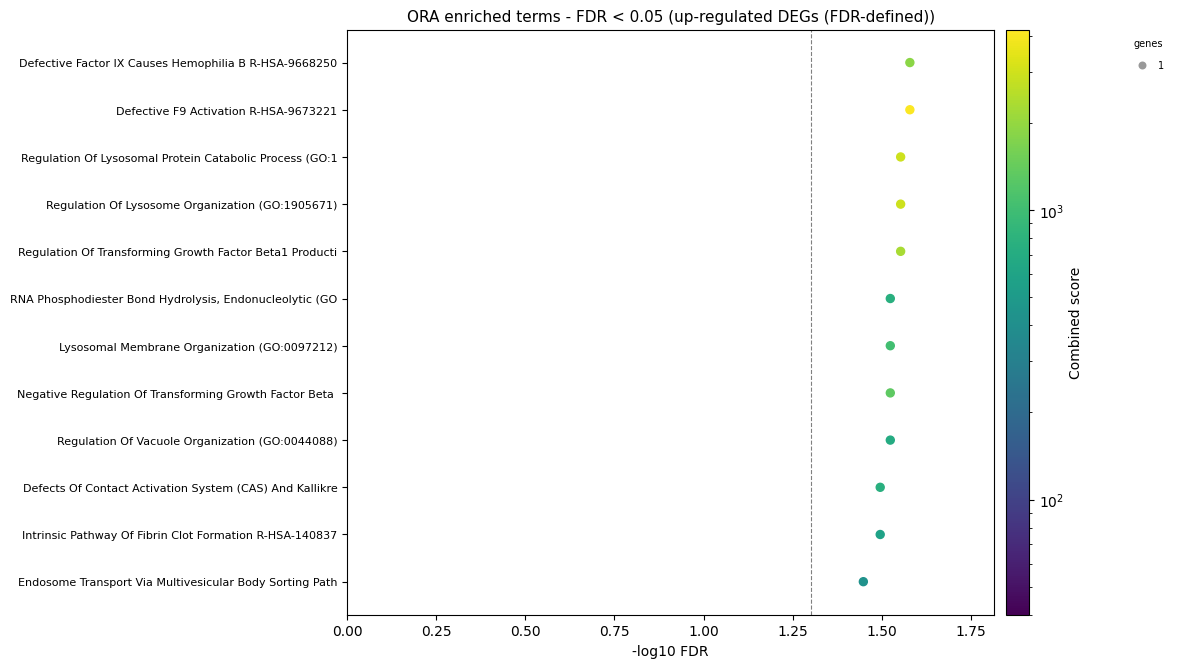

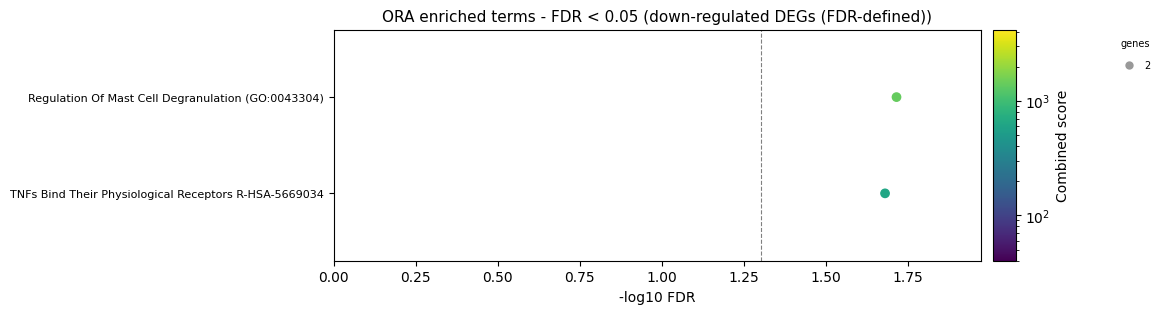

In [98]:
# --- ORA dotplot for the FDR-defined DEG subsets (paper definition) ---
dotplot(ora_fdr_up,   'up-regulated DEGs (FDR-defined)')
dotplot(ora_fdr_down, 'down-regulated DEGs (FDR-defined)')

### PPI-input ORA - all-tested background

The Part-2 STRING network is built from a Topology PPI input set (nominal p<0.05 and |log2FC| >= log2(1.5)
(~0.585)). ORA on that same set, up and down separately, summarises what the network represents at
the pathway level. Here the background is all genes tested by DESeq2; the next section repeats it on the
protein-coding background, so the two together show how strongly the background choice affects ORA. The
Topology PPI is an explicitly exploratory effect-size-filtered view and is not used for inferential DEG claims.

In [99]:
# ---------- PPI-input ORA - background sensitivity (all-tested background) ----------
# Same Topology PPI input set that builds the Part-2 network (protein-coding, nominal p<0.05 and |log2FC|>=log2(1.5)),
# split by direction like the other ORAs, on the tested-gene background.
_bio = pd.read_csv(REF / 'gene_annotation.tsv', sep='	')
_bio['gene_id'] = _bio['gene_id'].str.replace(r'\.\d+$', '', regex=True)
_bio = _bio.drop_duplicates('gene_id').set_index('gene_id')['gene_biotype']
_pc = pd.Series(res.index.map(_bio) == 'protein_coding', index=res.index)
PPI_LFC = np.log2(1.5)   # ~0.585 (|log2FC| threshold of the exploratory PPI-input set)
_rlx = res[(res['pvalue'] < 0.05) & (res['log2FoldChange'].abs() >= PPI_LFC) & _pc]
ppi_input_up   = sorted(set(_rlx[_rlx['log2FoldChange'] > 0]['symbol'].dropna().astype(str)))
ppi_input_down = sorted(set(_rlx[_rlx['log2FoldChange'] < 0]['symbol'].dropna().astype(str)))
ppi_input_genes = sorted(set(ppi_input_up) | set(ppi_input_down))  # single definition, reused by the Part-2 Topology PPI
print(f'PPI-input set (nominal p<0.05, |log2FC|>=log2(1.5), protein-coding): up={len(ppi_input_up)}, down={len(ppi_input_down)}; all-tested background: {len(background)}.')
ora_ppi_input_up   = ora(ppi_input_up,   'ppi_input_up')
ora_ppi_input_down = ora(ppi_input_down, 'ppi_input_down')
_nu = int((ora_ppi_input_up['Adjusted P-value'] < 0.05).sum()) if ora_ppi_input_up is not None else 0
_nd = int((ora_ppi_input_down['Adjusted P-value'] < 0.05).sum()) if ora_ppi_input_down is not None else 0
print(f'Terms at FDR<0.05: up={_nu}, down={_nd}.')
print('')
print('PPI-input ORA (all-tested background), down-regulated, top terms:')
if ora_ppi_input_down is not None:
    print(ora_ppi_input_down[['Term', 'Adjusted P-value']].head(8).to_string(index=False))
print('PPI-input ORA (all-tested background), up-regulated, top terms:')
if ora_ppi_input_up is not None:
    print(ora_ppi_input_up[['Term', 'Adjusted P-value']].head(8).to_string(index=False))

PPI-input set (nominal p<0.05, |log2FC|>=log2(1.5), protein-coding): up=89, down=271; all-tested background: 25973.
ora_ppi_input_up: loaded cached results
ora_ppi_input_down: loaded cached results
Terms at FDR<0.05: up=0, down=293.

PPI-input ORA (all-tested background), down-regulated, top terms:
                                             Term  Adjusted P-value
                 Signal Transduction R-HSA-162582      1.206113e-10
Class A/1 (Rhodopsin-like Receptors) R-HSA-373076      3.395616e-10
                 GPCR Ligand Binding R-HSA-500792      2.204985e-09
                       Immune System R-HSA-168256      8.186631e-09
    Peptide Ligand-Binding Receptors R-HSA-375276      2.515097e-07
                   Signaling By GPCR R-HSA-372790      7.136600e-07
           GPCR Downstream Signaling R-HSA-388396      2.713922e-06
                           MAPK signaling pathway      1.611042e-05
PPI-input ORA (all-tested background), up-regulated, top terms:
                        

### PPI-input ORA - protein-coding background

The PPI-input foreground is protein-coding by construction, so a non-protein-coding gene could never enter
it. The correct selection universe is therefore the tested protein-coding genes - this is the
methodologically principal version. Comparing it with the all-tested background above shows that the
directional message is stable while the number and significance of enriched terms are background-sensitive.

In [100]:
# ---------- PPI-input ORA - background sensitivity (protein-coding background) ----------
_tested_pc = res.loc[counts_t.columns]
_tested_pc = _tested_pc[_tested_pc.index.map(_bio) == 'protein_coding']
background_pc = sorted(set(_tested_pc['symbol'].dropna().astype(str)))
print(f'PPI-input set: up={len(ppi_input_up)}, down={len(ppi_input_down)}; protein-coding background: {len(background_pc)}.')
ora_ppi_input_pc_up   = ora(ppi_input_up,   'ppi_input_pc_up',   bg=background_pc)
ora_ppi_input_pc_down = ora(ppi_input_down, 'ppi_input_pc_down', bg=background_pc)
_nu = int((ora_ppi_input_pc_up['Adjusted P-value'] < 0.05).sum()) if ora_ppi_input_pc_up is not None else 0
_nd = int((ora_ppi_input_pc_down['Adjusted P-value'] < 0.05).sum()) if ora_ppi_input_pc_down is not None else 0
print(f'Terms at FDR<0.05 (protein-coding background): up={_nu}, down={_nd}.')
print('')
print('PPI-input ORA (protein-coding background), down-regulated, top terms:')
if ora_ppi_input_pc_down is not None:
    print(ora_ppi_input_pc_down[['Term', 'Adjusted P-value']].head(8).to_string(index=False))
print('PPI-input ORA (protein-coding background), up-regulated, top terms:')
if ora_ppi_input_pc_up is not None:
    print(ora_ppi_input_pc_up[['Term', 'Adjusted P-value']].head(8).to_string(index=False))

# shared x-limit so the two PPI-input down-regulated dotplots are directly comparable
ppi_down_xmax = max([x for x in (_ora_xmax(ora_ppi_input_down), _ora_xmax(ora_ppi_input_pc_down)) if x is not None], default=None)

PPI-input set: up=89, down=271; protein-coding background: 15811.
ora_ppi_input_pc_up: loaded cached results
ora_ppi_input_pc_down: loaded cached results
Terms at FDR<0.05 (protein-coding background): up=0, down=68.

PPI-input ORA (protein-coding background), down-regulated, top terms:
                                             Term  Adjusted P-value
Class A/1 (Rhodopsin-like Receptors) R-HSA-373076          0.000002
                 GPCR Ligand Binding R-HSA-500792          0.000015
    Peptide Ligand-Binding Receptors R-HSA-375276          0.000089
        Natural killer cell mediated cytotoxicity          0.002424
                 Signal Transduction R-HSA-162582          0.002770
                   Signaling By GPCR R-HSA-372790          0.003012
                           MAPK signaling pathway          0.003340
          Transcriptional misregulation in cancer          0.003475
PPI-input ORA (protein-coding background), up-regulated, top terms:
                                 

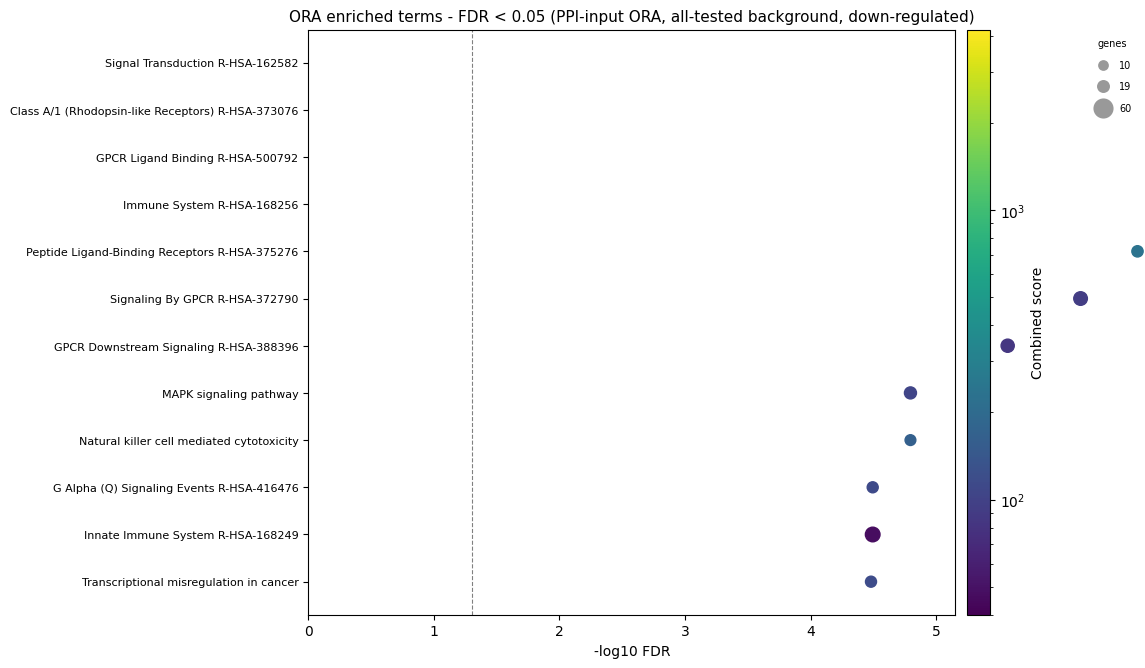

PPI-input ORA, all-tested background, up-regulated: no term reaches FDR < 0.05


In [101]:
# --- PPI-input ORA dotplot, all-tested background; down-regulated shares the x-axis with the protein-coding view ---
dotplot(ora_ppi_input_down, 'PPI-input ORA, all-tested background, down-regulated', xmax=ppi_down_xmax)
dotplot(ora_ppi_input_up,   'PPI-input ORA, all-tested background, up-regulated')

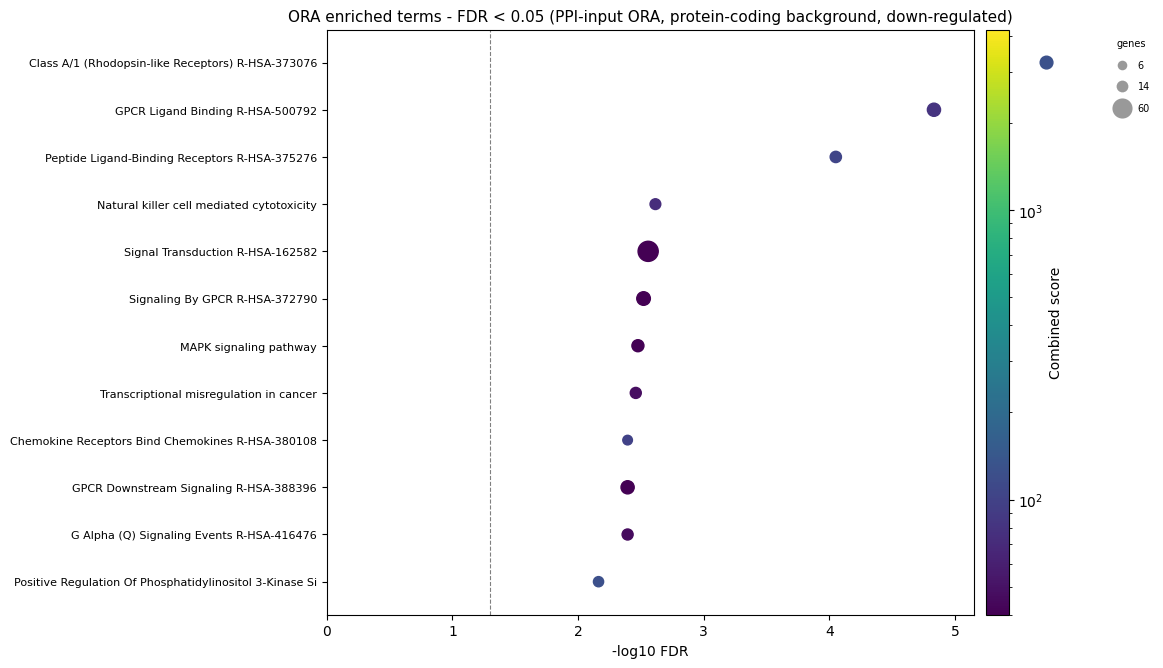

PPI-input ORA, protein-coding background, up-regulated: no term reaches FDR < 0.05


In [102]:
# --- PPI-input ORA dotplot, protein-coding background; down-regulated on the shared x-axis ---
dotplot(ora_ppi_input_pc_down, 'PPI-input ORA, protein-coding background, down-regulated', xmax=ppi_down_xmax)
dotplot(ora_ppi_input_pc_up,   'PPI-input ORA, protein-coding background, up-regulated')

### Enrichment - summary and biological interpretation

**What each view shows.**
- **Ranked GSEA.** Up in MS: **translation / ribosome biogenesis**. Down in MS:
  **interferon-gamma response, IL-8 production, NK-cell-associated / cytotoxic immune gene programmes and TLR/NF-kB signalling**
  (NES ~ -2.1 to -2.5). A weaker **protein-ubiquitination / E3-ligase** signal is also present (NES ~1.9).
- **ORA on the large-effect FDR DEGs (padj<0.05 & |log2FC|>=1).** The down set is enriched for **TNF / TNFR2
  NF-kB signalling, mast-cell degranulation and negative regulation of immune responses**; the up set
  gives only a few cytoskeleton / morphogenesis terms.
- **ORA on the FDR-defined DEGs.** Broader but noisier: the down signal weakens (the extra
  low-effect genes include histone and non-coding loci), the up signal gains lysosomal / catabolic and TGF-beta
  terms - so the result depends on the DEG definition.
- **ORA on the PPI-input set (up/down, two backgrounds).** The enrichment is carried **entirely by the
  down-regulated genes** (chemokine-receptor / GPCR signalling, immune system, MAPK and NK cytotoxicity),
  while the up-regulated genes give **no significant term** in either background. Down-side significant
  terms drop from **293** (all-tested background) to **68** (protein-coding background), with **0**
  up-regulated terms in both: the core GPCR/chemokine/MAPK/NK signal is preserved, while enrichment
  breadth and significance are strongly background-sensitive.

**Biological reading.** A recurring feature across the thresholded analyses is the **negative enrichment
of immune-signalling programmes** - genes associated with these programmes are expressed at lower levels
in MS - whereas ranked GSEA additionally reveals a strong **positive translation / ribosome signature**.

- **Down in MS - immune-effector and signalling programmes.** *Signalling* is how a cell receives an
  instruction: a molecule binds a receptor and triggers a cascade inside the cell. The down-regulated
  modules are how immune cells detect threats and coordinate a response: the **interferon response**
  (interferons are signalling proteins that cells release to activate antiviral and immune defence),
  **IL-8** (a *chemokine* - a small protein that recruits other immune cells to a site),
  **NK-cell-associated / cytotoxic immune gene programmes** (genes linked to NK-mediated cytotoxicity) and
  **chemokine-receptor / GPCR and NF-kB signalling** (GPCRs are a large family of surface receptors
  that read chemokine signals; NF-kB is a transcription factor - a protein that switches inflammatory
  genes on). Genes associated with these programmes are therefore expressed at lower levels in MS.
- **Up in MS - protein synthesis.** The strongest positive signal is **translation and ribosome
  biogenesis**: translation is the process by which a cell reads mRNA to build proteins, carried out by
  ribosomes, and ribosome biogenesis is the production of the ribosomes themselves. Up-regulating this
  is **compatible with increased biosynthetic activity**: the data show translation up, but do not
  directly measure proliferation or activation.

The immune / chemokine axis recurs both in the DEG-based enrichment (Part 1) and in the network genes
and communities (Part 2), while the translation signature is the single strongest GSEA theme. The
comparison with the paper's neddylation / NAE1 result is made in Task 5.


## Part 1 - Task 5: Comparison with the paper

**Paper's key CD4 conclusion.** Kim et al. (*Brain* 2021) report **NAE1 upregulation** together with broader **dysregulation of
neddylation-associated genes** and post-translational-modification pathways in treatment-naive MS CD4+
T cells, and nominate **NAE1** (NEDD8-activating enzyme) as a therapeutic target (with UBE2F, VHL, AKIP1,
SMURF1, "Ubl conjugation" enrichment and pevonedistat validation).

**What this mini-study recovers.**
- **NAE1 is directionally and nominally consistent** (log2FC +0.25, nominal p ~ 0.005) but **does not
  survive FDR** (padj ~ 0.39); the rest of the neddylation core (UBA3, UBE2F, UBE2M, NEDD8, CUL1, RBX1)
  shows small, non-FDR-significant effects (targeted table below).
- The GSEA readout is a broad **translation / ribosome-biogenesis** programme, with only a
  **weaker protein-ubiquitination / E3-ligase** signal (NES ~1.9, FDR ~0.01-0.02) whose catabolic
  direction is ambiguous.

**Interpretation.** The mini-study does not confirm NAE1 after FDR correction; it detects a translation
signature plus a weak ubiquitin/E3-ligase hint, compatible with perturbation of related ubiquitin-like/post-translational-modification machinery, but not specific evidence for neddylation.

**Expected discrepancies.** 4-vs-4 subsampling has limited statistical power and is sensitive to donor composition, and
the pipelines differ (Salmon here vs STAR 2-pass + RSEM in the paper); pathway-level trends are therefore
recovered more readily than the exact NAE1 signal. The design also differs: the paper models both **sex and
age** as covariates, whereas here sex is a covariate but age is not, because age was effectively fixed by
matching the eight donors at 31-32 years (`~ sex + condition`).

In [103]:
# --- Targeted neddylation / ubiquitin table (observed direction vs the paper's) ---
ned_genes = ['NAE1','UBA3','UBE2F','UBE2M','NEDD8','CUL1','RBX1','VHL','AKIP1','SMURF1']
paper_dir = {'NAE1':'up','UBE2F':'dysregulated','VHL':'dysregulated','AKIP1':'dysregulated','SMURF1':'dysregulated'}  # Kim et al.: NAE1 up; others reported dysregulated
rows=[]
for g in ned_genes:
    r = res[res['symbol']==g]
    if len(r):
        rows.append({'gene':g,'baseMean':round(r['baseMean'].values[0],1),
                     'log2FC':round(r['log2FoldChange'].values[0],2),
                     'pvalue':f"{r['pvalue'].values[0]:.2g}",'padj':f"{r['padj'].values[0]:.2g}",
                     'notebook_direction':'up' if r['log2FoldChange'].values[0]>0 else 'down',
                     'paper_report':paper_dir.get(g,'-')})
ned_tbl = pd.DataFrame(rows); ned_tbl.to_csv(DEA/'neddylation_genes.csv', index=False)
print('Neddylation/ubiquitin core - none reaches padj<0.05 in this mini-study:')
ned_tbl

Neddylation/ubiquitin core - none reaches padj<0.05 in this mini-study:


,gene,baseMean,log2FC,pvalue,padj,notebook_direction,paper_report
0,NAE1,1162.8,0.25,0.0054,0.39,up,up
1,UBA3,1495.0,0.11,0.35,1,up,-
2,UBE2F,1107.4,0.12,0.4,1,up,dysregulated
3,UBE2M,775.0,-0.06,0.61,1,down,-
4,NEDD8,980.8,-0.07,0.51,1,down,-
5,CUL1,2674.6,0.05,0.58,1,up,-
6,RBX1,716.2,0.02,0.84,1,up,-
7,VHL,3025.5,0.16,0.17,1,up,dysregulated
8,AKIP1,340.2,-0.14,0.43,1,down,dysregulated
9,SMURF1,1269.3,-0.20,0.076,0.94,down,dysregulated


## Part 2 - Task 1: PPI network, centrality and communities

Starting from the Part-1 differential expression, the analysis:
1. builds a STRING **physical** PPI
network from the DEG set, 
2. ranks nodes by **betweenness centrality** and defines the betweenness-derived
disease module, 
3. detects communities and relates them to the Part-1 enrichment,
4. adds the DrugBank targets of three MS drugs (**Betaferon, Tecfidera, Ocrevus**) and computes drug-disease
network proximity.

**FDR-DEG PPI.** The FDR-DEG PPI is built from the FDR DEG set (adjusted p-value < 0.05); only
protein-coding DEGs are eligible for STRING physical mapping (score >= 400) and degree-zero isolates
are retained. At this sample size its only non-trivial connected component is a five-node histone clique with
identical centralities, too sparse to define a rankable 10-15-node module.

**Betweenness-derived disease module.** The 10-15-node module is defined on a Topology PPI (nominal p < 0.05
and |log2FC| >= log2(1.5) (~0.585), protein-coding). Nodes are ranked by betweenness centrality (bottlenecks; degree
tie-break) and the top 15 form the betweenness-derived disease module used for the main drug-disease proximity;
Louvain community detection is performed on the full Topology PPI largest component. Betweenness is computed on the unweighted topology while Louvain uses the STRING score as an edge weight.

**Additional checks.** The FDR-connected core and a high-confidence STRING threshold (score >= 700) are
reported as checks under alternative gene-set and confidence choices; they do not replace the betweenness-derived disease module.

In [104]:
import requests, networkx as nx
from io import StringIO
STRING_API = 'https://string-db.org/api'
def string_network(genes, species=9606, required_score=400, net_type='physical'):
    params = {'identifiers':'%0d'.join(genes),'species':species,'required_score':required_score,
              'network_type':net_type,'caller_identity':'bsb_assignment'}
    r = requests.post(f'{STRING_API}/tsv/network', data=params, timeout=180); r.raise_for_status()
    return pd.read_csv(StringIO(r.text), sep='\t')
def string_ids(genes, species=9606):
    r = requests.post(f'{STRING_API}/tsv/get_string_ids',
        data={'identifiers':'\r'.join(genes),'species':species,'echo_query':1,'caller_identity':'bsb_assignment'}, timeout=180)
    r.raise_for_status(); m = pd.read_csv(StringIO(r.text), sep='\t')
    col = 'queryItem' if 'queryItem' in m.columns else m.columns[0]
    return dict(zip(m[col].astype(str), m['preferredName']))

# ---- FDR-DEG PPI: built from the exact Part-1 DEG set (FDR padj<PADJ) ----
# A PPI is a protein-protein network: only protein-coding DEGs can produce nodes and are queried in
# STRING. Protein-coding DEGs that STRING does not map are reported as STRING-unmapped.
# All STRING-mapped proteins are kept, including those with no physical edge (degree-zero isolates).
fdr_degs = res[res['padj'] < PADJ].copy()
fdr_degs_pc  = sorted(set(fdr_degs.loc[fdr_degs['biotype']=='protein_coding','symbol'].dropna().astype(str)))
fdr_degs_nc  = sorted(set(fdr_degs.loc[fdr_degs['biotype']!='protein_coding','symbol'].dropna().astype(str)))
edges_fdr = string_network(fdr_degs_pc, required_score=400, net_type='physical')
edges_fdr.to_csv(NET/'string_edges_fdr.tsv', sep='\t', index=False)
sym2pref = string_ids(fdr_degs_pc)
mapped_pref = sorted(set(sym2pref.values()))
unmapped_pc = sorted(set(fdr_degs_pc) - set(sym2pref))
G_fdr = nx.Graph(); G_fdr.add_nodes_from(mapped_pref)
for _, e in edges_fdr.iterrows():
    G_fdr.add_edge(e['preferredName_A'], e['preferredName_B'], weight=float(e['score']))
interacting = [n for n in G_fdr if G_fdr.degree(n) > 0]
isolates    = [n for n in G_fdr if G_fdr.degree(n) == 0]
print('FDR-DEG PPI funnel (biotype-aware):')
print(f'  total Part-1 DEGs (padj<{PADJ}): {fdr_degs["symbol"].dropna().nunique()}')
print(f'  protein-coding DEGs (eligible for PPI): {len(fdr_degs_pc)} | non-protein-coding (not eligible): {len(fdr_degs_nc)}')
print(f'  STRING-mapped proteins: {len(mapped_pref)} | STRING-unmapped protein-coding: {len(unmapped_pc)}')
print(f'  interacting proteins: {len(interacting)} | mapped isolates (degree 0): {len(isolates)} | edges: {G_fdr.number_of_edges()}')
print(f'  connected components: {nx.number_connected_components(G_fdr)} '
      f'| largest connected component: {len(max(nx.connected_components(G_fdr), key=len)) if G_fdr.number_of_nodes() else 0} nodes')
nx.write_graphml(G_fdr, NET/'ppi_fdr_network.graphml')

# ---- Topology PPI (betweenness-derived disease-module basis; nominal p<0.05 & |log2FC|>=log2(1.5), PC) ----
# Reported separately because the FDR-DEG PPI above is too sparse for informative topology at 4-vs-4. 
# ppi_input_genes is the exact PPI-input ORA foreground (defined once above), reused here so the Topology PPI 
# and the PPI-input ORA share one identical gene set.
edges_csv = NET / 'string_edges_topology.tsv'
if edges_csv.exists() and edges_csv.stat().st_size > 200:
    edges = pd.read_csv(edges_csv, sep='\t')
else:
    edges = string_network(ppi_input_genes, required_score=400, net_type='physical'); edges.to_csv(edges_csv, sep='\t', index=False)
pd.Series(ppi_input_genes, name='gene').to_csv(NET/'ppi_input_genes.csv', index=False)
print(f'\nTopology PPI (betweenness-derived disease-module basis): {len(ppi_input_genes)} genes sent (nominal p<0.05, |log2FC|>=log2(1.5), protein-coding).')
edges[['preferredName_A', 'preferredName_B', 'score']].head()

FDR-DEG PPI funnel (biotype-aware):
  total Part-1 DEGs (padj<0.05): 44
  protein-coding DEGs (eligible for PPI): 33 | non-protein-coding (not eligible): 11
  STRING-mapped proteins: 31 | STRING-unmapped protein-coding: 2
  interacting proteins: 5 | mapped isolates (degree 0): 26 | edges: 10
  connected components: 27 | largest connected component: 5 nodes

Topology PPI (betweenness-derived disease-module basis): 360 genes sent (nominal p<0.05, |log2FC|>=log2(1.5), protein-coding).


,preferredName_A,preferredName_B,score
0,SKAP2,LYN,0.457
1,GADD45B,GADD45G,0.928
2,CENPM,H4C6,0.895
3,CENPM,CENPU,0.993
4,GZMB,LYN,0.556


In [105]:
# --- FDR-DEG PPI topology: centrality + community detection ---
# The full FDR-DEG PPI graph (isolates included) is retained. Degree and betweenness are reported on the
# full graph; closeness and eigenvector are path-based and are computed on the largest connected
# component (LCC), because they are not comparable across disconnected components. Isolates are kept
# and reported separately. The connected nodes form a clique with tied centralities and cannot be
# ranked; the betweenness-derived disease module (Part-2 Topology PPI) is used for the top-10/15 analysis.
import networkx.algorithms.community as nxcom

deg_p = dict(G_fdr.degree())
btw_p = nx.betweenness_centrality(G_fdr, weight=None)
if G_fdr.number_of_edges():
    lcc_nodes = max(nx.connected_components(G_fdr), key=len)
    G_fdr_lcc = G_fdr.subgraph(lcc_nodes).copy()
    clo_p = nx.closeness_centrality(G_fdr_lcc)
    try:
        eig_p = nx.eigenvector_centrality(G_fdr_lcc, max_iter=1000)
    except Exception:
        eig_p = {n: np.nan for n in G_fdr_lcc}
else:
    G_fdr_lcc = nx.Graph(); clo_p = {}; eig_p = {}
centrality_fdr = pd.DataFrame({
    'degree': pd.Series(deg_p), 'betweenness': pd.Series(btw_p),
    'closeness_LCC': pd.Series(clo_p), 'eigenvector_LCC': pd.Series(eig_p)}).fillna(0.0)
centrality_fdr = centrality_fdr.sort_values(['degree','betweenness'], ascending=False)
centrality_fdr.to_csv(NET/'centrality_fdr.csv')
connected_fdr = [n for n in centrality_fdr.index if deg_p.get(n, 0) > 0]
fdr_connected_core = connected_fdr[:15]
print(f'FDR-DEG PPI: {G_fdr.number_of_nodes()} nodes ({len(isolates)} isolates), {G_fdr.number_of_edges()} edges, '
      f'{nx.number_connected_components(G_fdr)} components.')
print(f'FDR-connected core (n={len(fdr_connected_core)}, clique with tied centralities): {fdr_connected_core}')
if G_fdr.number_of_edges():
    louvain_p = nxcom.louvain_communities(G_fdr_lcc, weight='weight', seed=42)
    part_fdr = {n: i for i, com in enumerate(louvain_p) for n in com}
    pd.Series(part_fdr, name='community').sort_index().to_csv(NET/'communities_fdr.csv')
    print(f'FDR-DEG PPI Louvain (on LCC): {len(louvain_p)} communities, '
          f'modularity={nxcom.modularity(G_fdr_lcc, louvain_p, weight="weight"):.3f}')
else:
    print('FDR-DEG PPI has no edges: community detection not defined.')
centrality_fdr.head(15)

FDR-DEG PPI: 31 nodes (26 isolates), 10 edges, 27 components.
FDR-connected core (n=5, clique with tied centralities): ['H2AC12', 'H2AC13', 'H2AC18', 'H2BC17', 'H2BC5']
FDR-DEG PPI Louvain (on LCC): 1 communities, modularity=-0.000


,degree,betweenness,closeness_LCC,eigenvector_LCC
H2AC12,4,0.0,1.0,0.447214
H2AC13,4,0.0,1.0,0.447214
H2AC18,4,0.0,1.0,0.447214
H2BC17,4,0.0,1.0,0.447214
H2BC5,4,0.0,1.0,0.447214
ADGRE1,0,0.0,0.0,0.000000
APOBEC3G,0,0.0,0.0,0.000000
ASCL2,0,0.0,0.0,0.000000
CACHD1,0,0.0,0.0,0.000000
CD300A,0,0.0,0.0,0.000000


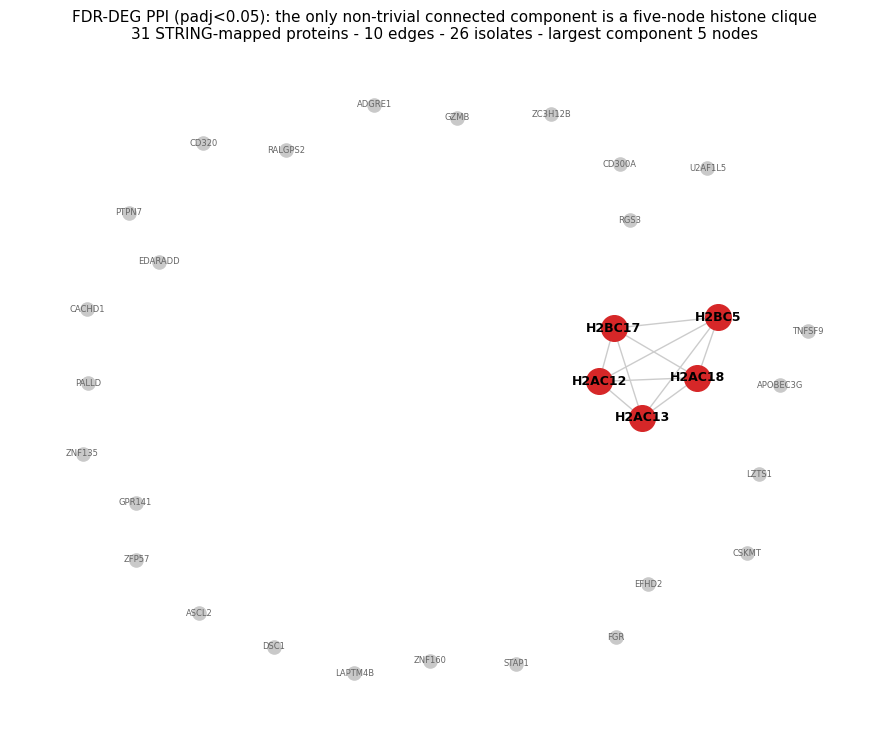

In [106]:
# FDR-DEG PPI (padj<0.05): its only non-trivial connected component is a five-node histone clique; the isolates are
# STRING-mapped DEGs with no physical edge at score>=400.
pos = nx.spring_layout(G_fdr, seed=42, k=0.7)
_conn = [n for n in G_fdr if G_fdr.degree(n) > 0]; _iso = [n for n in G_fdr if G_fdr.degree(n) == 0]
fig, ax = plt.subplots(figsize=(9, 7.5))
nx.draw_networkx_edges(G_fdr, pos, edge_color='0.8', width=1.0, ax=ax)
nx.draw_networkx_nodes(G_fdr, pos, nodelist=_iso,  node_color='#c9c9c9', node_size=90, ax=ax)
nx.draw_networkx_nodes(G_fdr, pos, nodelist=_conn, node_color=[plt.cm.tab10(3)], node_size=340, ax=ax)
nx.draw_networkx_labels(G_fdr, pos, labels={n: n for n in _iso},  font_size=6, font_color='#666666', ax=ax)
nx.draw_networkx_labels(G_fdr, pos, labels={n: n for n in _conn}, font_size=9, font_weight='bold', ax=ax)
ax.set_title('FDR-DEG PPI (padj<0.05): the only non-trivial connected component is a five-node histone clique\n'
             f'{G_fdr.number_of_nodes()} STRING-mapped proteins - {G_fdr.number_of_edges()} edges - {len(_iso)} isolates - '
             f'largest component {max((len(c) for c in nx.connected_components(G_fdr)), default=0)} nodes', fontsize=11)
ax.axis('off'); ax.margins(0.10); plt.tight_layout()
plt.savefig(NET/'ppi_fdr_deg_network.png', dpi=150, bbox_inches='tight'); plt.show()

### PPI construction sensitivity - paper-motivated FDR < 0.10

The inspiring paper (Kim et al.) constructed its PPI from significant protein-coding genes at an FDR
cutoff of 0.10. As a PPI-specific sensitivity check, the STRING physical network is rebuilt from the
protein-coding genes at `padj < 0.10` and compared with the FDR-DEG PPI. The FDR DEA
threshold remains FDR < 0.05; these FDR < 0.10 genes are **not** treated as FDR-defined DEGs. The FDR-10% PPI is itself sparse
and fragmented, with a largest connected component still well below a 10-15-node disease module, so it
does not provide a larger connected module; the network-proximity and top-node analyses therefore
continue to use the Topology PPI (betweenness-derived disease module).

In [107]:
# --- PPI construction sensitivity: paper-motivated FDR<0.10 protein-coding gene set (not FDR-defined DEGs) ---
deg010_pc = sorted(set(res.loc[(res['padj'] < 0.10) & (res['biotype'] == 'protein_coding'),
                               'symbol'].dropna().astype(str)))
edges010_csv = NET / 'string_edges_fdr010.tsv'
if edges010_csv.exists() and edges010_csv.stat().st_size > 50:
    edges010 = pd.read_csv(edges010_csv, sep='\t')
else:
    edges010 = string_network(deg010_pc, required_score=400, net_type='physical')
    edges010.to_csv(edges010_csv, sep='\t', index=False)
pref010 = string_ids(deg010_pc)
G010 = nx.Graph(); G010.add_nodes_from(sorted(set(pref010.values())))
for _, e in edges010.iterrows():
    G010.add_edge(e['preferredName_A'], e['preferredName_B'], weight=float(e['score']))
_lcc = (lambda g: len(max(nx.connected_components(g), key=len)) if g.number_of_nodes() else 0)
ppi_thr_sens = pd.DataFrame([
    {'threshold': 'FDR<0.05 (FDR-DEG PPI)', 'eligible_pc_genes': len(fdr_degs_pc),
     'string_mapped_nodes': G_fdr.number_of_nodes(), 'interacting_nodes': len([n for n in G_fdr if G_fdr.degree(n) > 0]),
     'edges': G_fdr.number_of_edges(), 'components': nx.number_connected_components(G_fdr), 'LCC_nodes': _lcc(G_fdr)},
    {'threshold': 'FDR<0.10 (paper-motivated sensitivity)', 'eligible_pc_genes': len(deg010_pc),
     'string_mapped_nodes': G010.number_of_nodes(), 'interacting_nodes': len([n for n in G010 if G010.degree(n) > 0]),
     'edges': G010.number_of_edges(), 'components': nx.number_connected_components(G010), 'LCC_nodes': _lcc(G010)},
])
ppi_thr_sens.to_csv(NET / 'ppi_fdr_threshold_sensitivity.csv', index=False)
print('PPI DEG-threshold sensitivity (protein-coding; STRING physical, score>=400):')
print('The FDR-DEG PPI stays at FDR<0.05; the FDR-10% PPI is a paper-motivated sensitivity view only.')
ppi_thr_sens

PPI DEG-threshold sensitivity (protein-coding; STRING physical, score>=400):
The FDR-DEG PPI stays at FDR<0.05; the FDR-10% PPI is a paper-motivated sensitivity view only.


,threshold,eligible_pc_genes,string_mapped_nodes,interacting_nodes,edges,components,LCC_nodes
0,FDR<0.05 (FDR-DEG PPI),33,31,5,10,27,5
1,FDR<0.10 (paper-motivated sensitivity),53,51,10,17,44,6


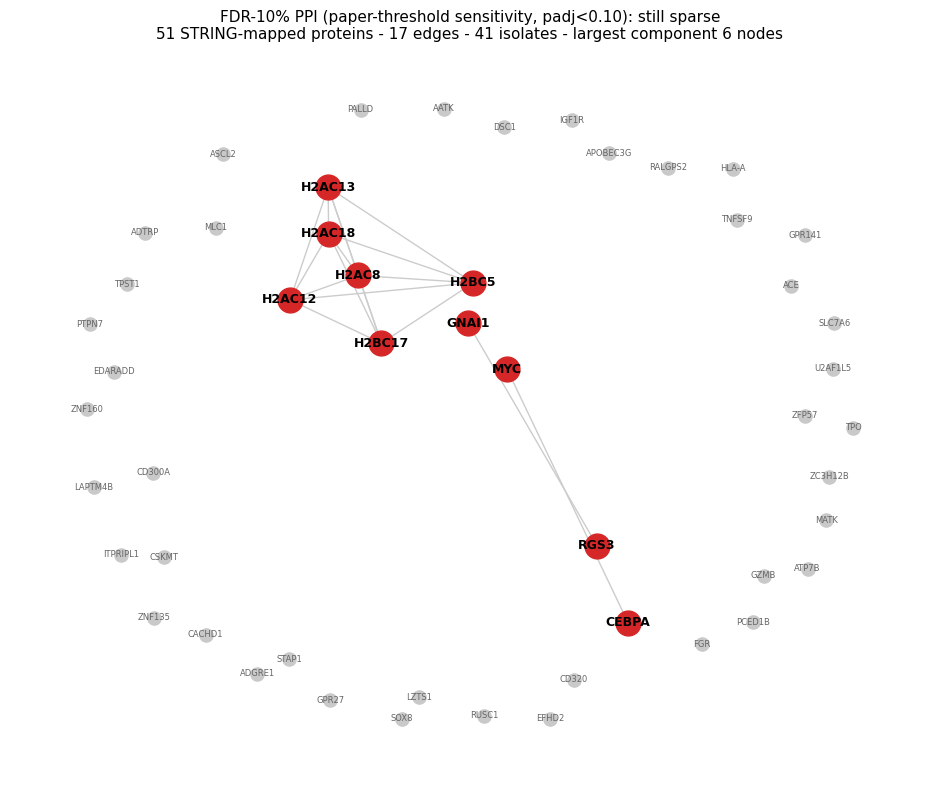

In [108]:
# FDR-10% PPI (paper threshold, padj<0.10): connected components and isolates at the paper's DEG cut-off.
pos = nx.spring_layout(G010, seed=42, k=0.75)
_iso  = [n for n in G010 if G010.degree(n) == 0]
_conn = [n for n in G010 if G010.degree(n) > 0]
fig, ax = plt.subplots(figsize=(9.5, 8))
nx.draw_networkx_edges(G010, pos, edge_color='0.8', width=1.0, ax=ax)
nx.draw_networkx_nodes(G010, pos, nodelist=_iso,  node_color='#c9c9c9', node_size=90, ax=ax)
nx.draw_networkx_nodes(G010, pos, nodelist=_conn, node_color=[plt.cm.tab10(3)], node_size=320, ax=ax)
nx.draw_networkx_labels(G010, pos, labels={n: n for n in _iso},  font_size=6, font_color='#666666', ax=ax)
nx.draw_networkx_labels(G010, pos, labels={n: n for n in _conn}, font_size=9, font_weight='bold', ax=ax)
_lcc = max((len(c) for c in nx.connected_components(G010)), default=0)
ax.set_title('FDR-10% PPI (paper-threshold sensitivity, padj<0.10): still sparse\n'
             f'{G010.number_of_nodes()} STRING-mapped proteins - {G010.number_of_edges()} edges - {len(_iso)} isolates - '
             f'largest component {_lcc} nodes', fontsize=11)
ax.axis('off'); ax.margins(0.10); plt.tight_layout()
plt.savefig(NET/'ppi_fdr10_network.png', dpi=150, bbox_inches='tight'); plt.show()

In [109]:
# --- Build the Topology PPI (betweenness-derived disease-module basis; largest connected component) ---
# Insert nodes and edges in sorted order so Louvain community detection is deterministic.
G0 = nx.Graph()
for _, e in edges.iterrows():
    G0.add_edge(e['preferredName_A'], e['preferredName_B'], weight=float(e['score']))
G_topology = nx.Graph()
if G0.number_of_nodes():
    lcc = max(nx.connected_components(G0), key=len)
    G_topology.add_nodes_from(sorted(lcc))
    G_topology.add_edges_from(sorted(tuple(sorted((u, v))) for u, v in G0.subgraph(lcc).edges()))
    for u, v in G_topology.edges():
        G_topology[u][v]['weight'] = float(G0[u][v]['weight'])
print('Topology PPI (LCC):', G_topology.number_of_nodes(), 'nodes,', G_topology.number_of_edges(), 'edges')
nx.write_graphml(G_topology, NET/'topology_ppi.graphml')

Topology PPI (LCC): 39 nodes, 55 edges


In [110]:
# --- Topology PPI construction sensitivity: STRING score>=400 vs >=700, before LCC selection ---
def topology_ppi_stats(min_score, edges_df):
    g = nx.Graph()
    for _, r in edges_df.iterrows(): g.add_edge(r['preferredName_A'], r['preferredName_B'])
    comps = list(nx.connected_components(g)) if g.number_of_nodes() else []
    return {'string_score': f'>={min_score}', 'interacting_nodes': g.number_of_nodes(), 'edges': g.number_of_edges(),
            'components': len(comps), 'LCC_nodes': max((len(c) for c in comps), default=0)}
edges_hi_csv = NET / 'string_edges_hiconf700.tsv'
if edges_hi_csv.exists() and edges_hi_csv.stat().st_size > 200:
    edges_hi = pd.read_csv(edges_hi_csv, sep='\t')
else:
    edges_hi = string_network(ppi_input_genes, required_score=700, net_type='physical'); edges_hi.to_csv(edges_hi_csv, sep='\t', index=False)
string_sensitivity = pd.DataFrame([topology_ppi_stats(400, edges), topology_ppi_stats(700, edges_hi)])
string_sensitivity.to_csv(NET/'string_confidence_sensitivity.csv', index=False)
print('Topology PPI construction sensitivity (interacting nodes before LCC selection; score>=400 vs >=700):')
string_sensitivity

Topology PPI construction sensitivity (interacting nodes before LCC selection; score>=400 vs >=700):


,string_score,interacting_nodes,edges,components,LCC_nodes
0,>=400,95,198,16,39
1,>=700,60,104,16,20


In [111]:
# --- Betweenness-derived disease module: rank the Topology PPI nodes by betweenness centrality ---
# Betweenness identifies bottlenecks - nodes on a large fraction of shortest paths, bridging functional
# modules. Degree, closeness and eigenvector centrality are reported alongside as complementary views of
# local connectivity, reachability and global influence. 
degree      = dict(G_topology.degree())
betweenness = nx.betweenness_centrality(G_topology, weight=None)
closeness   = nx.closeness_centrality(G_topology)
try:
    eigenvector = nx.eigenvector_centrality(G_topology, max_iter=1000)
except Exception:
    eigenvector = {n: np.nan for n in G_topology}
cent = pd.DataFrame({'betweenness': betweenness, 'degree': degree,
                     'closeness': closeness, 'eigenvector': eigenvector})
cent = cent.sort_values(['betweenness', 'degree'], ascending=False)
cent.to_csv(NET/'topology_ppi_centrality.csv')
TOPK = 15
betweenness_disease_module = cent.head(TOPK).index.tolist()   # betweenness-derived disease module S = top-15 by betweenness
print(f'Betweenness-derived disease module = top {TOPK} nodes by betweenness centrality (degree tie-break):')
print(' ', betweenness_disease_module)
cent.head(TOPK)

Betweenness-derived disease module = top 15 nodes by betweenness centrality (degree tie-break):
  ['FCGR3A', 'LYN', 'PLCG2', 'CXCR1', 'FASLG', 'TNF', 'ITGA2', 'NCAM1', 'CXCR2', 'GNAI1', 'LAMB3', 'LILRA4', 'SPTBN5', 'CX3CR1', 'MATK']


,betweenness,degree,closeness,eigenvector
FCGR3A,0.597440,5,0.365385,0.132785
LYN,0.589616,8,0.358491,0.022166
PLCG2,0.573969,7,0.380000,0.057165
CXCR1,0.374111,7,0.308943,0.462730
FASLG,0.205548,3,0.287879,0.005569
TNF,0.155050,5,0.237500,0.001772
ITGA2,0.152205,3,0.277372,0.005186
NCAM1,0.152205,3,0.281481,0.031059
CXCR2,0.103367,7,0.253333,0.416985
GNAI1,0.053106,3,0.207650,0.181241


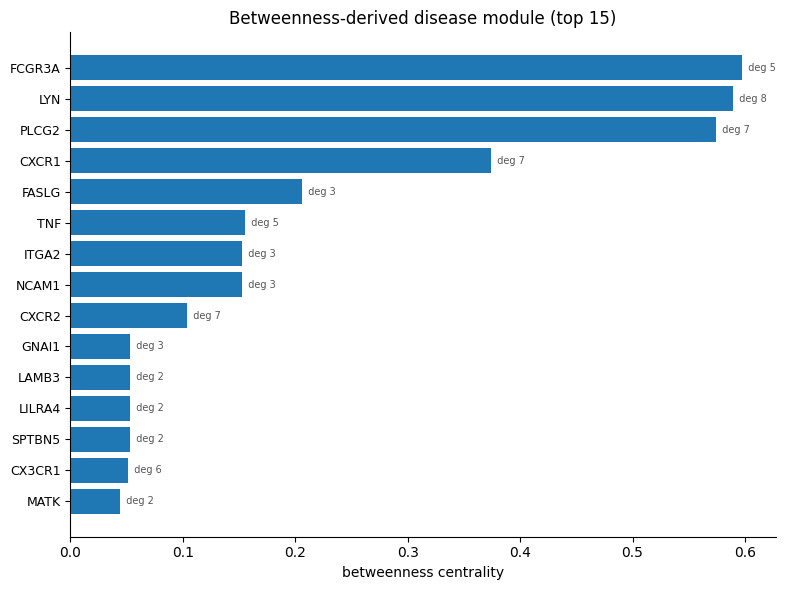

In [112]:
# Betweenness-derived disease module (top 15) ranked by betweenness centrality; degree annotated.
_top = cent.head(TOPK).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(_top)), _top['betweenness'], color=plt.cm.tab10(0))
for _i, _deg in enumerate(_top['degree']):
    ax.text(_top['betweenness'].iloc[_i], _i, f'  deg {int(_deg)}', va='center', fontsize=7, color='#555555')
ax.set_yticks(range(len(_top))); ax.set_yticklabels(_top.index, fontsize=9)
ax.set_xlabel('betweenness centrality'); ax.set_title('Betweenness-derived disease module (top 15)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig(NET/'disease_module_betweenness.png', dpi=150, bbox_inches='tight'); plt.show()

In [113]:
# --- Topology PPI: Louvain community detection (modularity-based) ---
import networkx.algorithms.community as nxcom

def label_map(comms):
    m = {}
    for i, c in enumerate(comms):
        for n in c: m[n] = i
    return m

if G_topology.number_of_edges() == 0:
    raise RuntimeError('PPI graph has no edges - relax PPI_P/PPI_LFC in the STRING cell above.')

# Louvain (greedy modularity optimisation)
louvain = nxcom.louvain_communities(G_topology, weight='weight', seed=42)
partition = label_map(louvain)
modularity = nxcom.modularity(G_topology, louvain, weight='weight')
print(f'Topology PPI - Louvain communities: {len(louvain)}, modularity={modularity:.3f}')
COMM_COLORS = [plt.cm.tab10(i) for i in (0, 1, 2, 3, 4, 6, 8, 9)]  # qualitative palette (no brown/grey)

nx.set_node_attributes(G_topology, partition, 'community')
pd.Series(partition, name='community').sort_index().to_csv(NET/'topology_ppi_communities.csv') 

Topology PPI - Louvain communities: 6, modularity=0.625


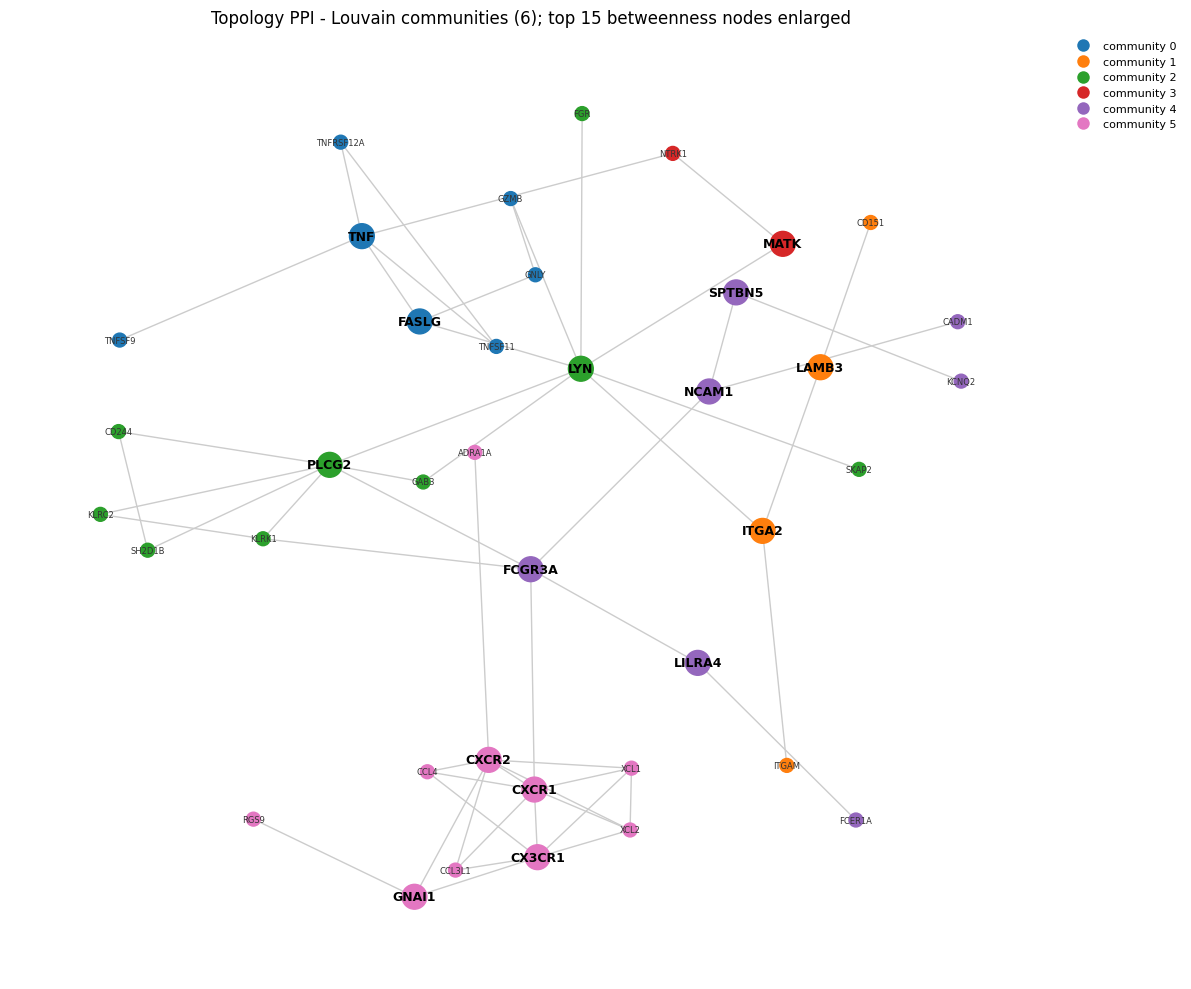

In [114]:
# Topology PPI coloured by Louvain community; the top-betweenness disease-module nodes are enlarged.
from matplotlib.lines import Line2D
pos = nx.spring_layout(G_topology, seed=42, k=0.5)
ncomm = len(set(partition.values()))
_minor = [n for n in G_topology.nodes() if n not in betweenness_disease_module]
fig, ax = plt.subplots(figsize=(12, 10))
nx.draw_networkx_edges(G_topology, pos, edge_color='0.8', width=1.0, ax=ax)
nx.draw_networkx_nodes(G_topology, pos, node_color=[COMM_COLORS[partition[n] % len(COMM_COLORS)] for n in G_topology.nodes()],
                       node_size=[320 if n in betweenness_disease_module else 100 for n in G_topology.nodes()], ax=ax)
nx.draw_networkx_labels(G_topology, pos, labels={n: n for n in _minor}, font_size=6, font_color='#333333', ax=ax)
nx.draw_networkx_labels(G_topology, pos, labels={n: n for n in betweenness_disease_module}, font_size=9, font_weight='bold', ax=ax)
ax.set_title(f'Topology PPI - Louvain communities ({ncomm}); top {TOPK} betweenness nodes enlarged'); ax.axis('off')
_leg = [Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=COMM_COLORS[c % len(COMM_COLORS)],
               markeredgecolor='none', markersize=9, label=f'community {c}') for c in sorted(set(partition.values()))]
ax.legend(handles=_leg, loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(NET/'ppi_communities.png', dpi=150, bbox_inches='tight'); plt.show()

### Louvain community detection

**Louvain** partitions the Topology PPI: it greedily optimises modularity. The table below summarises the modules (one row per community), derived from
the existing `partition`, `cent` and `G_topology`; the node-level gene-to-community mapping is in
`results/network/topology_ppi_communities.csv`.

In [115]:
# --- Compact Louvain community summary (from existing partition / cent / G_topology; no recomputation) ---
_members = {}
for _n, _c in partition.items():
    _members.setdefault(_c, []).append(_n)
_rows = []
for _c in sorted(_members):
    mem = _members[_c]
    n_int = sum(1 for u, v in G_topology.edges() if partition.get(u) == _c and partition.get(v) == _c)
    present = [m for m in mem if m in cent.index]
    ranked = cent.loc[present].sort_values('betweenness', ascending=False).index.tolist()
    ranked = ranked + [m for m in mem if m not in ranked]      # keep any node lacking a centrality row
    _rows.append({'community': _c, 'n_nodes': len(mem), 'n_internal_edges': n_int,
                  'top_central_nodes': ', '.join(ranked[:3]),
                  'representative_genes': ', '.join(ranked[:5])})
community_summary = pd.DataFrame(_rows).sort_values('community').reset_index(drop=True)
community_summary.to_csv(NET / 'community_summary.csv', index=False)
print(f'Louvain communities: {len(community_summary)} (full node-level mapping in topology_ppi_communities.csv)')
community_summary

Louvain communities: 6 (full node-level mapping in topology_ppi_communities.csv)


,community,n_nodes,n_internal_edges,top_central_nodes,representative_genes
0,0,7,7,"FASLG, TNF, GZMB","FASLG, TNF, GZMB, GNLY, TNFSF11"
1,1,4,3,"ITGA2, LAMB3, ITGAM","ITGA2, LAMB3, ITGAM, CD151"
2,2,9,11,"LYN, PLCG2, KLRK1","LYN, PLCG2, KLRK1, KLRC2, GAB3"
3,3,2,1,"MATK, NTRK1","MATK, NTRK1"
4,4,7,6,"FCGR3A, NCAM1, LILRA4","FCGR3A, NCAM1, LILRA4, SPTBN5, CADM1"
5,5,10,19,"CXCR1, CXCR2, GNAI1","CXCR1, CXCR2, GNAI1, CX3CR1, CCL3L1"


In [116]:
# --- Network-conditioned enrichment: what distinguishes each Louvain community from the rest of the PPI ---
# Background = the nodes of the analysed Topology PPI (the genes that could have entered a community), so
# the test asks what is over-represented within a community relative to the whole network.
comm_members = {}
for n, c in partition.items():
    comm_members.setdefault(c, []).append(n)
net_background = sorted(G_topology.nodes())
comm_rows = []
for c, members in sorted(comm_members.items()):
    if len(members) < 5:
        continue
    try:
        e = gp.enrichr(gene_list=members, gene_sets=GENE_SETS,
                       organism='human', background=net_background, outdir=None).results
        sig = e[e['Adjusted P-value'] < 0.05].sort_values('Adjusted P-value')
        print(f'\n=== Community {c} (n={len(members)}) - {len(sig)} terms at FDR<0.05 ===')
        if sig.empty:
            print('No term reaches FDR < 0.05.')
        else:
            print(sig.head(3)[['Term', 'Adjusted P-value']].to_string(index=False))
        for _, r in sig.head(4).iterrows():
            ov = int(str(r['Overlap']).split('/')[0]) if 'Overlap' in e.columns else len([x for x in str(r['Genes']).split(';') if x])
            comm_rows.append({'community': c, 'Term': r['Term'], 'fdr': r['Adjusted P-value'], 'overlap_n': ov})
    except Exception as ex:
        print('Community', c, 'enrichment failed:', ex)
community_ora = pd.DataFrame(comm_rows)
community_ora.to_csv(ENRICH / 'community_ora_summary.csv', index=False)  # top 4 FDR<0.05 terms per community (summary)
_skipped = [c for c, m in sorted(comm_members.items()) if len(m) < 5]
if _skipped:
    print(f'Communities not tested (<5 nodes, too small for meaningful ORA): {_skipped}')


=== Community 0 (n=7) - 1 terms at FDR<0.05 ===
                                           Term  Adjusted P-value
TNFR2 Non-Canonical NF-kB Pathway R-HSA-5668541          0.001568

=== Community 2 (n=9) - 0 terms at FDR<0.05 ===
No term reaches FDR < 0.05.

=== Community 4 (n=7) - 0 terms at FDR<0.05 ===
No term reaches FDR < 0.05.

=== Community 5 (n=10) - 26 terms at FDR<0.05 ===
                                             Term  Adjusted P-value
                   Signaling By GPCR R-HSA-372790          0.000002
                 GPCR Ligand Binding R-HSA-500792          0.000008
Class A/1 (Rhodopsin-like Receptors) R-HSA-373076          0.000008
Communities not tested (<5 nodes, too small for meaningful ORA): [1, 3]


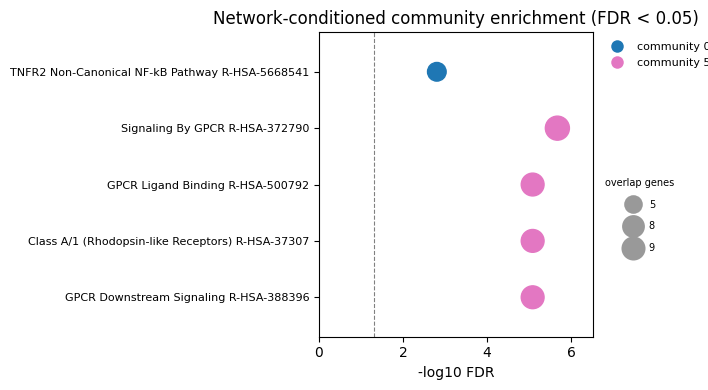

In [117]:
# Dotplot of the network-conditioned community enrichment: terms at FDR<0.05, coloured by community.
from matplotlib.lines import Line2D
if community_ora.empty:
    print('No community reaches FDR < 0.05')
else:
    _c = community_ora.iloc[::-1].reset_index(drop=True)
    _c['-log10FDR'] = -np.log10(_c['fdr'].clip(lower=1e-300))
    _comms = sorted(_c['community'].unique())
    _cm = {cc: COMM_COLORS[cc % len(COMM_COLORS)] for cc in _comms}
    fig, ax = plt.subplots(figsize=(9, max(0.5*len(_c) + 1.5, 3)))
    ax.axvline(-np.log10(0.05), ls='--', lw=0.8, color='grey')
    ax.scatter(_c['-log10FDR'], range(len(_c)), s=_c['overlap_n']*30 + 30, c=[_cm[c] for c in _c['community']], zorder=3)
    ax.set_yticks(range(len(_c))); ax.set_yticklabels(_c['Term'].str.slice(0, 48), fontsize=8)
    ax.set_ylim(-0.7, len(_c) - 0.3); ax.set_xlim(0, _c['-log10FDR'].max() * 1.15)
    ax.set_xlabel('-log10 FDR'); ax.set_title('Network-conditioned community enrichment (FDR < 0.05)')
    _h = [Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=_cm[c], markeredgecolor='none', markersize=9, label=f'community {c}') for c in _comms]
    _l1 = ax.legend(handles=_h, loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False); ax.add_artist(_l1)
    _sref = sorted({int(_c['overlap_n'].min()), int(round(_c['overlap_n'].median())), int(_c['overlap_n'].max())})
    _sh = [Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='0.6', markeredgecolor='none', markersize=np.sqrt(gc*30 + 30), label=str(gc)) for gc in _sref]
    ax.legend(handles=_sh, title='overlap genes', loc='upper left', bbox_to_anchor=(1.01, 0.55), labelspacing=1.2, handletextpad=0.6, frameon=False, fontsize=7, title_fontsize=7)
    plt.tight_layout(rect=[0, 0, 0.78, 1]); plt.savefig(ENRICH/'community_ora_dotplot.png', dpi=150, bbox_inches='tight'); plt.show()

## Part 2 - Task 2: Drug targets and drug-disease proximity

Drug targets for the three approved MS drugs were manually curated from **DrugBank** and mapped to gene
symbols for the network analysis.

| Drug | Active molecule | DrugBank ID | Targets (gene symbols) |
|---|---|---|---|
| Betaferon | interferon beta-1b | DB00068 | IFNAR1, IFNAR2 |
| Tecfidera | dimethyl fumarate | DB08908 | KEAP1, RELA |
| Ocrevus | ocrelizumab | DB11988 | MS4A1 |

The disease module, its centrality ranking and its Louvain communities were all defined on the **Topology
PPI**, so the assignment's instruction to extend the PPI with the drug targets is followed on that same
network. The drug-disease relationship is then read at increasing levels of formality:

1. **Drug-extended Topology PPI** - the drug targets are added to the Topology PPI through their real
   STRING physical edges and each target's shortest-path distance to the betweenness disease module
   (top-15) is read directly on this expression-derived network.
2. **Community reach** - on the Reference Physical Interactome, each target's nearest disease-module node and
   the Louvain community of that node are reported.
3. **Guney closest-distance proximity** - the formal d_c between each drug's target set and the disease
   module on the Reference Physical Interactome, standardised against a degree-matched null (z-score),
   with sensitivity to disease-module size (top-10 vs top-15) and STRING confidence (>=400 vs >=700).

The sparse **FDR-connected core** is mapped by the same drugs only as a diagnostic of the FDR-network
sparsity, not as a competing disease module. A proximity z-score below -2 would mark a drug closer to the
module than chance; none of the drugs reaches that threshold, so the analysis reports the direction of the
effect rather than a significant proximity.

In [118]:
# --- Drug targets from DrugBank (mapped to gene symbols for the network analysis) ---
drugbank_targets = pd.DataFrame([
    ['Betaferon','DB00068','Interferon alpha/beta receptor 1','IFNAR1'],
    ['Betaferon','DB00068','Interferon alpha/beta receptor 2','IFNAR2'],
    ['Tecfidera','DB08908','Kelch-like ECH-associated protein 1','KEAP1'],
    ['Tecfidera','DB08908','Transcription factor p65 (NF-kappa-B p65)','RELA'],
    ['Ocrevus','DB11988','B-lymphocyte antigen CD20','MS4A1'],
], columns=['drug_name','drugbank_id','target_name','gene_symbol'])
drugbank_targets.to_csv(NET/'drug_targets_drugbank.csv', index=False)
drug_targets = {d: sorted(set(drugbank_targets.loc[drugbank_targets['drug_name']==d,'gene_symbol']))
                for d in drugbank_targets['drug_name'].unique()}
print('DrugBank target sets used for the network analysis:', drug_targets)
drugbank_targets

DrugBank target sets used for the network analysis: {'Betaferon': ['IFNAR1', 'IFNAR2'], 'Tecfidera': ['KEAP1', 'RELA'], 'Ocrevus': ['MS4A1']}


,drug_name,drugbank_id,target_name,gene_symbol
0,Betaferon,DB00068,Interferon alpha/beta receptor 1,IFNAR1
1,Betaferon,DB00068,Interferon alpha/beta receptor 2,IFNAR2
2,Tecfidera,DB08908,Kelch-like ECH-associated protein 1,KEAP1
3,Tecfidera,DB08908,Transcription factor p65 (NF-kappa-B p65),RELA
4,Ocrevus,DB11988,B-lymphocyte antigen CD20,MS4A1


In [119]:
# --- Part 2 - Drug-extended Topology PPI: extend the full Topology PPI with the drug targets ---
# Centrality, the top-15 disease module and the Louvain communities are all defined on the Topology PPI,
# so the drug targets are added to THAT network (assignment: extend the PPI with the drug targets). STRING
# physical edges (score>=400) are queried for the union of the Topology PPI nodes and the targets; each
# target keeps only its STRING physical edges (score>=400) to Topology PPI genes and to other targets - no artificial
# connectors are added, and the Topology PPI topology itself is left unchanged.
drug_target_all = sorted({t for T in drug_targets.values() for t in T})
ext_csv = NET / 'string_edges_drug_extended.tsv'
if ext_csv.exists() and ext_csv.stat().st_size > 50:
    edges_ext = pd.read_csv(ext_csv, sep='\t')
else:
    edges_ext = string_network(sorted(set(G_topology.nodes()) | set(drug_target_all)), required_score=400, net_type='physical')
    edges_ext.to_csv(ext_csv, sep='\t', index=False)
G_drug_extended = nx.Graph()
G_drug_extended.add_nodes_from(sorted(G_topology.nodes()))
for u, v in sorted(tuple(sorted((x, y))) for x, y in G_topology.edges()):
    G_drug_extended.add_edge(u, v, weight=float(G_topology[u][v]['weight']))
for _, e in edges_ext.iterrows():
    a, b = e['preferredName_A'], e['preferredName_B']
    if (a in drug_target_all or b in drug_target_all) and not G_drug_extended.has_edge(a, b):
        G_drug_extended.add_edge(a, b, weight=float(e['score']))
nx.set_node_attributes(G_drug_extended, {n: ('drug_target' if n in drug_target_all
                               else 'disease_module' if n in betweenness_disease_module else 'topology_ppi') for n in G_drug_extended}, 'role')
nx.write_graphml(G_drug_extended, NET / 'drug_extended_topology_ppi.graphml')

# Local drug-to-module geometry: shortest-path distance from each target to the nearest top-15 node.
_rows = []
for drug, T in drug_targets.items():
    for t in T:
        if t not in G_drug_extended or G_drug_extended.degree(t) == 0:
            _rows.append({'drug': drug, 'target': t, 'attached_to': '-', 'distance_to_module': np.nan,
                          'nearest_disease_node': None, 'status': 'disconnected'}); continue
        sp = nx.single_source_shortest_path_length(G_drug_extended, t)
        near = sorted((sp[m], m) for m in betweenness_disease_module if m in sp)
        _rows.append({'drug': drug, 'target': t, 'attached_to': ';'.join(sorted(G_drug_extended.neighbors(t))),
                      'distance_to_module': (int(near[0][0]) if near else np.nan),
                      'nearest_disease_node': (near[0][1] if near else None),
                      'status': ('reached' if near else 'no path to module')})
drug_module_geometry = pd.DataFrame(_rows)
drug_module_geometry.to_csv(NET / 'drug_target_neighbors_distance.csv', index=False)
_n_edge = sum(1 for t in drug_target_all if t in G_drug_extended and G_drug_extended.degree(t) > 0)
_n_reach = int(drug_module_geometry['distance_to_module'].notna().sum())
print(f'Drug-extended Topology PPI: {G_drug_extended.number_of_nodes()} nodes, {G_drug_extended.number_of_edges()} edges.')
print(f'Drug targets with a physical edge: {_n_edge}/{len(drug_target_all)}; targets reaching the disease '
      f'module within this expression-derived network: {_n_reach}/{len(drug_target_all)}.')

Drug-extended Topology PPI: 44 nodes, 59 edges.
Drug targets with a physical edge: 5/5; targets reaching the disease module within this expression-derived network: 3/5.


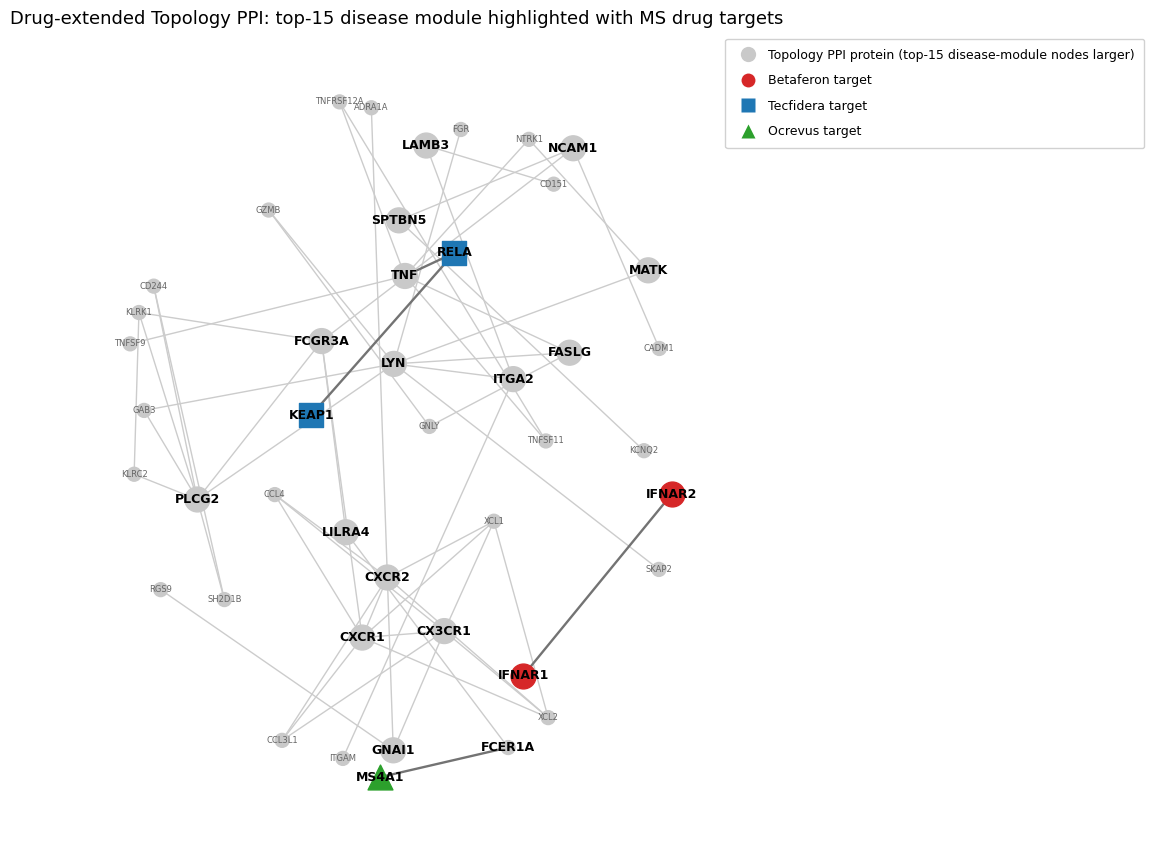

In [120]:
# Drug-extended Topology PPI: the full Topology PPI with the DrugBank targets added through their real
# STRING physical edges; the top-15 disease module is highlighted (larger nodes).
from matplotlib.lines import Line2D
DRUG_STYLE = {'Betaferon': (plt.cm.tab10(3), 'o'), 'Tecfidera': (plt.cm.tab10(0), 's'), 'Ocrevus': (plt.cm.tab10(2), '^')}
pos = nx.spring_layout(G_drug_extended, seed=42, k=0.9)
_topology_nodes = [n for n in G_drug_extended if n not in drug_target_all]
_topology_edges = [(u, v) for u, v in G_drug_extended.edges() if u not in drug_target_all and v not in drug_target_all]
_att_e = [(u, v) for u, v in G_drug_extended.edges() if u in drug_target_all or v in drug_target_all]
fig, ax = plt.subplots(figsize=(11, 8.6))
nx.draw_networkx_edges(G_drug_extended, pos, edgelist=_topology_edges, edge_color='0.8', width=1.0, ax=ax)
nx.draw_networkx_edges(G_drug_extended, pos, edgelist=_att_e, edge_color='0.45', width=1.7, ax=ax)
nx.draw_networkx_nodes(G_drug_extended, pos, nodelist=_topology_nodes, node_color='#c9c9c9',
                       node_size=[320 if n in betweenness_disease_module else 100 for n in _topology_nodes], ax=ax)
for _drug, (_col, _mk) in DRUG_STYLE.items():
    nx.draw_networkx_nodes(G_drug_extended, pos, nodelist=[t for t in drug_targets[_drug] if t in G_drug_extended],
                           node_color=[_col], node_shape=_mk, node_size=320, ax=ax)
_key = set(betweenness_disease_module) | set(drug_target_all) | {'TNF', 'FCER1A'}
nx.draw_networkx_labels(G_drug_extended, pos, labels={n: n for n in G_drug_extended if n not in _key}, font_size=6, font_color='#666666', ax=ax)
nx.draw_networkx_labels(G_drug_extended, pos, labels={n: n for n in G_drug_extended if n in _key}, font_size=9, font_weight='bold', ax=ax)
_leg = [Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='#c9c9c9', markeredgecolor='none', markersize=11, label='Topology PPI protein (top-15 disease-module nodes larger)')]
for _drug, (_col, _mk) in DRUG_STYLE.items():
    _leg.append(Line2D([0], [0], marker=_mk, linestyle='none', markerfacecolor=_col, markeredgecolor='none', markersize=10, label=f'{_drug} target'))
ax.legend(handles=_leg, fontsize=9, loc='upper left', bbox_to_anchor=(1.0, 1.0), labelspacing=1.0, handletextpad=0.6, borderpad=0.8, framealpha=0.9)
ax.set_title('Drug-extended Topology PPI: top-15 disease module highlighted with MS drug targets', fontsize=13)
ax.axis('off'); plt.tight_layout()
plt.savefig(NET/'drug_extended_topology_ppi.png', dpi=150, bbox_inches='tight'); plt.show()

The **Drug-extended Topology PPI** adds the DrugBank targets to the full Topology PPI through
their STRING physical interactions (score>=400) only (no artificial connectors), so the Topology PPI topology is
unchanged and the targets attach where STRING-supported physical interactions are present. Reading the local
geometry directly on this expression-derived network:

- **Tecfidera** connects into the module: **RELA is one interaction from TNF** (with KEAP1 behind RELA),
  reaching the TNF/NF-kB community through TNF.
- **Ocrevus** enters the largest component through **FCER1A** (MS4A1-FCER1A), reaching the module in two
  steps.
- **Betaferon**'s **IFNAR1/IFNAR2** form a separate dyad: in a network built only from the transcriptomic
  gene set they do not reach the disease module, because the proteins that would link interferon-receptor
  signalling to the module are not present in the selected expression-derived Topology PPI.

The Betaferon case is resolved on the Reference Physical Interactome below, where those intermediate
proteins are present.

In [121]:
# --- Local drug-to-module distances on the Drug-extended Topology PPI (compact view) ---
# Shortest-path distance from each drug target to the nearest disease-module node (top-15), measured
# within the expression-derived network. distance_to_module is NaN when unreachable; the status column
# records 'reached' / 'no path to module' / 'disconnected' (resolved on the reference interactome below).
drug_module_geometry

,drug,target,attached_to,distance_to_module,nearest_disease_node,status
0,Betaferon,IFNAR1,IFNAR2,NaN,None,no path to module
1,Betaferon,IFNAR2,IFNAR1,NaN,None,no path to module
2,Tecfidera,KEAP1,RELA,2.0,TNF,reached
3,Tecfidera,RELA,KEAP1;TNF,1.0,TNF,reached
4,Ocrevus,MS4A1,FCER1A,2.0,LILRA4,reached


In [122]:
# --- Reference Physical Interactome: a reference STRING v12.0 human physical network (independent of the DEGs) ---
# Used for the community-reach and Guney proximity analyses so distances are measured on a broader,
# study-independent interactome (human PPI maps are incomplete).
import gzip, urllib.request
_S12 = 'https://stringdb-downloads.org/download'
_links = REF / '9606.protein.physical.links.v12.0.txt.gz'
_info  = REF / '9606.protein.info.v12.0.txt.gz'
for _url, _dest in [(f'{_S12}/protein.physical.links.v12.0/9606.protein.physical.links.v12.0.txt.gz', _links),
                    (f'{_S12}/protein.info.v12.0/9606.protein.info.v12.0.txt.gz', _info)]:
    if not _dest.exists():
        print('downloading', _dest.name, '...'); urllib.request.urlretrieve(_url, _dest)
_id2sym = {}
with gzip.open(_info, 'rt', encoding='utf-8') as _fh:
    next(_fh)
    for _line in _fh:
        _p = _line.rstrip('\n').split('\t'); _id2sym[_p[0]] = _p[1]
def reference_interactome(min_score):
    Gf = nx.Graph()
    with gzip.open(_links, 'rt', encoding='utf-8') as _fh:
        next(_fh)
        for _line in _fh:
            a, b, s = _line.split()
            if int(s) >= min_score:
                sa, sb = _id2sym.get(a), _id2sym.get(b)
                if sa and sb and sa != sb: Gf.add_edge(sa, sb)
    return Gf.subgraph(max(nx.connected_components(Gf), key=len)).copy()
G_reference    = reference_interactome(400)
G_reference700 = reference_interactome(700)   # high-confidence sensitivity configuration (reused by the proximity cell)
_cov = lambda G: sum(1 for n in betweenness_disease_module if n in G)
for _g, _sc in [(G_reference, '>=400'), (G_reference700, '>=700')]:
    print(f'Reference Physical Interactome (STRING v12.0 physical, score{_sc}, LCC): '
          f'{_g.number_of_nodes()} nodes, {_g.number_of_edges()} edges, '
          f'top-15 disease-module coverage {_cov(_g)}/{len(betweenness_disease_module)}')

Reference Physical Interactome (STRING v12.0 physical, score>=400, LCC): 15640 nodes, 210570 edges, top-15 disease-module coverage 15/15
Reference Physical Interactome (STRING v12.0 physical, score>=700, LCC): 9830 nodes, 85576 edges, top-15 disease-module coverage 15/15


In [123]:
# --- Disease-drug overlap: where do the drug targets fall in the Topology PPI? ---
# Map each DrugBank drug target onto the Topology PPI (G_topology) and its Louvain communities.
rows=[]
for drug, T in drug_targets.items():
    for t in T:
        in_net = t in G_topology
        rows.append({'drug':drug,'target':t,'in_topology_ppi':in_net,
                     'community': (partition.get(t) if in_net else None),
                     'is_disease_module': t in betweenness_disease_module})
overlap = pd.DataFrame(rows)
overlap.to_csv(NET/'disease_drug_overlap.csv', index=False)
n_in = int(overlap['in_topology_ppi'].sum())
print(f'Drug targets present in the Topology PPI: {n_in} of {len(overlap)}')
overlap

Drug targets present in the Topology PPI: 0 of 5


,drug,target,in_topology_ppi,community,is_disease_module
0,Betaferon,IFNAR1,False,None,False
1,Betaferon,IFNAR2,False,None,False
2,Tecfidera,KEAP1,False,None,False
3,Tecfidera,RELA,False,None,False
4,Ocrevus,MS4A1,False,None,False


In [124]:
# --- Which communities are reached by each drug's targets (on the Reference Physical Interactome) ---
# For each mapped target, the nearest disease-module node on the Reference Physical Interactome is found
# and report the Louvain community of that node (community assignments come from the Topology PPI).
S_fix = [g for g in betweenness_disease_module if g in G_reference]
_dmaps = {s: nx.single_source_shortest_path_length(G_reference, s) for s in S_fix}   # dist from each module node
# short label per community: its 3 highest-centrality member genes
_lab = {}
for _cm in sorted(set(partition.values())):
    _members = [n for n,cc in partition.items() if cc==_cm and n in cent.index]
    _lab[_cm] = ', '.join(cent.loc[_members,'betweenness'].sort_values(ascending=False).head(3).index)
rows=[]
for drug, T in drug_targets.items():
    for t in T:
        if t not in G_reference:
            rows.append({'drug':drug,'target':t,'nearest_disease_node':None,'distance_to_module':None,
                         'disease_community':None,'community_top_genes':None}); continue
        dist, nearest = min(((_dmaps[s].get(t, np.inf), s) for s in S_fix), key=lambda x: x[0])
        cm = partition.get(nearest)
        rows.append({'drug':drug,'target':t,'nearest_disease_node':nearest,
                     'distance_to_module':(int(dist) if np.isfinite(dist) else None),
                     'disease_community':cm,'community_top_genes':_lab.get(cm,'')})
drug_comm = pd.DataFrame(rows); drug_comm.to_csv(NET/'drug_target_communities.csv', index=False)
print('Nearest disease-module node and its community, per drug target (Reference Physical Interactome):')
# which communities each drug reaches most
print('\nNearest disease-module community per drug (topological association, not target membership):')
for drug in drug_targets:
    cs = drug_comm.loc[(drug_comm.drug==drug) & drug_comm.disease_community.notna(),'disease_community']
    print(f'  {drug}: ' + (', '.join(f'community {int(c)}' for c in sorted(cs.unique())) if len(cs) else 'no mapped target reaches the module'))

# Exploratory shortest-path context network: DrugBank targets + disease-module nodes + the shortest-path
# connector proteins linking them on the Reference Physical Interactome. Connectors are introduced by the reference
# interactome and are not part of the top-15 disease module or the DrugBank target sets.
Gpaths = nx.Graph(); role={}
for g in S_fix: role[g]='betweenness_disease_module'
for drug,T in drug_targets.items():
    for t in T:
        if t not in G_reference: continue
        role[t]='drug_target'
        _,nearest = min(((_dmaps[s].get(t,np.inf), s) for s in S_fix), key=lambda x:x[0])
        try:
            path = nx.shortest_path(G_reference, t, nearest)
            nx.add_path(Gpaths, path)
            for n in path: role.setdefault(n,'connector')
        except nx.NetworkXNoPath:
            Gpaths.add_node(t)
for n in Gpaths.nodes(): Gpaths.nodes[n]['role']=role.get(n,'connector')
nx.write_graphml(Gpaths, NET/'drug_target_paths.graphml')
_connectors = sorted(n for n in Gpaths.nodes() if Gpaths.nodes[n].get('role') == 'connector')
print(f'\nExploratory shortest-path context network (drug_target_paths.graphml): {Gpaths.number_of_nodes()} nodes, '
      f'{Gpaths.number_of_edges()} edges.')
print(f'Connector nodes (from the reference interactome, not in the top-15 disease module or the DrugBank target sets): {_connectors}')
drug_comm

Nearest disease-module node and its community, per drug target (Reference Physical Interactome):

Nearest disease-module community per drug (topological association, not target membership):
  Betaferon: community 2, community 4
  Tecfidera: community 0, community 4
  Ocrevus: community 4

Exploratory shortest-path context network (drug_target_paths.graphml): 12 nodes, 9 edges.
Connector nodes (from the reference interactome, not in the top-15 disease module or the DrugBank target sets): ['CD19', 'EGFR', 'PIK3R1', 'SOCS3']


,drug,target,nearest_disease_node,distance_to_module,disease_community,community_top_genes
0,Betaferon,IFNAR1,FCGR3A,2,4,"FCGR3A, NCAM1, LILRA4"
1,Betaferon,IFNAR2,LYN,2,2,"LYN, PLCG2, KLRK1"
2,Tecfidera,KEAP1,FCGR3A,2,4,"FCGR3A, NCAM1, LILRA4"
3,Tecfidera,RELA,TNF,1,0,"FASLG, TNF, GZMB"
4,Ocrevus,MS4A1,FCGR3A,2,4,"FCGR3A, NCAM1, LILRA4"


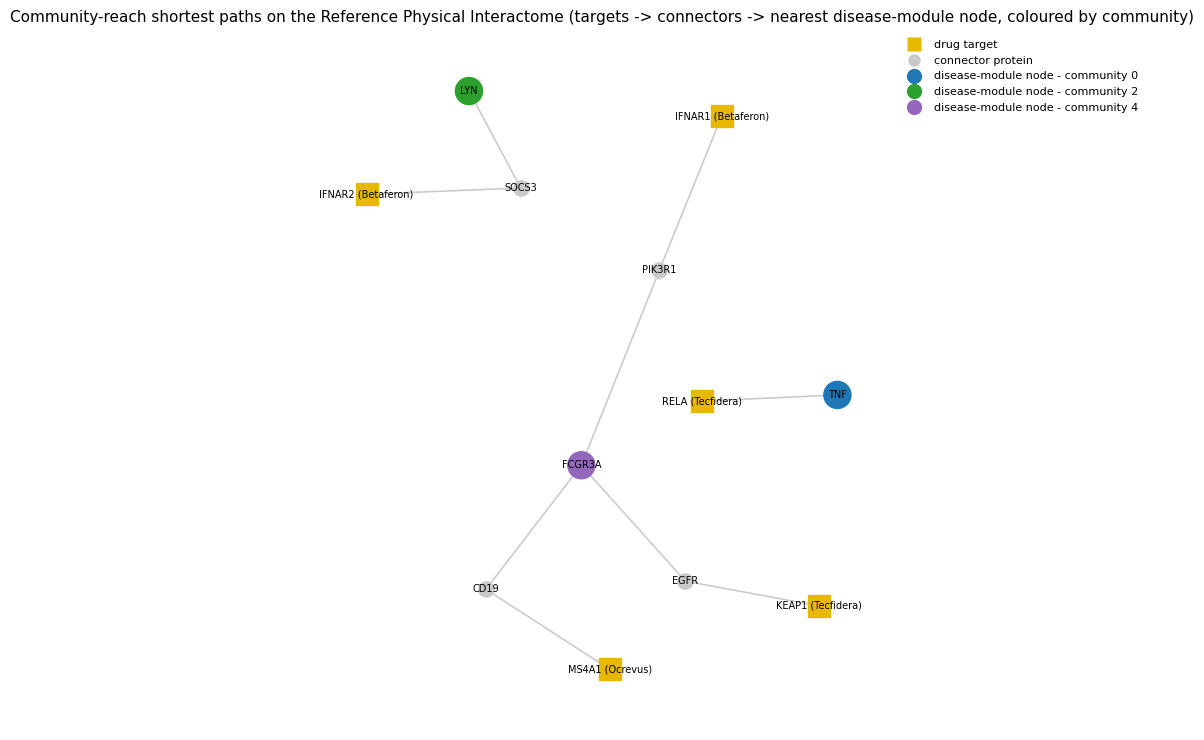

In [125]:
# --- Community-reach network: drug targets -> connectors -> nearest disease-module node (Reference Physical Interactome) ---
# Graphical reading of the community-reach table (Gpaths): each drug target is linked, through any connector
# proteins, to its nearest top-15 disease-module node, which is coloured by its Louvain community.
from matplotlib.lines import Line2D
_role = nx.get_node_attributes(Gpaths, 'role')
_tgt2drug = {t: d for d, T in drug_targets.items() for t in T}
_module  = [n for n in Gpaths if _role.get(n) == 'betweenness_disease_module']
_targets = [n for n in Gpaths if _role.get(n) == 'drug_target']
_conn    = [n for n in Gpaths if _role.get(n) == 'connector']
pos = nx.spring_layout(Gpaths, seed=42, k=0.9)
fig, ax = plt.subplots(figsize=(11, 7.5))
nx.draw_networkx_edges(Gpaths, pos, edge_color='0.8', width=1.2, ax=ax)
nx.draw_networkx_nodes(Gpaths, pos, nodelist=_conn,    node_color='#c9c9c9', node_size=120, ax=ax)
nx.draw_networkx_nodes(Gpaths, pos, nodelist=_targets, node_color='#e6b800', node_shape='s', node_size=260, ax=ax)
nx.draw_networkx_nodes(Gpaths, pos, nodelist=_module,
                       node_color=[COMM_COLORS[partition[n] % len(COMM_COLORS)] for n in _module], node_size=380, ax=ax)
_labels = {n: (f'{n} ({_tgt2drug[n]})' if n in _tgt2drug else n) for n in Gpaths}
nx.draw_networkx_labels(Gpaths, pos, labels=_labels, font_size=7, ax=ax)
ax.set_title('Community-reach shortest paths on the Reference Physical Interactome '
             '(targets -> connectors -> nearest disease-module node, coloured by community)', fontsize=11)
ax.axis('off')
_comms_seen = sorted({partition[n] for n in _module})
_leg = [Line2D([0], [0], marker='s', linestyle='none', markerfacecolor='#e6b800', markeredgecolor='none', markersize=10, label='drug target'),
        Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='#c9c9c9', markeredgecolor='none', markersize=9, label='connector protein')]
_leg += [Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=COMM_COLORS[c % len(COMM_COLORS)], markeredgecolor='none',
                markersize=11, label=f'disease-module node - community {c}') for c in _comms_seen]
ax.legend(handles=_leg, loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False)
plt.tight_layout(rect=[0, 0, 0.78, 1]); plt.savefig(NET/'community_reach_paths.png', dpi=150, bbox_inches='tight'); plt.show()

In [126]:
# --- Guney closest-distance drug-disease proximity + sensitivity, on the Reference Physical Interactome ---
# Closest distance d_c(S,T) = mean over the drug targets t of the shortest-path distance to the nearest
# disease-module gene s in S. Significance: a null of 1000 random (S',T') pairs with the same degree
# sequence as S and T (unique nodes; exact-degree matching); the random S' and T' are drawn disjoint 
# (T' avoids S'), as the observed target and module sets do not overlap. A drug is 'closer than chance' if z < -2.
# The disease module S is the betweenness-derived top-15; module size (top-10 vs top-15) and STRING
# confidence (>=400 vs >=700) are varied as sensitivity checks. The sparse FDR-connected core is included
# only as a diagnostic of FDR-network sparsity, not as a disease module. Distances are hop counts.
import random
from collections import deque, defaultdict
random.seed(SEED); np.random.seed(SEED)
module10 = cent.head(10).index.tolist()

def _msbfs(Gf, seeds):
    dist = {s: 0 for s in seeds if s in Gf}; dq = deque(dist); adj = Gf.adj
    while dq:
        x = dq.popleft(); d = dist[x] + 1
        for y in adj[x]:
            if y not in dist: dist[y] = d; dq.append(y)
    return dist
def _dc(distmap, T):
    v = [distmap[t] for t in T if t in distmap]; return float(np.mean(v)) if v else np.nan
def proximity(Gf, label, targets, S_in, n_rand=1000):
    S = [g for g in S_in if g in Gf]; by_deg = defaultdict(list)
    for n in Gf: by_deg[Gf.degree(n)].append(n)
    def match(nodes, avoid, max_tries=1000):
        # exact degree-matched sampling: each random node has the SAME degree as its target and the set is
        # unique; if a degree class cannot be completed the whole set is redrawn (no nearest-degree
        # fallback), so the null preserves the exact degree sequence of S and T.
        for _try in range(max_tries):
            used = set(avoid); out = []
            for n in nodes:
                pool = [p for p in by_deg[Gf.degree(n)] if p not in used]
                if not pool: break
                pick = random.choice(pool); used.add(pick); out.append(pick)
            if len(out) == len(nodes): return out
        raise RuntimeError('exact degree-matched null could not be completed for this node set')
    # algorithmic invariants: random sets keep their size and contain unique nodes
    _u = set(); _Sr = match(S, _u); assert len(_Sr) == len(S) and len(set(_Sr)) == len(_Sr)
    _Tsets = [[t for t in T if t in Gf] for T in targets.values()]; _T0 = next((t for t in _Tsets if t), [])
    if _T0:
        _Tr = match(_T0, set(_Sr)); assert len(_Tr) == len(_T0) and len(set(_Tr)) == len(_Tr)
    dmap_obs = _msbfs(Gf, S)
    obs = {dr: [t for t in T if t in Gf] for dr, T in targets.items()}
    d_obs = {dr: _dc(dmap_obs, Tm) for dr, Tm in obs.items()}
    NULL = {dr: [] for dr in targets}
    for _ in range(n_rand):
        used = set(); S_rand = match(S, used); dmapS = _msbfs(Gf, set(S_rand))
        for dr, Tm in obs.items():
            if Tm: NULL[dr].append(_dc(dmapS, match(Tm, set(S_rand))))
    Smod = set(S); rows = []
    for dr, T in targets.items():
        Tm = obs[dr]; arr = np.array([x for x in NULL[dr] if np.isfinite(x)]); overlap = sorted(set(Tm) & Smod)
        if len(Tm) == 0 or len(arr) < 50:
            rows.append({'drug': dr, 'targets': len(T), 'mapped': len(Tm), 'in_module': ';'.join(overlap) or '-',
                         'd_closest': None, 'null_mean': None, 'null_sd': None, 'z': None, 'status': 'NA (coverage)'})
            continue
        z = (d_obs[dr] - arr.mean()) / arr.std() if arr.std() > 0 else np.nan
        stt = ('closer than chance (z<-2)' if z < -2 else 'more distant than chance (z>+2)' if z > 2 else 'not significant')
        rows.append({'drug': dr, 'targets': len(T), 'mapped': len(Tm), 'in_module': ';'.join(overlap) or '-',
                     'd_closest': round(d_obs[dr], 3), 'null_mean': round(arr.mean(), 3), 'null_sd': round(arr.std(), 3),
                     'z': round(z, 2), 'status': stt})
    return pd.DataFrame(rows).assign(analysis=label)

# G_reference700 is built in the Reference Physical Interactome cell above (score>=700 sensitivity configuration)
print(f'Reference interactome coverage - disease module (top-15): '
      f'{sum(1 for g in betweenness_disease_module if g in G_reference)}/{len(betweenness_disease_module)} at score>=400.')
prox = pd.concat([
    proximity(G_reference,    'main: betweenness disease module (top-15), reference interactome >=400', drug_targets, betweenness_disease_module),
    proximity(G_reference,    'sensitivity: disease module top-10, >=400', drug_targets, module10),
    proximity(G_reference700, 'sensitivity: disease module top-15, >=700', drug_targets, betweenness_disease_module),
    proximity(G_reference700, 'sensitivity: disease module top-10, >=700', drug_targets, module10),
    proximity(G_reference,    'diagnostic: FDR-connected core (5-node histone clique), >=400', drug_targets, fdr_connected_core),
], ignore_index=True)
prox.to_csv(NET / 'drug_proximity.csv', index=False)
prox

Reference interactome coverage - disease module (top-15): 15/15 at score>=400.


,drug,targets,mapped,in_module,d_closest,null_mean,null_sd,z,status,analysis
0,Betaferon,2,2,-,2.0,2.056,0.331,-0.17,not significant,"main: betweenness disease module (top-15), ref..."
1,Tecfidera,2,2,-,1.5,1.792,0.317,-0.92,not significant,"main: betweenness disease module (top-15), ref..."
2,Ocrevus,1,1,-,2.0,2.527,0.563,-0.94,not significant,"main: betweenness disease module (top-15), ref..."
3,Betaferon,2,2,-,2.0,2.108,0.329,-0.33,not significant,"sensitivity: disease module top-10, >=400"
4,Tecfidera,2,2,-,1.5,1.822,0.326,-0.99,not significant,"sensitivity: disease module top-10, >=400"
5,Ocrevus,1,1,-,2.0,2.522,0.556,-0.94,not significant,"sensitivity: disease module top-10, >=400"
6,Betaferon,2,2,-,2.0,2.498,0.497,-1.00,not significant,"sensitivity: disease module top-15, >=700"
7,Tecfidera,2,2,-,1.5,2.006,0.394,-1.29,not significant,"sensitivity: disease module top-15, >=700"
8,Ocrevus,1,1,-,2.0,3.556,1.069,-1.46,not significant,"sensitivity: disease module top-15, >=700"
9,Betaferon,2,2,-,2.0,2.584,0.511,-1.14,not significant,"sensitivity: disease module top-10, >=700"


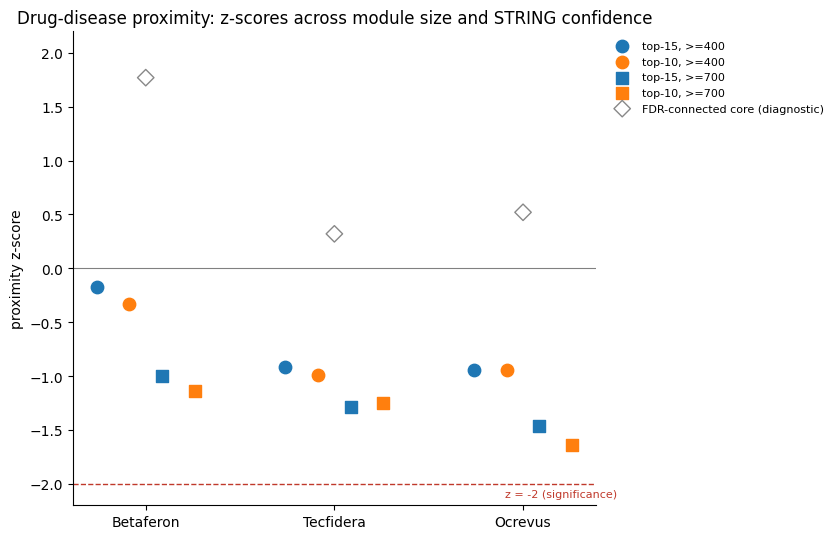

In [127]:
# Proximity z-scores per drug across disease-module size (top-10/15) and STRING confidence (>=400/>=700);
# the FDR-connected core is the diagnostic. The dashed line marks the z = -2 significance threshold.
from matplotlib.lines import Line2D
_cfg = {'main: betweenness disease module (top-15), reference interactome >=400': ('top-15, >=400', plt.cm.tab10(0), 'o'),
        'sensitivity: disease module top-10, >=400': ('top-10, >=400', plt.cm.tab10(1), 'o'),
        'sensitivity: disease module top-15, >=700': ('top-15, >=700', plt.cm.tab10(0), 's'),
        'sensitivity: disease module top-10, >=700': ('top-10, >=700', plt.cm.tab10(1), 's')}
_diag = 'diagnostic: FDR-connected core (5-node histone clique), >=400'
_drugs = list(drug_targets)
_x = np.arange(len(_drugs)); _off = np.linspace(-0.26, 0.26, len(_cfg))
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for _j, (_k, (_lab, _col, _mk)) in enumerate(_cfg.items()):
    _z = [prox[(prox.drug == d) & (prox.analysis == _k)]['z'].iloc[0] for d in _drugs]
    ax.scatter(_x + _off[_j], _z, color=_col, marker=_mk, s=80, zorder=3, label=_lab)
_zd = [prox[(prox.drug == d) & (prox.analysis == _diag)]['z'].iloc[0] for d in _drugs]
ax.scatter(_x, _zd, facecolors='none', edgecolors='#888888', marker='D', s=70, zorder=2, label='FDR-connected core (diagnostic)')
ax.axhline(0, color='grey', lw=0.8); ax.axhline(-2, color='#c0392b', ls='--', lw=1.0)
ax.text(len(_drugs) - 0.5, -2.05, 'z = -2 (significance)', color='#c0392b', fontsize=8, va='top', ha='right')
_lim = max(2.2, np.abs(prox['z']).max() * 1.10); ax.set_ylim(-_lim, _lim)
ax.set_xticks(_x); ax.set_xticklabels(_drugs); ax.set_ylabel('proximity z-score')
ax.set_title('Drug-disease proximity: z-scores across module size and STRING confidence')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig(NET/'drug_proximity_zscores.png', dpi=150, bbox_inches='tight'); plt.show()

In [128]:
# --- Cytoscape node-attribute tables + GraphML with attributes (built after centrality/communities) ---
# DEA attributes are transferred through the STRING queryItem -> preferredName map, so a gene renamed by
# STRING (e.g. CCL3L1) still receives its log2FC/padj.
res_sym = res.dropna(subset=['symbol']).drop_duplicates('symbol').set_index('symbol')
pref2sym = {p: q for q, p in string_ids(ppi_input_genes).items()}
rows = []
for g in G_topology.nodes():
    sym = pref2sym.get(g, g)
    inR = sym in res_sym.index
    rows.append({'gene': g,
        'log2FC': round(float(res_sym.loc[sym, 'log2FoldChange']), 3) if inR else np.nan,
        'padj': (float(res_sym.loc[sym, 'padj']) if inR and pd.notna(res_sym.loc[sym, 'padj']) else np.nan),
        'degree': int(cent.loc[g, 'degree']), 'betweenness': round(float(cent.loc[g, 'betweenness']), 4),
        'closeness': round(float(cent.loc[g, 'closeness']), 4), 'eigenvector': round(float(cent.loc[g, 'eigenvector']), 4),
        'community': int(partition.get(g, -1)), 'is_disease_module': bool(g in betweenness_disease_module)})
node_info = pd.DataFrame(rows)
node_info.to_csv(NET / 'topology_ppi_node_info.tsv', sep='\t', index=False)

attrs = ['log2FC', 'padj', 'degree', 'betweenness', 'closeness', 'eigenvector', 'community', 'is_disease_module']
info_by_gene = node_info.set_index('gene')
for n in G_topology.nodes():
    for a in attrs:
        v = info_by_gene.loc[n, a]
        if pd.isna(v):
            continue
        G_topology.nodes[n][a] = v.item() if hasattr(v, 'item') else v
nx.write_graphml(G_topology, NET / 'topology_ppi.graphml')

# Drug-extended network node table: role, disease-module status and drug per node.
tgt2drug = {}
for _d, _ts in drug_targets.items():
    for _t in _ts: tgt2drug.setdefault(_t, []).append(_d)
ext_rows = [{'gene': n, 'role': G_drug_extended.nodes[n].get('role'),
             'is_disease_module': bool(n in betweenness_disease_module),
             'drug_target_for': ';'.join(tgt2drug.get(n, []))} for n in G_drug_extended.nodes()]
pd.DataFrame(ext_rows).to_csv(NET / 'drug_extended_node_info.tsv', sep='\t', index=False)
print('topology_ppi_node_info.tsv:', node_info.shape, '| drug_extended_node_info.tsv:', len(ext_rows), 'nodes')
node_info.head()

topology_ppi_node_info.tsv: (39, 9) | drug_extended_node_info.tsv: 44 nodes


,gene,log2FC,padj,degree,betweenness,closeness,eigenvector,community,is_disease_module
0,ADRA1A,-0.645,0.717983,1,0.0000,0.2032,0.0885,5,False
1,CADM1,-1.221,0.100755,1,0.0000,0.2209,0.0066,4,False
2,CCL3L1,2.020,0.853289,3,0.0005,0.2452,0.2713,5,False
3,CCL4,-1.475,0.413293,3,0.0005,0.2452,0.2713,5,False
4,CD151,-0.600,0.135502,1,0.0000,0.1818,0.0002,1,False


### Part 2 - discussion

**Network structure.** The FDR-DEG PPI (padj<0.05 protein-coding DEGs mapped to STRING, isolates
retained) is too sparse to rank at 4-vs-4: its only non-trivial component is a five-node histone clique
(H2AC12, H2AC13, H2AC18, H2BC17, H2BC5) with identical degree, betweenness, closeness and eigenvector.
The disease module is therefore taken from the **Topology PPI** as the top 15 nodes by **betweenness** on
the unweighted graph (FCGR3A, LYN, PLCG2, CXCR1, FASLG, TNF, ...), degree as tie-break, with closeness and
eigenvector reported alongside. Interactions are kept at combined score >= 400 (medium confidence) to
preserve connectivity; a score >= 700 reconstruction is reported as a high-confidence Topology PPI construction sensitivity check.

**Communities vs Part-1 enrichment.** Louvain (weighted by score) partitions the Topology PPI largest
component; each community is tested against a **network-conditioned background** (the PPI nodes
themselves), which asks what distinguishes a community from the rest of the network. Two communities reach FDR<0.05: a **chemokine/GPCR** community
(CXCR1/CXCR2/CX3CR1/CCL4; GPCR signalling) and a **TNFR/NF-kB** community (FASLG/TNF/TNFSF9), consistent
with the chemokine/IL-8 and cytokine/NF-kB themes GSEA finds negatively enriched in Part 1. An NK /
C-type-lectin community (KLRK1/PLCG2/LYN) and an adhesion / NCAM-L1CAM community (NCAM1/CADM1/FCGR3A) are
compositionally suggestive but not FDR-significant under this background.

**Drug-extended Topology PPI and local geometry.** Adding the DrugBank targets to the Topology PPI through
their STRING physical interactions makes the drug-disease geometry directly readable. Tecfidera enters the module
most tightly - **RELA lies one interaction from TNF**, a disease-module node belonging to the TNF/NF-kB community, with KEAP1 behind
RELA - and Ocrevus attaches through FCER1A two steps from the module. Betaferon's IFNAR1/IFNAR2 remain a
separate dyad on this expression-derived network; on the Reference Physical Interactome they reach the
module within two steps, so their link runs through intermediate proteins absent from the selected Topology PPI.
This contrast between a study-derived network and a reference interactome is itself informative and
matches the community reach measured on the reference interactome.

**Guney drug-disease proximity.** On the reference STRING v12.0 physical interactome, the closest distance d_c
against a degree-matched null gives no significant proximity: no drug reaches z < -2. The direction of the
effect is nonetheless consistent - every drug shows a negative proximity z-score across both
disease-module sizes (top-10 and top-15) and both STRING confidence thresholds (>=400 and >=700). Because
the target sets are very small and unequal (Ocrevus has a single target), these directional differences
are not read as a ranking of therapeutic efficacy. Used only as a diagnostic, the sparse FDR-connected
core gives positive z-scores (targets further than random from the histone clique), confirming that this
five-node clique is unsuitable as a disease module.

**Overall.** Formal drug-disease proximity did not reach the predefined significance threshold, but the
direction of the effect was consistently toward shorter-than-random distances across disease-module size
and STRING confidence threshold. Local network geometry additionally revealed drug-specific connections to
the betweenness-derived disease module, most notably the RELA-TNF link for Tecfidera.

## Limitations

- The study uses four MS and four HC samples, so statistical power is limited compared with the original
  paper.
- Salmon uses a transcriptome-only index, so the mapping rate is lower than a genome-alignment pipeline
  and mapping statistics are not directly comparable with the paper (STAR followed by RSEM).
- The FDR-DEG PPI’s only non-trivial connected component is a five-node histone clique with tied centralities, too sparse to yield a rankable
  10-15-node module. The Topology PPI largest component is therefore used as the basis for the disease
  module, communities and proximity, while the FDR-connected core and the score>=700 Topology PPI reconstruction are retained
  as a diagnostic and a sensitivity check.
- Formal drug-disease proximity does not reach the z < -2 significance threshold at this sample size; the
  reported signal is the consistent direction of the effect (negative proximity z-scores across
  disease-module size and STRING confidence) together with the drug-specific local geometry, not a
  significant global proximity.